# Bayesian Evidence Synthesis for Comparative Treatment Effectiveness Using Python

## Beta-Blocker Therapy and Mortality After Myocardial Infarction

### Project Overview

This project develops a reproducible Bayesian evidence-synthesis workflow for comparative treatment effectiveness using a publicly available clinical-trial dataset.

The analysis examines mortality outcomes across 22 randomized clinical trials comparing beta-blocker therapy with control after myocardial infarction.

The central question is not simply whether a pooled estimate suggests benefit. The deeper objective is to assess whether the comparative-effect conclusion remains defensible after examining:

* study-level variation;
* between-study heterogeneity;
* fixed-effect and hierarchical random-effects assumptions;
* posterior uncertainty;
* prior specification;
* convergence diagnostics;
* prior-predictive and posterior-predictive checks;
* and sensitivity to reasonable alternative priors.

The workflow combines a conventional frequentist benchmark with Bayesian fixed-effect and hierarchical random-effects models.

### Interpretation Boundary

This is a reproducible evidence-synthesis portfolio analysis using a historical public clinical-trial dataset. It is not a current clinical-practice recommendation.

### Professional Positioning

The notebook is designed as a PhD-level statistical-consulting portfolio project focused on clinical evidence synthesis, biostatistics, comparative treatment effectiveness, uncertainty assessment, and reproducible statistical computing.


## 1. Persistent Google Drive Workspace

A persistent project workspace is created in Google Drive so that figures, tables, documentation, and final repository files remain available after temporary Colab disconnections.


In [ ]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount("/content/drive")

# Create a persistent project workspace
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

folders = [
    PROJECT_ROOT,
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "notebooks",
    PROJECT_ROOT / "scripts",
    PROJECT_ROOT / "outputs",
    PROJECT_ROOT / "outputs" / "figures",
    PROJECT_ROOT / "outputs" / "tables",
    PROJECT_ROOT / "outputs" / "diagnostics",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Persistent Google Drive workspace created successfully.\n")
print("Project root:")
print(PROJECT_ROOT)

print("\nCreated folders:")
for folder in folders:
    print(f"✓ {folder.relative_to(PROJECT_ROOT) if folder != PROJECT_ROOT else '.'}")

Mounted at /content/drive
Persistent Google Drive workspace created successfully.

Project root:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python

Created folders:
✓ .
✓ data
✓ notebooks
✓ scripts
✓ outputs
✓ outputs/figures
✓ outputs/tables
✓ outputs/diagnostics


## 2. Public Dataset Acquisition and Raw Data Inspection

The analysis uses the publicly available `blocker` dataset from the `multinma` package. The dataset contains arm-level mortality outcomes from 22 randomized clinical trials comparing beta-blocker therapy with control after myocardial infarction.

The original public dataset is downloaded into the persistent Google Drive workspace and saved alongside a Python-friendly CSV copy. The raw structure, variable types, treatment labels, and missing-value counts are inspected before any transformation is performed.


In [ ]:
import sys
import subprocess
import urllib.request
from pathlib import Path

import pandas as pd

# Install the reader only if it is not already available
try:
    import pyreadr
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "pyreadr"]
    )
    import pyreadr

# Persistent project workspace
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Official CRAN mirror of the multinma package dataset
source_url = (
    "https://raw.githubusercontent.com/"
    "cran/multinma/master/data/blocker.rda"
)

rda_file = DATA_DIR / "blocker_multinma_original.rda"
csv_file = DATA_DIR / "blocker_raw.csv"

# Download the official R dataset with a browser-style request header
request = urllib.request.Request(
    source_url,
    headers={"User-Agent": "Mozilla/5.0"}
)

with urllib.request.urlopen(request) as response:
    payload = response.read()

rda_file.write_bytes(payload)

print("Official multinma dataset file downloaded successfully.")
print(f"Downloaded file size: {len(payload):,} bytes")
print(f"Saved original file: {rda_file}")

# Read the plain data-frame object
result = pyreadr.read_r(str(rda_file))

print("\nObjects found in the R data file:")
print(list(result.keys()))

blocker_raw = result["blocker"].copy()

# Save a Python-friendly CSV copy
blocker_raw.to_csv(csv_file, index=False)

print("\nRaw beta-blocker dataset acquired successfully.")
print(f"Saved CSV copy: {csv_file}")

print("\nDataset shape:")
print(blocker_raw.shape)

print("\nColumn names:")
print(blocker_raw.columns.tolist())

print("\nFirst 10 rows:")
print(blocker_raw.head(10).to_string(index=False))

print("\nData types:")
print(blocker_raw.dtypes)

print("\nMissing values by column:")
print(blocker_raw.isna().sum())

print("\nUnique treatment labels:")
print(blocker_raw["trtc"].unique())

Official multinma dataset file downloaded successfully.
Downloaded file size: 548 bytes
Saved original file: /content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/data/blocker_multinma_original.rda

Objects found in the R data file:
['blocker']

Raw beta-blocker dataset acquired successfully.
Saved CSV copy: /content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/data/blocker_raw.csv

Dataset shape:
(44, 5)

Column names:
['studyn', 'trtn', 'trtc', 'r', 'n']

First 10 rows:
 studyn  trtn         trtc     r      n
      1   1.0      Control   3.0   39.0
      1   2.0 Beta Blocker   3.0   38.0
      2   1.0      Control  14.0  116.0
      2   2.0 Beta Blocker   7.0  114.0
      3   1.0      Control  11.0   93.0
      3   2.0 Beta Blocker   5.0   69.0
      4   1.0      Control 127.0 1520.0
      4   2.0 Beta Blocker 102.0 1533.0
      5   1.0      Control  27.0  365.0
      5   2.0 Beta Blocker  28.0  355.0

Data types:
studyn      in

## 3. Dataset Integrity Checks and Study-Level Evidence Preparation

Before estimating treatment effects, the raw data are checked for structural and logical validity. Each trial should contain exactly one control arm and one beta-blocker arm, with valid mortality-event counts and positive participant totals.

The verified arm-level data are then transformed into a paired study-level evidence table. Study-specific odds ratios compare beta-blocker therapy with control:

* an odds ratio below 1 indicates lower mortality odds with beta-blocker therapy;
* an odds ratio above 1 indicates higher mortality odds with beta-blocker therapy.

The primary Bayesian models will later use the original arm-level binomial counts directly.


In [ ]:
import pandas as pd
from pathlib import Path

# Persistent workspace
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Reload the saved raw CSV to confirm persistence
blocker_raw = pd.read_csv(DATA_DIR / "blocker_raw.csv")

# Basic quantities
rows_n = len(blocker_raw)
trials_n = blocker_raw["studyn"].nunique()
treatment_labels = sorted(blocker_raw["trtc"].unique().tolist())

# Trial-level structure checks
arms_per_trial = blocker_raw.groupby("studyn").size()
labels_per_trial = (
    blocker_raw.groupby("studyn")["trtc"]
    .apply(lambda x: sorted(x.tolist()))
)

expected_labels = ["Beta Blocker", "Control"]

# Logical checks
checks = [
    {
        "check": "Dataset contains 44 arm-level rows",
        "observed": rows_n,
        "expected": 44,
        "passed": rows_n == 44,
    },
    {
        "check": "Dataset contains 22 unique trials",
        "observed": trials_n,
        "expected": 22,
        "passed": trials_n == 22,
    },
    {
        "check": "Each trial contains exactly 2 arms",
        "observed": bool((arms_per_trial == 2).all()),
        "expected": True,
        "passed": bool((arms_per_trial == 2).all()),
    },
    {
        "check": "Each trial contains one Control and one Beta Blocker arm",
        "observed": bool(labels_per_trial.apply(lambda x: x == expected_labels).all()),
        "expected": True,
        "passed": bool(labels_per_trial.apply(lambda x: x == expected_labels).all()),
    },
    {
        "check": "No missing values are present",
        "observed": int(blocker_raw.isna().sum().sum()),
        "expected": 0,
        "passed": blocker_raw.isna().sum().sum() == 0,
    },
    {
        "check": "All mortality event counts are non-negative",
        "observed": bool((blocker_raw["r"] >= 0).all()),
        "expected": True,
        "passed": bool((blocker_raw["r"] >= 0).all()),
    },
    {
        "check": "Deaths do not exceed participants in any arm",
        "observed": bool((blocker_raw["r"] <= blocker_raw["n"]).all()),
        "expected": True,
        "passed": bool((blocker_raw["r"] <= blocker_raw["n"]).all()),
    },
    {
        "check": "Participant totals are positive",
        "observed": bool((blocker_raw["n"] > 0).all()),
        "expected": True,
        "passed": bool((blocker_raw["n"] > 0).all()),
    },
    {
        "check": "No duplicated trial-treatment rows are present",
        "observed": int(blocker_raw.duplicated(subset=["studyn", "trtc"]).sum()),
        "expected": 0,
        "passed": blocker_raw.duplicated(subset=["studyn", "trtc"]).sum() == 0,
    },
]

integrity_checks = pd.DataFrame(checks)

# Treatment-arm descriptive summary
arm_summary = (
    blocker_raw.groupby("trtc", as_index=False)
    .agg(
        trials_n=("studyn", "nunique"),
        total_participants=("n", "sum"),
        total_deaths=("r", "sum"),
    )
)

arm_summary["overall_mortality_pct"] = (
    100 * arm_summary["total_deaths"] / arm_summary["total_participants"]
).round(2)

# Save transparent audit tables
integrity_checks.to_csv(
    TABLE_DIR / "raw_dataset_integrity_checks.csv",
    index=False
)

arm_summary.to_csv(
    TABLE_DIR / "raw_treatment_arm_summary.csv",
    index=False
)

print("RAW DATASET INTEGRITY CHECKS")
print("=" * 80)
print(integrity_checks.to_string(index=False))

print("\nAll integrity checks passed:")
print(bool(integrity_checks["passed"].all()))

print("\nTREATMENT-ARM DESCRIPTIVE SUMMARY")
print("=" * 80)
print(arm_summary.to_string(index=False))

print("\nArms recorded per trial:")
print(arms_per_trial.value_counts().sort_index().to_string())

print("\nSaved audit tables:")
print(TABLE_DIR / "raw_dataset_integrity_checks.csv")
print(TABLE_DIR / "raw_treatment_arm_summary.csv")

RAW DATASET INTEGRITY CHECKS
                                                   check observed expected  passed
                      Dataset contains 44 arm-level rows       44       44    True
                       Dataset contains 22 unique trials       22       22    True
                      Each trial contains exactly 2 arms     True     True    True
Each trial contains one Control and one Beta Blocker arm     True     True    True
                           No missing values are present        0        0    True
             All mortality event counts are non-negative     True     True    True
            Deaths do not exceed participants in any arm     True     True    True
                         Participant totals are positive     True     True    True
          No duplicated trial-treatment rows are present        0        0    True

All integrity checks passed:
True

TREATMENT-ARM DESCRIPTIVE SUMMARY
        trtc  trials_n  total_participants  total_deaths  overall_morta

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load and clean the verified raw arm-level dataset
# ---------------------------------------------------------
blocker_raw = pd.read_csv(DATA_DIR / "blocker_raw.csv")

arm_level = (
    blocker_raw.rename(
        columns={
            "studyn": "study_id",
            "trtn": "treatment_code",
            "trtc": "treatment_group",
            "r": "deaths",
            "n": "participants",
        }
    )
    .copy()
)

integer_columns = [
    "study_id",
    "treatment_code",
    "deaths",
    "participants",
]

for column in integer_columns:
    arm_level[column] = arm_level[column].astype(int)

arm_level["survivors"] = (
    arm_level["participants"] - arm_level["deaths"]
)

arm_level["mortality_risk"] = (
    arm_level["deaths"] / arm_level["participants"]
)

arm_level["mortality_pct"] = (
    100 * arm_level["mortality_risk"]
).round(2)

arm_level = arm_level.sort_values(
    ["study_id", "treatment_code"]
).reset_index(drop=True)

# ---------------------------------------------------------
# Create paired trial-level evidence table
# ---------------------------------------------------------
control = (
    arm_level.loc[
        arm_level["treatment_group"] == "Control",
        ["study_id", "deaths", "survivors", "participants", "mortality_risk"],
    ]
    .rename(
        columns={
            "deaths": "control_deaths",
            "survivors": "control_survivors",
            "participants": "control_participants",
            "mortality_risk": "control_mortality_risk",
        }
    )
)

beta_blocker = (
    arm_level.loc[
        arm_level["treatment_group"] == "Beta Blocker",
        ["study_id", "deaths", "survivors", "participants", "mortality_risk"],
    ]
    .rename(
        columns={
            "deaths": "beta_blocker_deaths",
            "survivors": "beta_blocker_survivors",
            "participants": "beta_blocker_participants",
            "mortality_risk": "beta_blocker_mortality_risk",
        }
    )
)

study_level = control.merge(
    beta_blocker,
    on="study_id",
    how="inner",
    validate="one_to_one",
)

study_level["total_participants"] = (
    study_level["control_participants"]
    + study_level["beta_blocker_participants"]
)

study_level["risk_difference"] = (
    study_level["beta_blocker_mortality_risk"]
    - study_level["control_mortality_risk"]
)

# ---------------------------------------------------------
# Check for zero cells
# ---------------------------------------------------------
study_level["has_zero_cell"] = (
    (study_level["control_deaths"] == 0)
    | (study_level["control_survivors"] == 0)
    | (study_level["beta_blocker_deaths"] == 0)
    | (study_level["beta_blocker_survivors"] == 0)
)

# Apply 0.5 continuity correction only where required
# This is used only for descriptive odds ratios and the
# conventional benchmark, not for the Bayesian arm-level model.
study_level["continuity_correction"] = np.where(
    study_level["has_zero_cell"],
    0.5,
    0.0,
)

a = (
    study_level["beta_blocker_deaths"]
    + study_level["continuity_correction"]
)

b = (
    study_level["beta_blocker_survivors"]
    + study_level["continuity_correction"]
)

c = (
    study_level["control_deaths"]
    + study_level["continuity_correction"]
)

d = (
    study_level["control_survivors"]
    + study_level["continuity_correction"]
)

# ---------------------------------------------------------
# Calculate study-specific log odds ratios
# OR < 1 indicates lower mortality with beta blockers
# ---------------------------------------------------------
study_level["log_odds_ratio"] = np.log(
    (a / b) / (c / d)
)

study_level["se_log_odds_ratio"] = np.sqrt(
    (1 / a) + (1 / b) + (1 / c) + (1 / d)
)

study_level["odds_ratio"] = np.exp(
    study_level["log_odds_ratio"]
)

study_level["or_ci_lower_95"] = np.exp(
    study_level["log_odds_ratio"]
    - 1.96 * study_level["se_log_odds_ratio"]
)

study_level["or_ci_upper_95"] = np.exp(
    study_level["log_odds_ratio"]
    + 1.96 * study_level["se_log_odds_ratio"]
)

study_level["beta_blocker_mortality_pct"] = (
    100 * study_level["beta_blocker_mortality_risk"]
).round(2)

study_level["control_mortality_pct"] = (
    100 * study_level["control_mortality_risk"]
).round(2)

study_level = study_level.sort_values(
    "study_id"
).reset_index(drop=True)

# ---------------------------------------------------------
# Save processed data files
# ---------------------------------------------------------
arm_level_file = DATA_DIR / "blocker_clean_arm_level.csv"
study_level_file = DATA_DIR / "blocker_study_level_evidence.csv"

arm_level.to_csv(
    arm_level_file,
    index=False,
)

study_level.to_csv(
    study_level_file,
    index=False,
)

# Save a repository-ready copy in outputs/tables
study_level.to_csv(
    TABLE_DIR / "study_level_evidence_table.csv",
    index=False,
)

# ---------------------------------------------------------
# Create data/README.md
# ---------------------------------------------------------
data_readme = """# Data Documentation

## Dataset

This project uses the publicly available `blocker` dataset from the
`multinma` R package.

The dataset contains mortality outcomes from 22 randomized clinical
trials comparing beta-blocker therapy with control after myocardial
infarction.

## Original Public Source

Official CRAN mirror:

`https://raw.githubusercontent.com/cran/multinma/master/data/blocker.rda`

## Raw Data Structure

The original dataset contains 44 arm-level records: two treatment arms
for each of the 22 trials.

| Variable | Meaning |
|---|---|
| `studyn` | Study identifier |
| `trtn` | Numeric treatment code |
| `trtc` | Treatment label |
| `r` | Number of deaths |
| `n` | Total participants in the study arm |

## Processed Files

| File | Purpose |
|---|---|
| `blocker_multinma_original.rda` | Original public R dataset |
| `blocker_raw.csv` | Untouched CSV copy of the original arm-level data |
| `blocker_clean_arm_level.csv` | Clean arm-level data for Bayesian binomial modeling |
| `blocker_study_level_evidence.csv` | Paired study-level table for descriptive analysis and benchmarking |

## Effect-Size Convention

Study-specific odds ratios compare beta-blocker therapy with control.

- Odds ratio below 1: lower mortality odds with beta blockers.
- Odds ratio above 1: higher mortality odds with beta blockers.

A 0.5 continuity correction is applied only to trials containing a
zero cell and only for study-specific descriptive odds-ratio calculations
and the conventional benchmark analysis.

The primary Bayesian models use the original arm-level binomial event
counts directly.

## Interpretation Boundary

This is a reproducible evidence-synthesis portfolio analysis using a
historical public clinical-trial dataset. It is not a current clinical
practice recommendation.
"""

(DATA_DIR / "README.md").write_text(
    data_readme,
    encoding="utf-8",
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("ANALYSIS-READY DATASET CREATED SUCCESSFULLY")
print("=" * 88)

print("\nArm-level clean dataset shape:")
print(arm_level.shape)

print("\nStudy-level paired dataset shape:")
print(study_level.shape)

print("\nTrials containing at least one zero cell:")
print(int(study_level["has_zero_cell"].sum()))

print("\nFirst 10 study-level comparisons:")
display_columns = [
    "study_id",
    "beta_blocker_deaths",
    "beta_blocker_participants",
    "control_deaths",
    "control_participants",
    "beta_blocker_mortality_pct",
    "control_mortality_pct",
    "odds_ratio",
    "or_ci_lower_95",
    "or_ci_upper_95",
    "has_zero_cell",
]

print(
    study_level[display_columns]
    .head(10)
    .round(4)
    .to_string(index=False)
)

print("\nSaved processed data files:")
print(arm_level_file)
print(study_level_file)

print("\nSaved repository table:")
print(TABLE_DIR / "study_level_evidence_table.csv")

print("\nCreated Markdown documentation:")
print(DATA_DIR / "README.md")

ANALYSIS-READY DATASET CREATED SUCCESSFULLY

Arm-level clean dataset shape:
(44, 8)

Study-level paired dataset shape:
(22, 20)

Trials containing at least one zero cell:
0

First 10 study-level comparisons:
 study_id  beta_blocker_deaths  beta_blocker_participants  control_deaths  control_participants  beta_blocker_mortality_pct  control_mortality_pct  odds_ratio  or_ci_lower_95  or_ci_upper_95  has_zero_cell
        1                    3                         38               3                    39                        7.89                   7.69      1.0286          0.1943          5.4454          False
        2                    7                        114              14                   116                        6.14                  12.07      0.4766          0.1849          1.2287          False
        3                    5                         69              11                    93                        7.25                  11.83      0.5824          0.1926

## 4. Study-Level Visualization and Conventional Meta-Analysis Benchmark

A descriptive forest plot is first used to visualize the direction and precision of the 22 study-specific mortality comparisons.

A conventional meta-analysis benchmark is then estimated for context. This includes:

* an inverse-variance fixed-effect model;
* a random-effects model using the Paule–Mandel heterogeneity estimator;
* a modified Hartung–Knapp confidence interval;
* heterogeneity statistics;
* and an approximate prediction interval for a future comparable trial.

The benchmark is not treated as a competitor to Bayesian modeling. It provides a transparent reference point before posterior uncertainty, partial pooling, and prior sensitivity are examined.


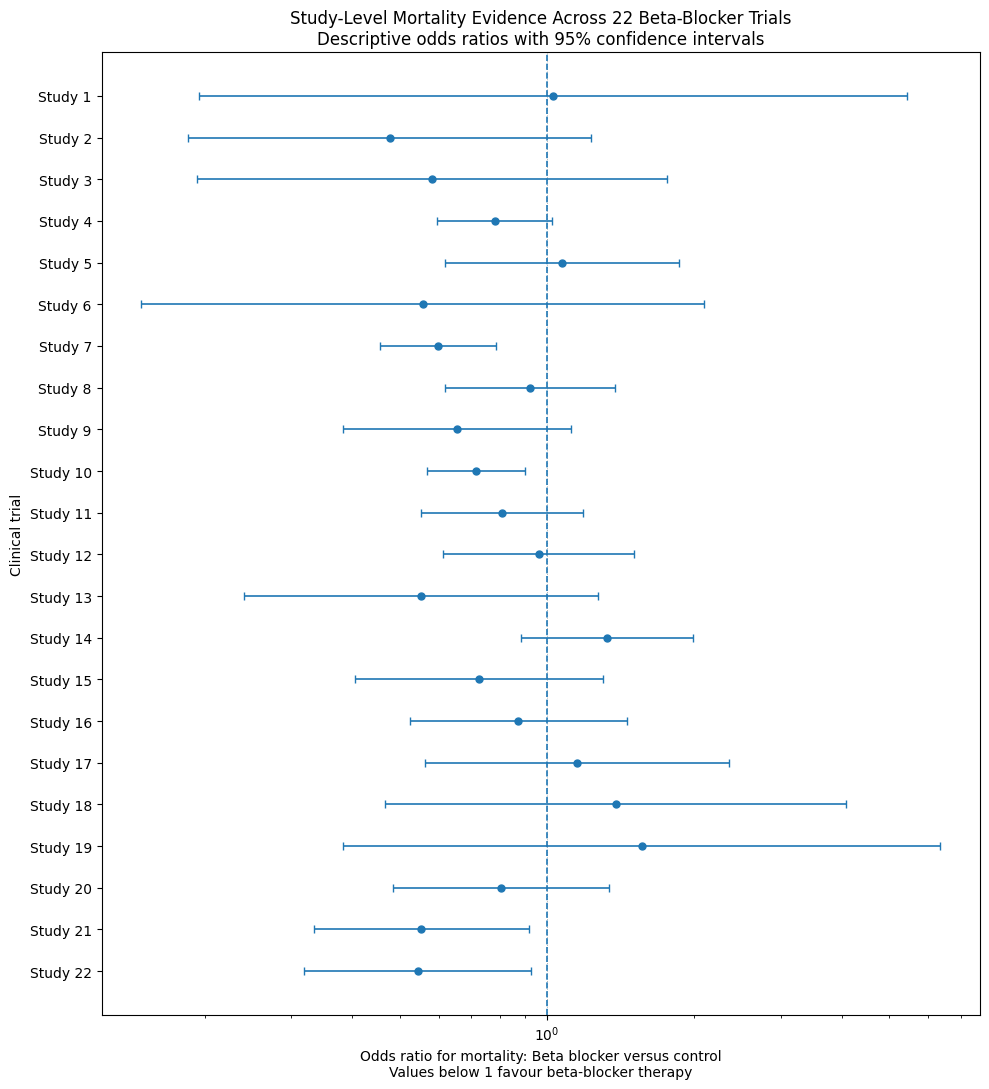

DESCRIPTIVE FOREST PLOT CREATED SUCCESSFULLY

Number of trial comparisons plotted:
22

Trials requiring a continuity correction:
0

Range of observed study-specific odds ratios:
0.4766 to 1.5595

Median observed study-specific odds ratio:
0.7932

Saved figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/01_descriptive_study_level_forest_plot.png

Saved effect-size verification table:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/tables/effect_size_verification_table.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Reload the saved study-level dataset
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
)

# ---------------------------------------------------------
# Create a transparent effect-size verification table
# ---------------------------------------------------------
effect_size_verification = study_level[
    [
        "study_id",
        "beta_blocker_deaths",
        "beta_blocker_survivors",
        "beta_blocker_participants",
        "control_deaths",
        "control_survivors",
        "control_participants",
        "has_zero_cell",
        "continuity_correction",
        "log_odds_ratio",
        "se_log_odds_ratio",
        "odds_ratio",
        "or_ci_lower_95",
        "or_ci_upper_95",
    ]
].copy()

effect_size_verification["interpretation"] = np.where(
    effect_size_verification["odds_ratio"] < 1,
    "Lower mortality odds with beta blocker",
    "Higher mortality odds with beta blocker",
)

verification_file = (
    TABLE_DIR / "effect_size_verification_table.csv"
)

effect_size_verification.to_csv(
    verification_file,
    index=False,
)

# ---------------------------------------------------------
# Create descriptive forest plot
# ---------------------------------------------------------
plot_data = study_level.sort_values(
    "study_id",
    ascending=False,
).copy()

y_positions = np.arange(len(plot_data))

odds_ratios = plot_data["odds_ratio"].to_numpy()
ci_lower = plot_data["or_ci_lower_95"].to_numpy()
ci_upper = plot_data["or_ci_upper_95"].to_numpy()

x_errors = np.vstack(
    [
        odds_ratios - ci_lower,
        ci_upper - odds_ratios,
    ]
)

fig, ax = plt.subplots(
    figsize=(10, 11)
)

ax.errorbar(
    odds_ratios,
    y_positions,
    xerr=x_errors,
    fmt="o",
    capsize=3,
    linewidth=1.2,
    markersize=5,
)

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.2,
)

ax.set_xscale("log")

ax.set_yticks(y_positions)
ax.set_yticklabels(
    [f"Study {study_id}" for study_id in plot_data["study_id"]]
)

ax.set_xlabel(
    "Odds ratio for mortality: Beta blocker versus control\n"
    "Values below 1 favour beta-blocker therapy"
)

ax.set_ylabel("Clinical trial")

ax.set_title(
    "Study-Level Mortality Evidence Across 22 Beta-Blocker Trials\n"
    "Descriptive odds ratios with 95% confidence intervals"
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
)

fig.tight_layout()

forest_plot_file = (
    FIGURE_DIR / "01_descriptive_study_level_forest_plot.png"
)

fig.savefig(
    forest_plot_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("DESCRIPTIVE FOREST PLOT CREATED SUCCESSFULLY")
print("=" * 82)

print("\nNumber of trial comparisons plotted:")
print(len(plot_data))

print("\nTrials requiring a continuity correction:")
print(int(plot_data["has_zero_cell"].sum()))

print("\nRange of observed study-specific odds ratios:")
print(
    f"{plot_data['odds_ratio'].min():.4f} "
    f"to {plot_data['odds_ratio'].max():.4f}"
)

print("\nMedian observed study-specific odds ratio:")
print(f"{plot_data['odds_ratio'].median():.4f}")

print("\nSaved figure:")
print(forest_plot_file)

print("\nSaved effect-size verification table:")
print(verification_file)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import brentq
from scipy.stats import chi2, norm, t

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
)

# Confirm that effect sizes are based on observed counts
assert len(study_level) == 22
assert int(study_level["has_zero_cell"].sum()) == 0
assert float(study_level["continuity_correction"].sum()) == 0.0

y = study_level["log_odds_ratio"].to_numpy(dtype=float)
se = study_level["se_log_odds_ratio"].to_numpy(dtype=float)
v = se**2

k = len(y)
df = k - 1
alpha = 0.05

z_critical = norm.ppf(1 - alpha / 2)
t_critical = t.ppf(1 - alpha / 2, df=df)

# ---------------------------------------------------------
# Fixed-effect inverse-variance benchmark
# ---------------------------------------------------------
weights_fixed = 1 / v

pooled_log_or_fixed = np.sum(
    weights_fixed * y
) / np.sum(weights_fixed)

se_fixed = np.sqrt(
    1 / np.sum(weights_fixed)
)

fixed_ci_lower = (
    pooled_log_or_fixed - z_critical * se_fixed
)

fixed_ci_upper = (
    pooled_log_or_fixed + z_critical * se_fixed
)

# ---------------------------------------------------------
# Cochran's Q and conventional heterogeneity summaries
# ---------------------------------------------------------
q_statistic = np.sum(
    weights_fixed * (y - pooled_log_or_fixed) ** 2
)

q_p_value = chi2.sf(
    q_statistic,
    df=df
)

i_squared = (
    max(0.0, (q_statistic - df) / q_statistic) * 100
    if q_statistic > 0
    else 0.0
)

h_squared = (
    q_statistic / df
    if df > 0
    else np.nan
)

# DerSimonian-Laird tau-squared retained as a reference only
c_value = (
    np.sum(weights_fixed)
    - (
        np.sum(weights_fixed**2)
        / np.sum(weights_fixed)
    )
)

tau_squared_dl = max(
    0.0,
    (q_statistic - df) / c_value,
)

# ---------------------------------------------------------
# Paule-Mandel tau-squared estimator
# ---------------------------------------------------------
def pooled_log_or_for_tau_squared(tau_squared):
    weights = 1 / (v + tau_squared)
    return np.sum(weights * y) / np.sum(weights)


def q_for_tau_squared(tau_squared):
    weights = 1 / (v + tau_squared)
    pooled_effect = pooled_log_or_for_tau_squared(tau_squared)

    return np.sum(
        weights * (y - pooled_effect) ** 2
    )


if q_for_tau_squared(0.0) <= df:
    tau_squared_pm = 0.0
else:
    upper_bound = 1.0

    while q_for_tau_squared(upper_bound) > df:
        upper_bound *= 2

        if upper_bound > 1_000_000:
            raise RuntimeError(
                "Unable to determine a stable Paule-Mandel upper bound."
            )

    tau_squared_pm = brentq(
        lambda tau_squared: (
            q_for_tau_squared(tau_squared) - df
        ),
        0.0,
        upper_bound,
    )

tau_pm = np.sqrt(tau_squared_pm)

# ---------------------------------------------------------
# Random-effects benchmark using Paule-Mandel tau-squared
# ---------------------------------------------------------
weights_random = 1 / (v + tau_squared_pm)

pooled_log_or_random = np.sum(
    weights_random * y
) / np.sum(weights_random)

# Modified Hartung-Knapp adjustment:
# retain at least a scale of 1 for conservative inference
q_random = q_for_tau_squared(tau_squared_pm)

hk_scale_raw = q_random / df
hk_scale_modified = max(1.0, hk_scale_raw)

se_random_mkh = np.sqrt(
    hk_scale_modified / np.sum(weights_random)
)

random_ci_lower = (
    pooled_log_or_random - t_critical * se_random_mkh
)

random_ci_upper = (
    pooled_log_or_random + t_critical * se_random_mkh
)

# Approximate prediction interval for a future comparable trial
prediction_se = np.sqrt(
    tau_squared_pm + se_random_mkh**2
)

prediction_lower = (
    pooled_log_or_random - t_critical * prediction_se
)

prediction_upper = (
    pooled_log_or_random + t_critical * prediction_se
)

# ---------------------------------------------------------
# Save conventional benchmark summary
# ---------------------------------------------------------
benchmark_summary = pd.DataFrame(
    [
        {
            "model": "Fixed-effect inverse-variance benchmark",
            "inference_method": "Normal approximation",
            "pooled_log_odds_ratio": pooled_log_or_fixed,
            "standard_error_log_odds_ratio": se_fixed,
            "ci_lower_log_odds_ratio_95": fixed_ci_lower,
            "ci_upper_log_odds_ratio_95": fixed_ci_upper,
            "pooled_odds_ratio": np.exp(pooled_log_or_fixed),
            "or_ci_lower_95": np.exp(fixed_ci_lower),
            "or_ci_upper_95": np.exp(fixed_ci_upper),
            "tau_squared": 0.0,
        },
        {
            "model": "Random-effects benchmark",
            "inference_method": (
                "Paule-Mandel tau-squared with modified "
                "Hartung-Knapp confidence interval"
            ),
            "pooled_log_odds_ratio": pooled_log_or_random,
            "standard_error_log_odds_ratio": se_random_mkh,
            "ci_lower_log_odds_ratio_95": random_ci_lower,
            "ci_upper_log_odds_ratio_95": random_ci_upper,
            "pooled_odds_ratio": np.exp(pooled_log_or_random),
            "or_ci_lower_95": np.exp(random_ci_lower),
            "or_ci_upper_95": np.exp(random_ci_upper),
            "tau_squared": tau_squared_pm,
        },
    ]
)

heterogeneity_summary = pd.DataFrame(
    [
        {
            "trials_n": k,
            "cochrans_q": q_statistic,
            "q_degrees_of_freedom": df,
            "q_test_p_value": q_p_value,
            "i_squared_pct": i_squared,
            "h_squared": h_squared,
            "tau_squared_paule_mandel": tau_squared_pm,
            "tau_paule_mandel": tau_pm,
            "tau_squared_dersimonian_laird_reference": tau_squared_dl,
            "hartung_knapp_raw_scale": hk_scale_raw,
            "hartung_knapp_modified_scale": hk_scale_modified,
            "prediction_interval_log_or_lower_95": prediction_lower,
            "prediction_interval_log_or_upper_95": prediction_upper,
            "prediction_interval_or_lower_95": np.exp(prediction_lower),
            "prediction_interval_or_upper_95": np.exp(prediction_upper),
        }
    ]
)

study_weights = study_level[
    [
        "study_id",
        "log_odds_ratio",
        "se_log_odds_ratio",
        "odds_ratio",
        "or_ci_lower_95",
        "or_ci_upper_95",
    ]
].copy()

study_weights["fixed_effect_weight_pct"] = (
    100 * weights_fixed / np.sum(weights_fixed)
)

study_weights["random_effect_weight_pct"] = (
    100 * weights_random / np.sum(weights_random)
)

benchmark_file = (
    TABLE_DIR / "conventional_benchmark_summary.csv"
)

heterogeneity_file = (
    TABLE_DIR / "conventional_heterogeneity_summary.csv"
)

weights_file = (
    TABLE_DIR / "conventional_study_weights.csv"
)

benchmark_summary.to_csv(
    benchmark_file,
    index=False,
)

heterogeneity_summary.to_csv(
    heterogeneity_file,
    index=False,
)

study_weights.to_csv(
    weights_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("CONVENTIONAL FREQUENTIST BENCHMARK COMPLETED SUCCESSFULLY")
print("=" * 94)

print("\nPOOLED TREATMENT-EFFECT BENCHMARKS")
print("-" * 94)

display_columns = [
    "model",
    "pooled_odds_ratio",
    "or_ci_lower_95",
    "or_ci_upper_95",
    "tau_squared",
]

print(
    benchmark_summary[display_columns]
    .round(4)
    .to_string(index=False)
)

print("\nHETEROGENEITY SUMMARY")
print("-" * 94)

print(f"Trials included: {k}")
print(f"Cochran's Q: {q_statistic:.4f}")
print(f"Degrees of freedom: {df}")
print(f"Q-test p-value: {q_p_value:.4f}")
print(f"I-squared: {i_squared:.2f}%")
print(f"H-squared: {h_squared:.4f}")
print(f"Paule-Mandel tau-squared: {tau_squared_pm:.6f}")
print(f"Paule-Mandel tau: {tau_pm:.6f}")
print(
    "DerSimonian-Laird tau-squared "
    f"(reference only): {tau_squared_dl:.6f}"
)

print("\nAPPROXIMATE RANDOM-EFFECTS PREDICTION INTERVAL")
print("-" * 94)

print(
    "Odds-ratio scale: "
    f"{np.exp(prediction_lower):.4f} "
    f"to {np.exp(prediction_upper):.4f}"
)

print("\nSAVED REPOSITORY TABLES")
print("-" * 94)

print(benchmark_file)
print(heterogeneity_file)
print(weights_file)

CONVENTIONAL FREQUENTIST BENCHMARK COMPLETED SUCCESSFULLY

POOLED TREATMENT-EFFECT BENCHMARKS
----------------------------------------------------------------------------------------------
                                  model  pooled_odds_ratio  or_ci_lower_95  or_ci_upper_95  tau_squared
Fixed-effect inverse-variance benchmark             0.7711          0.6987          0.8510       0.0000
               Random-effects benchmark             0.7760          0.6927          0.8693       0.0052

HETEROGENEITY SUMMARY
----------------------------------------------------------------------------------------------
Trials included: 22
Cochran's Q: 23.2623
Degrees of freedom: 21
Q-test p-value: 0.3302
I-squared: 9.73%
H-squared: 1.1077
Paule-Mandel tau-squared: 0.005233
Paule-Mandel tau: 0.072340
DerSimonian-Laird tau-squared (reference only): 0.006309

APPROXIMATE RANDOM-EFFECTS PREDICTION INTERVAL
--------------------------------------------------------------------------------------------

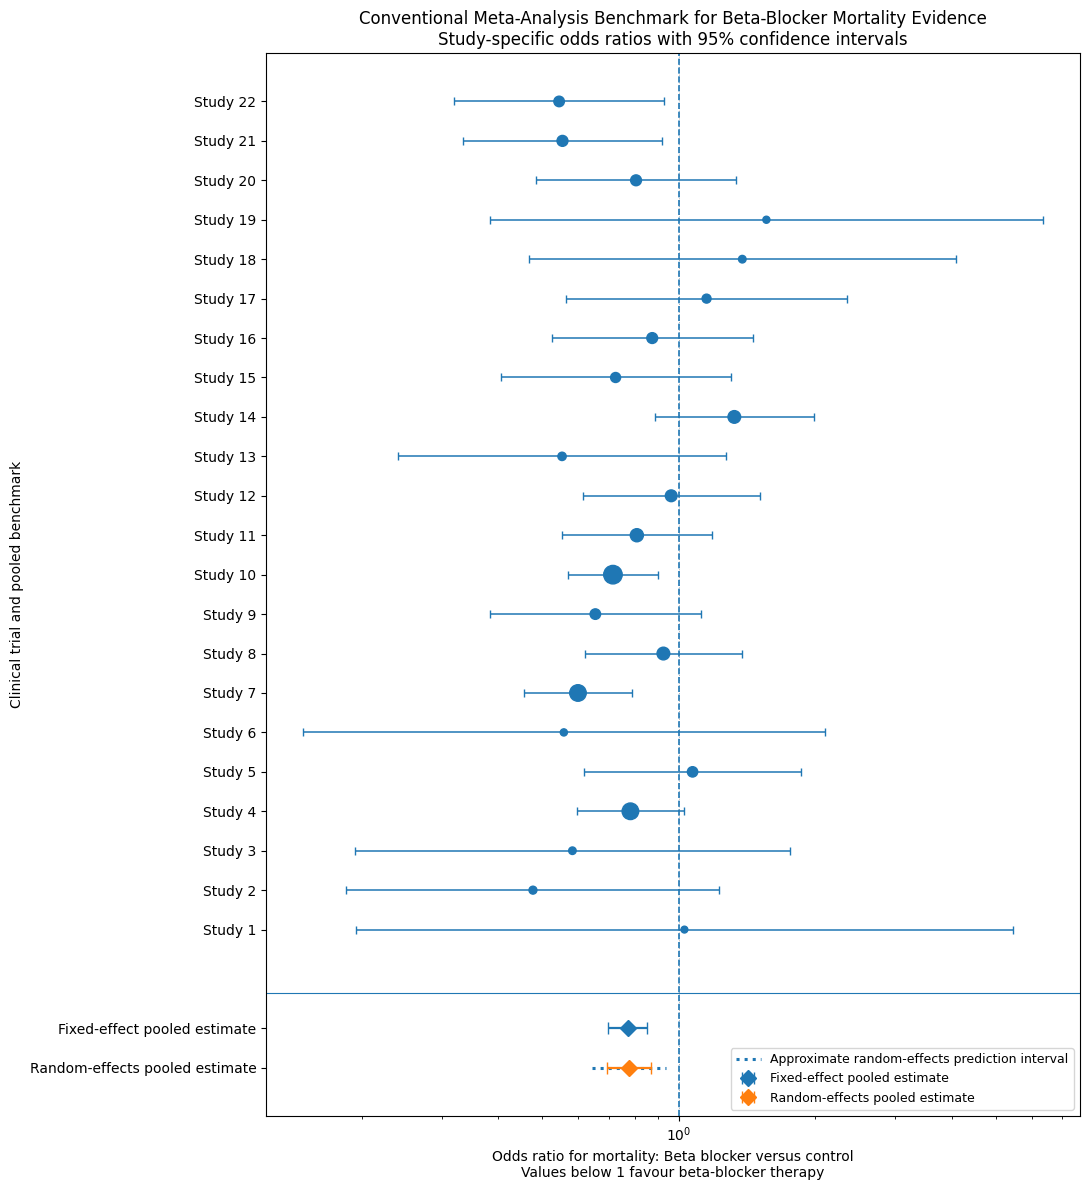

CONVENTIONAL BENCHMARK FOREST PLOT CREATED SUCCESSFULLY

Fixed-effect pooled odds ratio:
0.7711 (0.6987 to 0.8510)

Random-effects pooled odds ratio:
0.7760 (0.6927 to 0.8693)

Approximate random-effects prediction interval:
0.6427 to 0.9369

Saved figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/02_conventional_benchmark_forest_plot.png

Saved plot audit table:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/tables/conventional_benchmark_forest_plot_data.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Reload verified data and conventional benchmark results
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
)

benchmark_summary = pd.read_csv(
    TABLE_DIR / "conventional_benchmark_summary.csv"
)

heterogeneity_summary = pd.read_csv(
    TABLE_DIR / "conventional_heterogeneity_summary.csv"
)

study_weights = pd.read_csv(
    TABLE_DIR / "conventional_study_weights.csv"
)

# Merge random-effects weights into study-level results
plot_data = study_level.merge(
    study_weights[
        [
            "study_id",
            "random_effect_weight_pct",
        ]
    ],
    on="study_id",
    how="left",
    validate="one_to_one",
)

plot_data = plot_data.sort_values(
    "study_id",
    ascending=False,
).reset_index(drop=True)

# ---------------------------------------------------------
# Extract pooled estimates
# ---------------------------------------------------------
fixed_row = benchmark_summary.loc[
    benchmark_summary["model"]
    == "Fixed-effect inverse-variance benchmark"
].iloc[0]

random_row = benchmark_summary.loc[
    benchmark_summary["model"]
    == "Random-effects benchmark"
].iloc[0]

heterogeneity_row = heterogeneity_summary.iloc[0]

prediction_lower = float(
    heterogeneity_row["prediction_interval_or_lower_95"]
)

prediction_upper = float(
    heterogeneity_row["prediction_interval_or_upper_95"]
)

# ---------------------------------------------------------
# Prepare plotting values
# ---------------------------------------------------------
study_y = np.arange(
    len(plot_data) + 3,
    3,
    -1,
)

fixed_y = 1.5
random_y = 0.5

odds_ratios = plot_data["odds_ratio"].to_numpy()
ci_lower = plot_data["or_ci_lower_95"].to_numpy()
ci_upper = plot_data["or_ci_upper_95"].to_numpy()

x_errors = np.vstack(
    [
        odds_ratios - ci_lower,
        ci_upper - odds_ratios,
    ]
)

# Marker sizes reflect random-effects study weights
marker_sizes = (
    20
    + 10 * plot_data["random_effect_weight_pct"].to_numpy()
)

# ---------------------------------------------------------
# Create conventional benchmark forest plot
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(11, 12)
)

# Individual trial estimates
ax.errorbar(
    odds_ratios,
    study_y,
    xerr=x_errors,
    fmt="none",
    capsize=3,
    linewidth=1.1,
)

ax.scatter(
    odds_ratios,
    study_y,
    s=marker_sizes,
    zorder=3,
)

# Random-effects prediction interval
ax.hlines(
    y=random_y,
    xmin=prediction_lower,
    xmax=prediction_upper,
    linewidth=2.2,
    linestyle=":",
    label="Approximate random-effects prediction interval",
)

# Fixed-effect pooled estimate
ax.errorbar(
    float(fixed_row["pooled_odds_ratio"]),
    fixed_y,
    xerr=np.array(
        [
            [
                float(fixed_row["pooled_odds_ratio"])
                - float(fixed_row["or_ci_lower_95"])
            ],
            [
                float(fixed_row["or_ci_upper_95"])
                - float(fixed_row["pooled_odds_ratio"])
            ],
        ]
    ),
    fmt="D",
    markersize=8,
    capsize=4,
    linewidth=1.6,
    label="Fixed-effect pooled estimate",
)

# Random-effects pooled estimate
ax.errorbar(
    float(random_row["pooled_odds_ratio"]),
    random_y,
    xerr=np.array(
        [
            [
                float(random_row["pooled_odds_ratio"])
                - float(random_row["or_ci_lower_95"])
            ],
            [
                float(random_row["or_ci_upper_95"])
                - float(random_row["pooled_odds_ratio"])
            ],
        ]
    ),
    fmt="D",
    markersize=8,
    capsize=4,
    linewidth=1.6,
    label="Random-effects pooled estimate",
)

# Reference line and separator
ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.2,
)

ax.axhline(
    2.4,
    linestyle="-",
    linewidth=0.8,
)

# Axis labels
ax.set_xscale("log")

ax.set_yticks(
    list(study_y) + [fixed_y, random_y]
)

ax.set_yticklabels(
    [f"Study {study_id}" for study_id in plot_data["study_id"]]
    + [
        "Fixed-effect pooled estimate",
        "Random-effects pooled estimate",
    ]
)

ax.set_xlabel(
    "Odds ratio for mortality: Beta blocker versus control\n"
    "Values below 1 favour beta-blocker therapy"
)

ax.set_ylabel(
    "Clinical trial and pooled benchmark"
)

ax.set_title(
    "Conventional Meta-Analysis Benchmark for Beta-Blocker Mortality Evidence\n"
    "Study-specific odds ratios with 95% confidence intervals"
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
)

ax.legend(
    loc="lower right",
    fontsize=9,
)

fig.tight_layout()

# ---------------------------------------------------------
# Save publication-style figure
# ---------------------------------------------------------
benchmark_plot_file = (
    FIGURE_DIR / "02_conventional_benchmark_forest_plot.png"
)

fig.savefig(
    benchmark_plot_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Save figure audit table
# ---------------------------------------------------------
plot_audit_table = plot_data[
    [
        "study_id",
        "odds_ratio",
        "or_ci_lower_95",
        "or_ci_upper_95",
        "random_effect_weight_pct",
    ]
].copy()

plot_audit_file = (
    TABLE_DIR / "conventional_benchmark_forest_plot_data.csv"
)

plot_audit_table.to_csv(
    plot_audit_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("CONVENTIONAL BENCHMARK FOREST PLOT CREATED SUCCESSFULLY")
print("=" * 92)

print("\nFixed-effect pooled odds ratio:")
print(
    f"{float(fixed_row['pooled_odds_ratio']):.4f} "
    f"({float(fixed_row['or_ci_lower_95']):.4f} "
    f"to {float(fixed_row['or_ci_upper_95']):.4f})"
)

print("\nRandom-effects pooled odds ratio:")
print(
    f"{float(random_row['pooled_odds_ratio']):.4f} "
    f"({float(random_row['or_ci_lower_95']):.4f} "
    f"to {float(random_row['or_ci_upper_95']):.4f})"
)

print("\nApproximate random-effects prediction interval:")
print(
    f"{prediction_lower:.4f} "
    f"to {prediction_upper:.4f}"
)

print("\nSaved figure:")
print(benchmark_plot_file)

print("\nSaved plot audit table:")
print(plot_audit_file)

## 5. Bayesian Model Specification and Prior Assumptions

The Bayesian analysis uses the original arm-level mortality counts and a binomial likelihood.

For each trial, the control-arm mortality risk is represented by a study-specific baseline log-odds parameter. The beta-blocker arm is modeled relative to that study-specific baseline.

Two Bayesian models will be estimated:

1. **Bayesian fixed-effect model**
   A single pooled log odds ratio is assumed to apply across all included trials.

2. **Bayesian hierarchical random-effects model**
   Trial-specific treatment effects are modeled as varying around an overall pooled log odds ratio. The heterogeneity parameter represents the remaining between-study variation after partial pooling.

The primary treatment-effect prior is weakly informative and centered on no comparative effect. Alternative skeptical and broader priors will later be used to assess whether the substantive interpretation changes under reasonable assumptions.

The primary Bayesian models use the observed arm-level event counts directly. Continuity corrections are not required.


In [ ]:
import sys
import platform
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Install Bayesian packages only if needed
# ---------------------------------------------------------
required_packages = [
    "pymc",
    "arviz",
]

for package in required_packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package]
        )

import pymc as pm
import arviz as az
import scipy
import matplotlib

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Transparent prior specification table
# ---------------------------------------------------------
prior_specification = pd.DataFrame(
    [
        {
            "scenario": "Primary weakly informative prior",
            "parameter": "Study-specific baseline log odds",
            "symbol": "alpha_study",
            "distribution": "Normal(0, 2.5)",
            "interpretation": (
                "Broad nuisance-parameter prior for each study-specific "
                "control-arm baseline mortality log odds"
            ),
        },
        {
            "scenario": "Primary weakly informative prior",
            "parameter": "Pooled treatment log odds ratio",
            "symbol": "mu",
            "distribution": "Normal(0, 0.5)",
            "interpretation": (
                "Centered on no treatment effect while allowing a clinically "
                "meaningful range of comparative effects"
            ),
        },
        {
            "scenario": "Primary weakly informative prior",
            "parameter": "Between-study heterogeneity",
            "symbol": "tau",
            "distribution": "HalfNormal(0.5)",
            "interpretation": (
                "Allows heterogeneity while placing greater prior density "
                "on smaller values"
            ),
        },
        {
            "scenario": "Skeptical sensitivity prior",
            "parameter": "Pooled treatment log odds ratio",
            "symbol": "mu",
            "distribution": "Normal(0, 0.25)",
            "interpretation": (
                "Places more prior density near no comparative effect"
            ),
        },
        {
            "scenario": "Skeptical sensitivity prior",
            "parameter": "Between-study heterogeneity",
            "symbol": "tau",
            "distribution": "HalfNormal(0.5)",
            "interpretation": (
                "Retains the primary heterogeneity prior so the treatment-effect "
                "prior changes in isolation"
            ),
        },
        {
            "scenario": "Broad sensitivity prior",
            "parameter": "Pooled treatment log odds ratio",
            "symbol": "mu",
            "distribution": "Normal(0, 1.0)",
            "interpretation": (
                "Allows a substantially wider range of comparative effects"
            ),
        },
        {
            "scenario": "Broad sensitivity prior",
            "parameter": "Between-study heterogeneity",
            "symbol": "tau",
            "distribution": "HalfNormal(1.0)",
            "interpretation": (
                "Allows a broader range of between-study heterogeneity values"
            ),
        },
    ]
)

prior_file = (
    TABLE_DIR / "prior_specification_table.csv"
)

prior_specification.to_csv(
    prior_file,
    index=False,
)

# ---------------------------------------------------------
# Save runtime environment information
# ---------------------------------------------------------
runtime_lines = [
    f"Python: {platform.python_version()}",
    f"Operating system: {platform.platform()}",
    f"NumPy: {np.__version__}",
    f"pandas: {pd.__version__}",
    f"SciPy: {scipy.__version__}",
    f"matplotlib: {matplotlib.__version__}",
    f"PyMC: {pm.__version__}",
    f"ArviZ: {az.__version__}",
]

runtime_file = (
    PROJECT_ROOT / "runtime_environment.txt"
)

runtime_file.write_text(
    "\n".join(runtime_lines) + "\n",
    encoding="utf-8",
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("BAYESIAN ENVIRONMENT AND PRIOR STRUCTURE RECORDED SUCCESSFULLY")
print("=" * 92)

print("\nRuntime environment:")
for line in runtime_lines:
    print(line)

print("\nPrior specification table:")
print(
    prior_specification.to_string(
        index=False
    )
)

print("\nSaved prior table:")
print(prior_file)

print("\nSaved runtime environment file:")
print(runtime_file)

BAYESIAN ENVIRONMENT AND PRIOR STRUCTURE RECORDED SUCCESSFULLY

Runtime environment:
Python: 3.12.13
Operating system: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.0.2
pandas: 2.2.2
SciPy: 1.16.3
matplotlib: 3.10.0
PyMC: 5.28.5
ArviZ: 0.22.0

Prior specification table:
                        scenario                        parameter      symbol    distribution                                                                                      interpretation
Primary weakly informative prior Study-specific baseline log odds alpha_study  Normal(0, 2.5)      Broad nuisance-parameter prior for each study-specific control-arm baseline mortality log odds
Primary weakly informative prior  Pooled treatment log odds ratio          mu  Normal(0, 0.5) Centered on no treatment effect while allowing a clinically meaningful range of comparative effects
Primary weakly informative prior      Between-study heterogeneity         tau HalfNormal(0.5)                          Allows heterogeneity while p

### 5.1 Initial Prior-Predictive Check for the Bayesian Fixed-Effect Model

Before fitting the posterior model, the initial prior structure is stress-tested through prior-predictive simulation.

The purpose is to examine whether the priors generate a clinically interpretable range of mortality outcomes before the observed treatment-effect evidence is used for estimation.

This step is especially important for the study-specific baseline-risk parameters. A prior may appear mathematically broad but still generate implausibly extreme clinical outcomes. If the simulated mortality patterns are excessively diffuse, the baseline-risk prior will be refined transparently before posterior sampling.


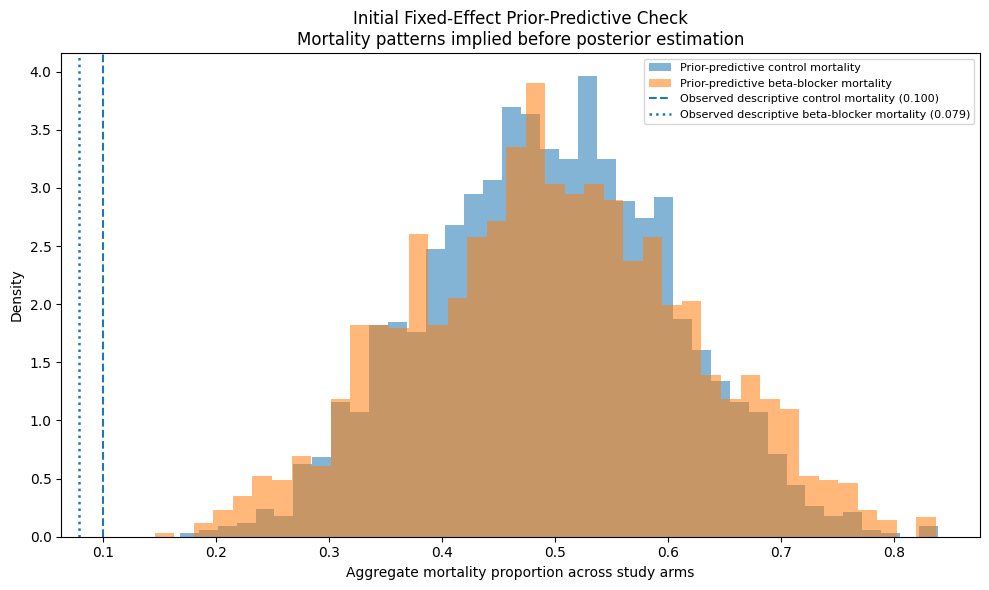

INITIAL FIXED-EFFECT PRIOR-PREDICTIVE CHECK COMPLETED

Observed descriptive aggregate mortality proportions:
Control: 0.1000
Beta blocker: 0.0791

Prior-predictive summary:
                                                    quantity   mean  median  lower_2_5_pct  upper_97_5_pct  minimum  maximum
                Study-specific control mortality probability 0.4964  0.4915         0.0072          0.9926   0.0000   1.0000
           Study-specific beta-blocker mortality probability 0.4970  0.4950         0.0067          0.9931   0.0000   1.0000
               Prior odds ratio: beta blocker versus control 1.1399  1.0009         0.3747          2.6638   0.1514   5.7606
     Prior-predictive aggregate control mortality proportion 0.4947  0.4964         0.2917          0.6999   0.1678   0.8394
Prior-predictive aggregate beta-blocker mortality proportion 0.4956  0.4929         0.2594          0.7362   0.1459   0.8372

Saved figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-e

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level data
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = study_level["study_id"].astype(int).to_numpy()

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

observed_control_mortality = (
    control_deaths.sum() / control_n.sum()
)

observed_beta_mortality = (
    beta_deaths.sum() / beta_n.sum()
)

# ---------------------------------------------------------
# Build the initial Bayesian fixed-effect model
# ---------------------------------------------------------
coords = {
    "study": study_ids,
}

with pm.Model(coords=coords) as initial_fixed_effect_model:

    # Broad initial nuisance prior for study-specific
    # control-arm baseline mortality log odds
    alpha_study = pm.Normal(
        "alpha_study",
        mu=0.0,
        sigma=2.5,
        dims="study",
    )

    # Weakly informative pooled treatment-effect prior
    mu = pm.Normal(
        "mu",
        mu=0.0,
        sigma=0.5,
    )

    # Mortality probabilities
    p_control = pm.Deterministic(
        "p_control",
        pm.math.sigmoid(alpha_study),
        dims="study",
    )

    p_beta_blocker = pm.Deterministic(
        "p_beta_blocker",
        pm.math.sigmoid(alpha_study + mu),
        dims="study",
    )

    # Arm-level binomial likelihoods
    control_deaths_obs = pm.Binomial(
        "control_deaths_obs",
        n=control_n,
        p=p_control,
        observed=control_deaths,
        dims="study",
    )

    beta_deaths_obs = pm.Binomial(
        "beta_deaths_obs",
        n=beta_n,
        p=p_beta_blocker,
        observed=beta_deaths,
        dims="study",
    )

    # Draw outcomes implied by priors only
    initial_fixed_prior_predictive = pm.sample_prior_predictive(
        draws=2000,
        random_seed=20260727,
    )

# ---------------------------------------------------------
# Extract simulated prior probabilities
# ---------------------------------------------------------
prior_group = initial_fixed_prior_predictive.prior
prior_predictive_group = (
    initial_fixed_prior_predictive.prior_predictive
)

p_control_draws = (
    prior_group["p_control"]
    .values
    .reshape(-1)
)

p_beta_draws = (
    prior_group["p_beta_blocker"]
    .values
    .reshape(-1)
)

mu_draws = (
    prior_group["mu"]
    .values
    .reshape(-1)
)

prior_or_draws = np.exp(mu_draws)

# Simulated aggregate mortality proportions across trials
control_deaths_simulated = (
    prior_predictive_group["control_deaths_obs"]
    .values
    .reshape(-1, len(study_ids))
)

beta_deaths_simulated = (
    prior_predictive_group["beta_deaths_obs"]
    .values
    .reshape(-1, len(study_ids))
)

aggregate_control_mortality_simulated = (
    control_deaths_simulated.sum(axis=1)
    / control_n.sum()
)

aggregate_beta_mortality_simulated = (
    beta_deaths_simulated.sum(axis=1)
    / beta_n.sum()
)

# ---------------------------------------------------------
# Create repository-ready summary table
# ---------------------------------------------------------
def summarize_distribution(
    values,
    quantity,
):
    return {
        "quantity": quantity,
        "mean": np.mean(values),
        "median": np.median(values),
        "lower_2_5_pct": np.quantile(values, 0.025),
        "upper_97_5_pct": np.quantile(values, 0.975),
        "minimum": np.min(values),
        "maximum": np.max(values),
    }


prior_predictive_summary = pd.DataFrame(
    [
        summarize_distribution(
            p_control_draws,
            "Study-specific control mortality probability",
        ),
        summarize_distribution(
            p_beta_draws,
            "Study-specific beta-blocker mortality probability",
        ),
        summarize_distribution(
            prior_or_draws,
            "Prior odds ratio: beta blocker versus control",
        ),
        summarize_distribution(
            aggregate_control_mortality_simulated,
            "Prior-predictive aggregate control mortality proportion",
        ),
        summarize_distribution(
            aggregate_beta_mortality_simulated,
            "Prior-predictive aggregate beta-blocker mortality proportion",
        ),
    ]
)

summary_file = (
    TABLE_DIR
    / "initial_fixed_effect_prior_predictive_summary.csv"
)

prior_predictive_summary.to_csv(
    summary_file,
    index=False,
)

# Save full prior-predictive object
prior_predictive_file = (
    DIAGNOSTIC_DIR
    / "initial_fixed_effect_prior_predictive.nc"
)

az.to_netcdf(
    initial_fixed_prior_predictive,
    prior_predictive_file,
)

# ---------------------------------------------------------
# Create prior-predictive visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    aggregate_control_mortality_simulated,
    bins=40,
    alpha=0.55,
    density=True,
    label="Prior-predictive control mortality",
)

ax.hist(
    aggregate_beta_mortality_simulated,
    bins=40,
    alpha=0.55,
    density=True,
    label="Prior-predictive beta-blocker mortality",
)

ax.axvline(
    observed_control_mortality,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Observed descriptive control mortality "
        f"({observed_control_mortality:.3f})"
    ),
)

ax.axvline(
    observed_beta_mortality,
    linestyle=":",
    linewidth=1.8,
    label=(
        "Observed descriptive beta-blocker mortality "
        f"({observed_beta_mortality:.3f})"
    ),
)

ax.set_xlabel(
    "Aggregate mortality proportion across study arms"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Initial Fixed-Effect Prior-Predictive Check\n"
    "Mortality patterns implied before posterior estimation"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

figure_file = (
    FIGURE_DIR
    / "03_initial_fixed_effect_prior_predictive_check.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("INITIAL FIXED-EFFECT PRIOR-PREDICTIVE CHECK COMPLETED")
print("=" * 92)

print("\nObserved descriptive aggregate mortality proportions:")
print(
    f"Control: {observed_control_mortality:.4f}"
)
print(
    f"Beta blocker: {observed_beta_mortality:.4f}"
)

print("\nPrior-predictive summary:")
print(
    prior_predictive_summary
    .round(4)
    .to_string(index=False)
)

print("\nSaved figure:")
print(figure_file)

print("\nSaved summary table:")
print(summary_file)

print("\nSaved prior-predictive diagnostic object:")
print(prior_predictive_file)

### 5.2 Refinement of the Study-Specific Baseline-Risk Prior

The initial baseline-risk prior was intentionally stress-tested before posterior estimation.

The initial specification generated mortality probabilities that were excessively diffuse for this clinical setting, including implausibly high aggregate mortality patterns. The study-specific baseline-risk prior is therefore refined transparently.

The revised prior is:

`alpha_study ~ Normal(logit(0.10), 0.75)`

This is a scale-aware weakly informative prior for the nuisance baseline-risk parameters. It is centered on a clinically interpretable mortality probability of 10% while retaining substantial variation across studies.

The pooled treatment-effect prior remains unchanged:

`mu ~ Normal(0, 0.5)`

This preserves a treatment-effect prior centered on no comparative effect. The refinement is not used to favor beta-blocker therapy; it improves the clinical plausibility of the baseline mortality patterns generated before posterior estimation.


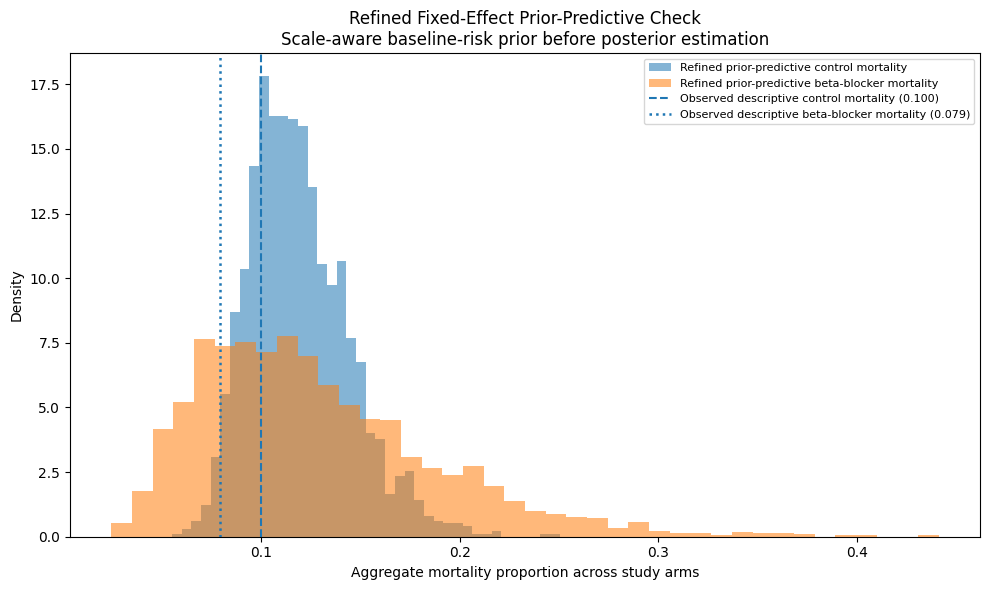

REFINED FIXED-EFFECT PRIOR-PREDICTIVE CHECK COMPLETED

Refined baseline-risk prior:
alpha_study ~ Normal(logit(0.10), 0.75)

Observed descriptive aggregate mortality proportions:
Control: 0.1000
Beta blocker: 0.0791

Refined prior-predictive summary:
                                                    quantity   mean  median  lower_2_5_pct  upper_97_5_pct  minimum  maximum
                Study-specific control mortality probability 0.1191  0.0991         0.0248          0.3258   0.0046   0.6995
           Study-specific beta-blocker mortality probability 0.1279  0.0998         0.0184          0.3978   0.0018   0.8056
               Prior odds ratio: beta blocker versus control 1.1399  1.0009         0.3747          2.6638   0.1514   5.7606
     Prior-predictive aggregate control mortality proportion 0.1191  0.1160         0.0789          0.1766   0.0550   0.2504
Prior-predictive aggregate beta-blocker mortality proportion 0.1279  0.1169         0.0456          0.2701   0.0245   0.4413

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level data
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = study_level["study_id"].astype(int).to_numpy()

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

observed_control_mortality = (
    control_deaths.sum() / control_n.sum()
)

observed_beta_mortality = (
    beta_deaths.sum() / beta_n.sum()
)

# ---------------------------------------------------------
# Define refined scale-aware baseline-risk prior
# ---------------------------------------------------------
baseline_probability_center = 0.10

baseline_logit_mean = np.log(
    baseline_probability_center
    / (1 - baseline_probability_center)
)

baseline_logit_sigma = 0.75

# ---------------------------------------------------------
# Build refined Bayesian fixed-effect model
# ---------------------------------------------------------
coords = {
    "study": study_ids,
}

with pm.Model(coords=coords) as refined_fixed_effect_model:

    # Refined nuisance prior for study-specific
    # control-arm baseline mortality log odds
    alpha_study = pm.Normal(
        "alpha_study",
        mu=baseline_logit_mean,
        sigma=baseline_logit_sigma,
        dims="study",
    )

    # Treatment-effect prior remains centered on no effect
    mu = pm.Normal(
        "mu",
        mu=0.0,
        sigma=0.5,
    )

    # Mortality probabilities
    p_control = pm.Deterministic(
        "p_control",
        pm.math.sigmoid(alpha_study),
        dims="study",
    )

    p_beta_blocker = pm.Deterministic(
        "p_beta_blocker",
        pm.math.sigmoid(alpha_study + mu),
        dims="study",
    )

    # Arm-level binomial likelihoods
    control_deaths_obs = pm.Binomial(
        "control_deaths_obs",
        n=control_n,
        p=p_control,
        observed=control_deaths,
        dims="study",
    )

    beta_deaths_obs = pm.Binomial(
        "beta_deaths_obs",
        n=beta_n,
        p=p_beta_blocker,
        observed=beta_deaths,
        dims="study",
    )

    refined_fixed_prior_predictive = pm.sample_prior_predictive(
        draws=2000,
        random_seed=20260727,
    )

# ---------------------------------------------------------
# Extract refined prior-predictive draws
# ---------------------------------------------------------
prior_group = refined_fixed_prior_predictive.prior

prior_predictive_group = (
    refined_fixed_prior_predictive.prior_predictive
)

p_control_draws = (
    prior_group["p_control"]
    .values
    .reshape(-1)
)

p_beta_draws = (
    prior_group["p_beta_blocker"]
    .values
    .reshape(-1)
)

mu_draws = (
    prior_group["mu"]
    .values
    .reshape(-1)
)

prior_or_draws = np.exp(mu_draws)

control_deaths_simulated = (
    prior_predictive_group["control_deaths_obs"]
    .values
    .reshape(-1, len(study_ids))
)

beta_deaths_simulated = (
    prior_predictive_group["beta_deaths_obs"]
    .values
    .reshape(-1, len(study_ids))
)

aggregate_control_mortality_simulated = (
    control_deaths_simulated.sum(axis=1)
    / control_n.sum()
)

aggregate_beta_mortality_simulated = (
    beta_deaths_simulated.sum(axis=1)
    / beta_n.sum()
)

# ---------------------------------------------------------
# Create summary table
# ---------------------------------------------------------
def summarize_distribution(
    values,
    quantity,
):
    return {
        "quantity": quantity,
        "mean": np.mean(values),
        "median": np.median(values),
        "lower_2_5_pct": np.quantile(values, 0.025),
        "upper_97_5_pct": np.quantile(values, 0.975),
        "minimum": np.min(values),
        "maximum": np.max(values),
    }


refined_prior_predictive_summary = pd.DataFrame(
    [
        summarize_distribution(
            p_control_draws,
            "Study-specific control mortality probability",
        ),
        summarize_distribution(
            p_beta_draws,
            "Study-specific beta-blocker mortality probability",
        ),
        summarize_distribution(
            prior_or_draws,
            "Prior odds ratio: beta blocker versus control",
        ),
        summarize_distribution(
            aggregate_control_mortality_simulated,
            "Prior-predictive aggregate control mortality proportion",
        ),
        summarize_distribution(
            aggregate_beta_mortality_simulated,
            "Prior-predictive aggregate beta-blocker mortality proportion",
        ),
    ]
)

summary_file = (
    TABLE_DIR
    / "refined_fixed_effect_prior_predictive_summary.csv"
)

refined_prior_predictive_summary.to_csv(
    summary_file,
    index=False,
)

# ---------------------------------------------------------
# Save transparent prior-refinement audit table
# ---------------------------------------------------------
prior_refinement_audit = pd.DataFrame(
    [
        {
            "parameter": "Study-specific baseline log odds",
            "symbol": "alpha_study",
            "initial_prior": "Normal(0, 2.5)",
            "refined_prior": "Normal(logit(0.10), 0.75)",
            "reason_for_refinement": (
                "Initial prior-predictive simulation generated "
                "excessively diffuse and clinically implausible "
                "aggregate mortality patterns"
            ),
        },
        {
            "parameter": "Pooled treatment log odds ratio",
            "symbol": "mu",
            "initial_prior": "Normal(0, 0.5)",
            "refined_prior": "Normal(0, 0.5)",
            "reason_for_refinement": (
                "No change: treatment-effect prior remains "
                "centered on no comparative effect"
            ),
        },
    ]
)

audit_file = (
    TABLE_DIR
    / "prior_refinement_audit.csv"
)

prior_refinement_audit.to_csv(
    audit_file,
    index=False,
)

# ---------------------------------------------------------
# Update the primary prior specification table
# ---------------------------------------------------------
prior_file = (
    TABLE_DIR / "prior_specification_table.csv"
)

prior_specification = pd.read_csv(
    prior_file
)

baseline_mask = (
    (
        prior_specification["scenario"]
        == "Primary weakly informative prior"
    )
    & (
        prior_specification["symbol"]
        == "alpha_study"
    )
)

prior_specification.loc[
    baseline_mask,
    "distribution",
] = "Normal(logit(0.10), 0.75)"

prior_specification.loc[
    baseline_mask,
    "interpretation",
] = (
    "Scale-aware weakly informative nuisance prior centered "
    "on a 10% control-arm mortality probability while retaining "
    "substantial study-level variation"
)

prior_specification.to_csv(
    prior_file,
    index=False,
)

# ---------------------------------------------------------
# Save full diagnostic object
# ---------------------------------------------------------
prior_predictive_file = (
    DIAGNOSTIC_DIR
    / "refined_fixed_effect_prior_predictive.nc"
)

az.to_netcdf(
    refined_fixed_prior_predictive,
    prior_predictive_file,
)

# ---------------------------------------------------------
# Create refined prior-predictive visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    aggregate_control_mortality_simulated,
    bins=40,
    alpha=0.55,
    density=True,
    label="Refined prior-predictive control mortality",
)

ax.hist(
    aggregate_beta_mortality_simulated,
    bins=40,
    alpha=0.55,
    density=True,
    label="Refined prior-predictive beta-blocker mortality",
)

ax.axvline(
    observed_control_mortality,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Observed descriptive control mortality "
        f"({observed_control_mortality:.3f})"
    ),
)

ax.axvline(
    observed_beta_mortality,
    linestyle=":",
    linewidth=1.8,
    label=(
        "Observed descriptive beta-blocker mortality "
        f"({observed_beta_mortality:.3f})"
    ),
)

ax.set_xlabel(
    "Aggregate mortality proportion across study arms"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Refined Fixed-Effect Prior-Predictive Check\n"
    "Scale-aware baseline-risk prior before posterior estimation"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

figure_file = (
    FIGURE_DIR
    / "04_refined_fixed_effect_prior_predictive_check.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("REFINED FIXED-EFFECT PRIOR-PREDICTIVE CHECK COMPLETED")
print("=" * 92)

print("\nRefined baseline-risk prior:")
print(
    "alpha_study ~ Normal(logit(0.10), 0.75)"
)

print("\nObserved descriptive aggregate mortality proportions:")
print(
    f"Control: {observed_control_mortality:.4f}"
)
print(
    f"Beta blocker: {observed_beta_mortality:.4f}"
)

print("\nRefined prior-predictive summary:")
print(
    refined_prior_predictive_summary
    .round(4)
    .to_string(index=False)
)

print("\nSaved figure:")
print(figure_file)

print("\nSaved summary table:")
print(summary_file)

print("\nSaved prior-refinement audit table:")
print(audit_file)

print("\nUpdated prior specification table:")
print(prior_file)

print("\nSaved diagnostic object:")
print(prior_predictive_file)

### 5.3 Bayesian Fixed-Effect Posterior Estimation

The Bayesian fixed-effect model assumes that one common underlying treatment effect applies across all included trials.

The model uses:

* the original arm-level mortality counts;
* a study-specific baseline mortality log-odds parameter for each trial;
* the refined scale-aware baseline-risk prior;
* and a pooled treatment log odds ratio shared across studies.

The posterior distribution will be examined using convergence diagnostics rather than interpreted solely from the pooled estimate. This model provides a transparent Bayesian reference point before between-study heterogeneity is introduced through the hierarchical random-effects model.


In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = study_level["study_id"].astype(int).to_numpy()

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

# ---------------------------------------------------------
# Refined baseline-risk prior
# ---------------------------------------------------------
baseline_probability_center = 0.10

baseline_logit_mean = np.log(
    baseline_probability_center
    / (1 - baseline_probability_center)
)

baseline_logit_sigma = 0.75

coords = {
    "study": study_ids,
}

# ---------------------------------------------------------
# Fit Bayesian fixed-effect posterior model
# ---------------------------------------------------------
with pm.Model(coords=coords) as fixed_effect_model:

    alpha_study = pm.Normal(
        "alpha_study",
        mu=baseline_logit_mean,
        sigma=baseline_logit_sigma,
        dims="study",
    )

    mu = pm.Normal(
        "mu",
        mu=0.0,
        sigma=0.5,
    )

    pooled_odds_ratio = pm.Deterministic(
        "pooled_odds_ratio",
        pm.math.exp(mu),
    )

    p_control = pm.Deterministic(
        "p_control",
        pm.math.sigmoid(alpha_study),
        dims="study",
    )

    p_beta_blocker = pm.Deterministic(
        "p_beta_blocker",
        pm.math.sigmoid(alpha_study + mu),
        dims="study",
    )

    control_deaths_obs = pm.Binomial(
        "control_deaths_obs",
        n=control_n,
        p=p_control,
        observed=control_deaths,
        dims="study",
    )

    beta_deaths_obs = pm.Binomial(
        "beta_deaths_obs",
        n=beta_n,
        p=p_beta_blocker,
        observed=beta_deaths,
        dims="study",
    )

    fixed_effect_idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=2,
        target_accept=0.95,
        random_seed=[
            20260727,
            20260728,
            20260729,
            20260730,
        ],
        return_inferencedata=True,
    )

# ---------------------------------------------------------
# Save full posterior object
# ---------------------------------------------------------
posterior_file = (
    DIAGNOSTIC_DIR
    / "bayesian_fixed_effect_posterior.nc"
)

az.to_netcdf(
    fixed_effect_idata,
    posterior_file,
)

# ---------------------------------------------------------
# Create posterior summaries
# ---------------------------------------------------------
fixed_effect_core_summary = az.summary(
    fixed_effect_idata,
    var_names=[
        "mu",
        "pooled_odds_ratio",
    ],
    hdi_prob=0.95,
    round_to=6,
).reset_index().rename(
    columns={
        "index": "parameter",
    }
)

all_parameter_diagnostics = az.summary(
    fixed_effect_idata,
    var_names=[
        "alpha_study",
        "mu",
    ],
    hdi_prob=0.95,
    round_to=6,
).reset_index().rename(
    columns={
        "index": "parameter",
    }
)

# ---------------------------------------------------------
# Calculate clinically readable posterior probabilities
# ---------------------------------------------------------
mu_draws = (
    fixed_effect_idata.posterior["mu"]
    .values
    .reshape(-1)
)

or_draws = np.exp(mu_draws)

posterior_probability_summary = pd.DataFrame(
    [
        {
            "probability_statement": (
                "Probability that beta blockers reduce mortality odds "
                "(OR < 1)"
            ),
            "posterior_probability": np.mean(or_draws < 1.0),
        },
        {
            "probability_statement": (
                "Probability of at least 10% lower mortality odds "
                "(OR < 0.90)"
            ),
            "posterior_probability": np.mean(or_draws < 0.90),
        },
        {
            "probability_statement": (
                "Probability of at least 20% lower mortality odds "
                "(OR < 0.80)"
            ),
            "posterior_probability": np.mean(or_draws < 0.80),
        },
        {
            "probability_statement": (
                "Probability of higher mortality odds "
                "(OR > 1)"
            ),
            "posterior_probability": np.mean(or_draws > 1.0),
        },
    ]
)

# ---------------------------------------------------------
# Extract convergence checks
# ---------------------------------------------------------
sample_stats = fixed_effect_idata.sample_stats

divergences = int(
    sample_stats["diverging"]
    .values
    .sum()
)

max_rhat = float(
    all_parameter_diagnostics["r_hat"]
    .max()
)

min_ess_bulk = float(
    all_parameter_diagnostics["ess_bulk"]
    .min()
)

min_ess_tail = float(
    all_parameter_diagnostics["ess_tail"]
    .min()
)

convergence_summary = pd.DataFrame(
    [
        {
            "model": "Bayesian fixed-effect model",
            "chains": 4,
            "posterior_draws_per_chain": 2000,
            "tuning_draws_per_chain": 2000,
            "total_posterior_draws": 8000,
            "divergences": divergences,
            "maximum_r_hat": max_rhat,
            "minimum_ess_bulk": min_ess_bulk,
            "minimum_ess_tail": min_ess_tail,
        }
    ]
)

# ---------------------------------------------------------
# Save repository-ready tables
# ---------------------------------------------------------
core_summary_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_summary.csv"
)

probability_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_posterior_probability_summary.csv"
)

diagnostics_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_convergence_summary.csv"
)

all_parameter_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_all_parameter_diagnostics.csv"
)

fixed_effect_core_summary.to_csv(
    core_summary_file,
    index=False,
)

posterior_probability_summary.to_csv(
    probability_file,
    index=False,
)

convergence_summary.to_csv(
    diagnostics_file,
    index=False,
)

all_parameter_diagnostics.to_csv(
    all_parameter_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("BAYESIAN FIXED-EFFECT POSTERIOR MODEL COMPLETED")
print("=" * 92)

print("\nCore posterior summary:")
print(
    fixed_effect_core_summary
    .to_string(index=False)
)

print("\nClinically readable posterior probabilities:")
print(
    posterior_probability_summary
    .round(6)
    .to_string(index=False)
)

print("\nConvergence summary:")
print(
    convergence_summary
    .round(6)
    .to_string(index=False)
)

print("\nSaved posterior object:")
print(posterior_file)

print("\nSaved repository tables:")
print(core_summary_file)
print(probability_file)
print(diagnostics_file)
print(all_parameter_file)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(


Output()

BAYESIAN FIXED-EFFECT POSTERIOR MODEL COMPLETED

Core posterior summary:
        parameter      mean       sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd    ess_bulk    ess_tail    r_hat
               mu -0.259306 0.048585 -0.354236  -0.162960   0.000519 0.000505 8772.486859 6874.652408 1.000705
pooled_odds_ratio  0.772498 0.037548  0.699814   0.847703   0.000401 0.000393 8772.486859 6874.652408 1.000650

Clinically readable posterior probabilities:
                                        probability_statement  posterior_probability
Probability that beta blockers reduce mortality odds (OR < 1)               1.000000
 Probability of at least 10% lower mortality odds (OR < 0.90)               0.998875
 Probability of at least 20% lower mortality odds (OR < 0.80)               0.770625
                Probability of higher mortality odds (OR > 1)               0.000000

Convergence summary:
                      model  chains  posterior_draws_per_chain  tuning_draws_per_chain  total_posteri

### 5.4 Fixed-Effect Posterior Visualization and Trace Diagnostics

The pooled treatment-effect posterior is visualized on the odds-ratio scale.

The posterior distribution is compared with:

* the null value of 1.00;
* a threshold representing at least 10% lower mortality odds (`OR = 0.90`);
* and a threshold representing at least 20% lower mortality odds (`OR = 0.80`).

Trace plots are also inspected to assess chain mixing and sampling stability. These visual diagnostics complement the numerical convergence checks.


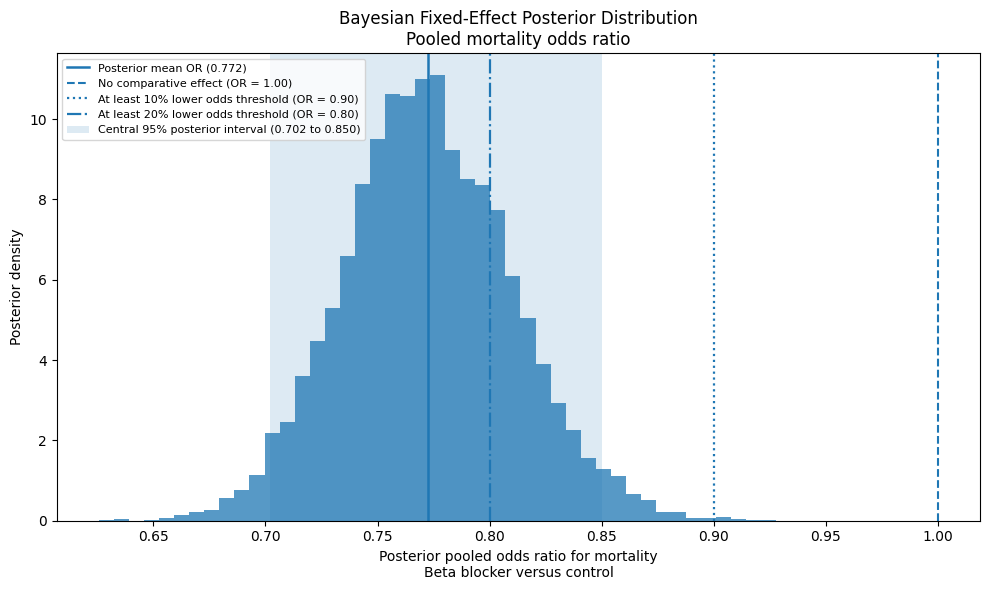

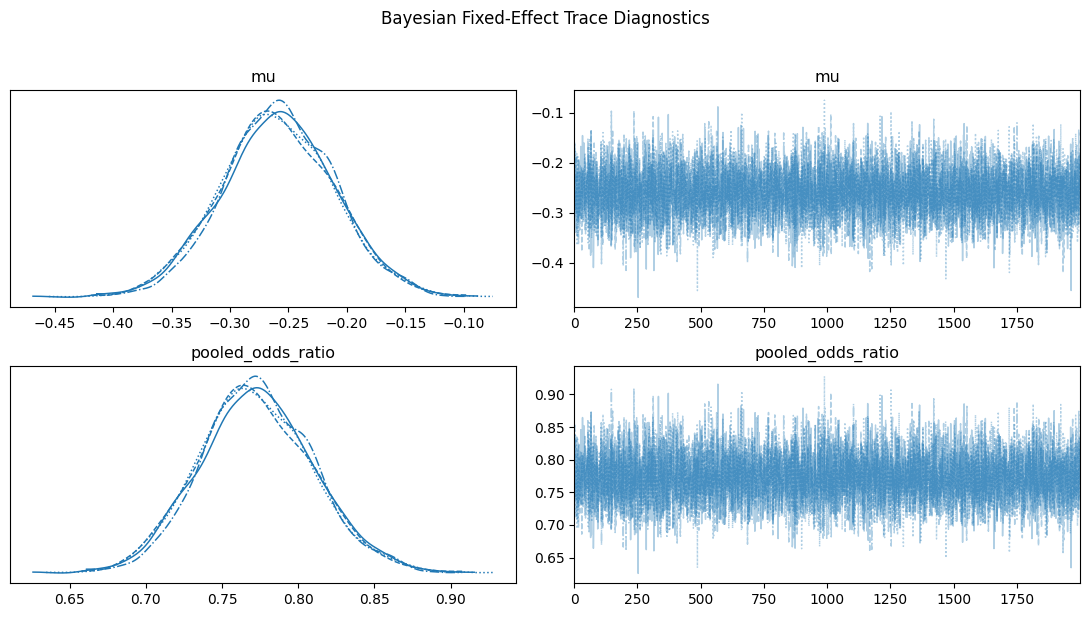

FIXED-EFFECT POSTERIOR AND TRACE FIGURES CREATED SUCCESSFULLY

Posterior odds-ratio summary:
                      model  posterior_mean_odds_ratio  posterior_median_odds_ratio  posterior_interval_lower_95  posterior_interval_upper_95  probability_or_below_1_00  probability_or_below_0_90  probability_or_below_0_80
Bayesian fixed-effect model                   0.772498                      0.77134                     0.701943                      0.85012                        1.0                   0.998875                   0.770625

Saved posterior-distribution figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/05_bayesian_fixed_effect_posterior_distribution.png

Saved trace-plot figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/06_bayesian_fixed_effect_trace_plot.png

Saved plot audit table:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/ou

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Extract posterior treatment-effect draws
# ---------------------------------------------------------
mu_draws = (
    fixed_effect_idata.posterior["mu"]
    .values
    .reshape(-1)
)

or_draws = np.exp(mu_draws)

posterior_or_mean = np.mean(or_draws)

posterior_or_lower = np.quantile(
    or_draws,
    0.025,
)

posterior_or_upper = np.quantile(
    or_draws,
    0.975,
)

# ---------------------------------------------------------
# Create posterior distribution plot
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    or_draws,
    bins=45,
    density=True,
    alpha=0.75,
)

ax.axvline(
    posterior_or_mean,
    linestyle="-",
    linewidth=1.8,
    label=(
        "Posterior mean OR "
        f"({posterior_or_mean:.3f})"
    ),
)

ax.axvline(
    1.00,
    linestyle="--",
    linewidth=1.5,
    label="No comparative effect (OR = 1.00)",
)

ax.axvline(
    0.90,
    linestyle=":",
    linewidth=1.6,
    label="At least 10% lower odds threshold (OR = 0.90)",
)

ax.axvline(
    0.80,
    linestyle="-.",
    linewidth=1.6,
    label="At least 20% lower odds threshold (OR = 0.80)",
)

ax.axvspan(
    posterior_or_lower,
    posterior_or_upper,
    alpha=0.15,
    label=(
        "Central 95% posterior interval "
        f"({posterior_or_lower:.3f} to {posterior_or_upper:.3f})"
    ),
)

ax.set_xlabel(
    "Posterior pooled odds ratio for mortality\n"
    "Beta blocker versus control"
)

ax.set_ylabel(
    "Posterior density"
)

ax.set_title(
    "Bayesian Fixed-Effect Posterior Distribution\n"
    "Pooled mortality odds ratio"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

posterior_figure_file = (
    FIGURE_DIR
    / "05_bayesian_fixed_effect_posterior_distribution.png"
)

fig.savefig(
    posterior_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Create trace plot
# ---------------------------------------------------------
trace_axes = az.plot_trace(
    fixed_effect_idata,
    var_names=[
        "mu",
        "pooled_odds_ratio",
    ],
    compact=True,
    figsize=(11, 6),
)

trace_figure = np.asarray(
    trace_axes
).reshape(-1)[0].figure

trace_figure.suptitle(
    "Bayesian Fixed-Effect Trace Diagnostics",
    y=1.02,
)

trace_figure.tight_layout()

trace_figure_file = (
    FIGURE_DIR
    / "06_bayesian_fixed_effect_trace_plot.png"
)

trace_figure.savefig(
    trace_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Save plot-ready posterior audit table
# ---------------------------------------------------------
posterior_plot_summary = pd.DataFrame(
    [
        {
            "model": "Bayesian fixed-effect model",
            "posterior_mean_odds_ratio": posterior_or_mean,
            "posterior_median_odds_ratio": np.median(or_draws),
            "posterior_interval_lower_95": posterior_or_lower,
            "posterior_interval_upper_95": posterior_or_upper,
            "probability_or_below_1_00": np.mean(or_draws < 1.00),
            "probability_or_below_0_90": np.mean(or_draws < 0.90),
            "probability_or_below_0_80": np.mean(or_draws < 0.80),
        }
    ]
)

posterior_plot_summary_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_posterior_plot_summary.csv"
)

posterior_plot_summary.to_csv(
    posterior_plot_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("FIXED-EFFECT POSTERIOR AND TRACE FIGURES CREATED SUCCESSFULLY")
print("=" * 92)

print("\nPosterior odds-ratio summary:")
print(
    posterior_plot_summary
    .round(6)
    .to_string(index=False)
)

print("\nSaved posterior-distribution figure:")
print(posterior_figure_file)

print("\nSaved trace-plot figure:")
print(trace_figure_file)

print("\nSaved plot audit table:")
print(posterior_plot_summary_file)

### 5.5 Fixed-Effect Posterior-Predictive Check

Posterior-predictive simulation is used to assess whether the fitted Bayesian fixed-effect model can reproduce mortality patterns similar to those observed in the included trials.

The check compares:

* observed aggregate mortality in the control arms;
* observed aggregate mortality in the beta-blocker arms;
* posterior-predictive aggregate mortality distributions;
* and observed versus posterior-predictive study-level death counts.

A model should not be considered adequate merely because sampling completed successfully. Posterior-predictive checks provide an additional assessment of whether the fitted model generates clinically recognizable outcomes.


Output()

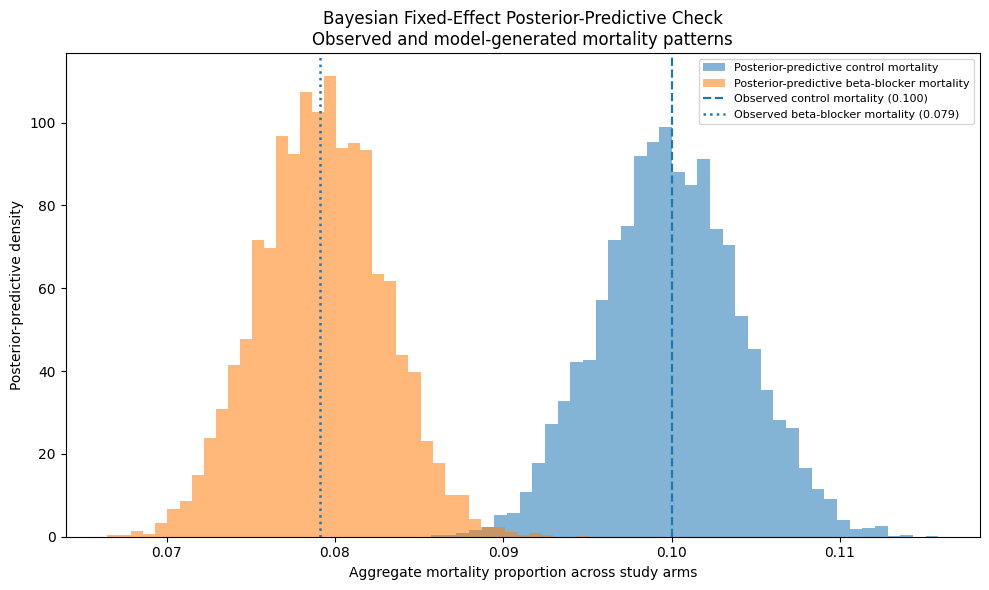

FIXED-EFFECT POSTERIOR-PREDICTIVE CHECK COMPLETED

Aggregate posterior-predictive summary:
         arm  observed_mortality_proportion  posterior_predictive_mean  posterior_predictive_median  posterior_predictive_lower_95  posterior_predictive_upper_95  observed_within_predictive_interval
     Control                       0.100010                   0.099963                     0.099909                       0.091989                       0.108133                                 True
Beta blocker                       0.079111                   0.079199                     0.079207                       0.072120                       0.086390                                 True

Study-level predictive interval coverage:
Control arms: 22 of 22 studies
Beta-blocker arms: 22 of 22 studies

Saved figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/07_bayesian_fixed_effect_posterior_predictive_check.png

Saved repository tables:
/conten

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Reload verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = (
    study_level["study_id"]
    .astype(int)
    .to_numpy()
)

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

observed_control_mortality = (
    control_deaths.sum() / control_n.sum()
)

observed_beta_mortality = (
    beta_deaths.sum() / beta_n.sum()
)

# ---------------------------------------------------------
# Draw posterior-predictive outcomes
# ---------------------------------------------------------
with fixed_effect_model:
    fixed_effect_ppc = pm.sample_posterior_predictive(
        fixed_effect_idata,
        var_names=[
            "control_deaths_obs",
            "beta_deaths_obs",
        ],
        random_seed=20260727,
        return_inferencedata=True,
    )

# ---------------------------------------------------------
# Extract simulated arm-level death counts
# ---------------------------------------------------------
control_deaths_simulated = (
    fixed_effect_ppc.posterior_predictive[
        "control_deaths_obs"
    ]
    .values
    .reshape(-1, len(study_ids))
)

beta_deaths_simulated = (
    fixed_effect_ppc.posterior_predictive[
        "beta_deaths_obs"
    ]
    .values
    .reshape(-1, len(study_ids))
)

aggregate_control_mortality_simulated = (
    control_deaths_simulated.sum(axis=1)
    / control_n.sum()
)

aggregate_beta_mortality_simulated = (
    beta_deaths_simulated.sum(axis=1)
    / beta_n.sum()
)

# ---------------------------------------------------------
# Create aggregate posterior-predictive summary
# ---------------------------------------------------------
aggregate_ppc_summary = pd.DataFrame(
    [
        {
            "arm": "Control",
            "observed_mortality_proportion": observed_control_mortality,
            "posterior_predictive_mean": (
                np.mean(
                    aggregate_control_mortality_simulated
                )
            ),
            "posterior_predictive_median": (
                np.median(
                    aggregate_control_mortality_simulated
                )
            ),
            "posterior_predictive_lower_95": (
                np.quantile(
                    aggregate_control_mortality_simulated,
                    0.025,
                )
            ),
            "posterior_predictive_upper_95": (
                np.quantile(
                    aggregate_control_mortality_simulated,
                    0.975,
                )
            ),
            "observed_within_predictive_interval": (
                np.quantile(
                    aggregate_control_mortality_simulated,
                    0.025,
                )
                <= observed_control_mortality
                <= np.quantile(
                    aggregate_control_mortality_simulated,
                    0.975,
                )
            ),
        },
        {
            "arm": "Beta blocker",
            "observed_mortality_proportion": observed_beta_mortality,
            "posterior_predictive_mean": (
                np.mean(
                    aggregate_beta_mortality_simulated
                )
            ),
            "posterior_predictive_median": (
                np.median(
                    aggregate_beta_mortality_simulated
                )
            ),
            "posterior_predictive_lower_95": (
                np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.025,
                )
            ),
            "posterior_predictive_upper_95": (
                np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.975,
                )
            ),
            "observed_within_predictive_interval": (
                np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.025,
                )
                <= observed_beta_mortality
                <= np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.975,
                )
            ),
        },
    ]
)

# ---------------------------------------------------------
# Create study-level posterior-predictive audit table
# ---------------------------------------------------------
study_level_ppc = pd.DataFrame(
    {
        "study_id": study_ids,
        "observed_control_deaths": control_deaths,
        "predicted_control_deaths_mean": (
            control_deaths_simulated.mean(axis=0)
        ),
        "predicted_control_deaths_lower_95": (
            np.quantile(
                control_deaths_simulated,
                0.025,
                axis=0,
            )
        ),
        "predicted_control_deaths_upper_95": (
            np.quantile(
                control_deaths_simulated,
                0.975,
                axis=0,
            )
        ),
        "observed_beta_blocker_deaths": beta_deaths,
        "predicted_beta_blocker_deaths_mean": (
            beta_deaths_simulated.mean(axis=0)
        ),
        "predicted_beta_blocker_deaths_lower_95": (
            np.quantile(
                beta_deaths_simulated,
                0.025,
                axis=0,
            )
        ),
        "predicted_beta_blocker_deaths_upper_95": (
            np.quantile(
                beta_deaths_simulated,
                0.975,
                axis=0,
            )
        ),
    }
)

study_level_ppc[
    "control_observed_within_predictive_interval"
] = (
    study_level_ppc["observed_control_deaths"]
    >= study_level_ppc[
        "predicted_control_deaths_lower_95"
    ]
) & (
    study_level_ppc["observed_control_deaths"]
    <= study_level_ppc[
        "predicted_control_deaths_upper_95"
    ]
)

study_level_ppc[
    "beta_blocker_observed_within_predictive_interval"
] = (
    study_level_ppc["observed_beta_blocker_deaths"]
    >= study_level_ppc[
        "predicted_beta_blocker_deaths_lower_95"
    ]
) & (
    study_level_ppc["observed_beta_blocker_deaths"]
    <= study_level_ppc[
        "predicted_beta_blocker_deaths_upper_95"
    ]
)

# ---------------------------------------------------------
# Save repository-ready tables
# ---------------------------------------------------------
aggregate_summary_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_posterior_predictive_summary.csv"
)

study_level_ppc_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_study_level_posterior_predictive_audit.csv"
)

aggregate_ppc_summary.to_csv(
    aggregate_summary_file,
    index=False,
)

study_level_ppc.to_csv(
    study_level_ppc_file,
    index=False,
)

# ---------------------------------------------------------
# Save posterior-predictive diagnostic object
# ---------------------------------------------------------
ppc_file = (
    DIAGNOSTIC_DIR
    / "bayesian_fixed_effect_posterior_predictive.nc"
)

az.to_netcdf(
    fixed_effect_ppc,
    ppc_file,
)

# ---------------------------------------------------------
# Create posterior-predictive visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    aggregate_control_mortality_simulated,
    bins=40,
    density=True,
    alpha=0.55,
    label="Posterior-predictive control mortality",
)

ax.hist(
    aggregate_beta_mortality_simulated,
    bins=40,
    density=True,
    alpha=0.55,
    label="Posterior-predictive beta-blocker mortality",
)

ax.axvline(
    observed_control_mortality,
    linestyle="--",
    linewidth=1.6,
    label=(
        "Observed control mortality "
        f"({observed_control_mortality:.3f})"
    ),
)

ax.axvline(
    observed_beta_mortality,
    linestyle=":",
    linewidth=1.8,
    label=(
        "Observed beta-blocker mortality "
        f"({observed_beta_mortality:.3f})"
    ),
)

ax.set_xlabel(
    "Aggregate mortality proportion across study arms"
)

ax.set_ylabel(
    "Posterior-predictive density"
)

ax.set_title(
    "Bayesian Fixed-Effect Posterior-Predictive Check\n"
    "Observed and model-generated mortality patterns"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

figure_file = (
    FIGURE_DIR
    / "07_bayesian_fixed_effect_posterior_predictive_check.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("FIXED-EFFECT POSTERIOR-PREDICTIVE CHECK COMPLETED")
print("=" * 92)

print("\nAggregate posterior-predictive summary:")
print(
    aggregate_ppc_summary
    .round(6)
    .to_string(index=False)
)

print("\nStudy-level predictive interval coverage:")
print(
    "Control arms: "
    f"{study_level_ppc['control_observed_within_predictive_interval'].sum()} "
    f"of {len(study_level_ppc)} studies"
)

print(
    "Beta-blocker arms: "
    f"{study_level_ppc['beta_blocker_observed_within_predictive_interval'].sum()} "
    f"of {len(study_level_ppc)} studies"
)

print("\nSaved figure:")
print(figure_file)

print("\nSaved repository tables:")
print(aggregate_summary_file)
print(study_level_ppc_file)

print("\nSaved posterior-predictive diagnostic object:")
print(ppc_file)

### 5.5 Fixed-Effect Posterior-Predictive Check

Posterior-predictive simulation is used to assess whether the fitted Bayesian fixed-effect model can reproduce mortality patterns similar to those observed in the included trials.

The check compares:

* observed aggregate mortality in the control arms;
* observed aggregate mortality in the beta-blocker arms;
* posterior-predictive aggregate mortality distributions;
* and observed versus posterior-predictive study-level death counts.

A model should not be considered adequate merely because sampling completed successfully. Posterior-predictive checks provide an additional assessment of whether the fitted model generates clinically recognizable outcomes.


Output()

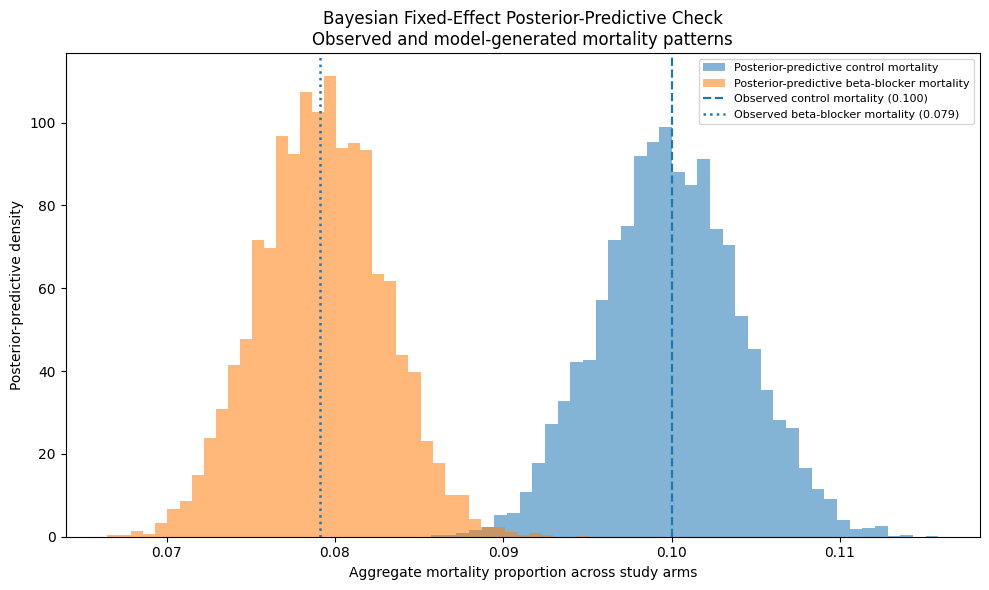

FIXED-EFFECT POSTERIOR-PREDICTIVE CHECK COMPLETED

Aggregate posterior-predictive summary:
         arm  observed_mortality_proportion  posterior_predictive_mean  posterior_predictive_median  posterior_predictive_lower_95  posterior_predictive_upper_95  observed_within_predictive_interval
     Control                       0.100010                   0.099963                     0.099909                       0.091989                       0.108133                                 True
Beta blocker                       0.079111                   0.079199                     0.079207                       0.072120                       0.086390                                 True

Study-level predictive interval coverage:
Control arms: 22 of 22 studies
Beta-blocker arms: 22 of 22 studies

Saved figure:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/07_bayesian_fixed_effect_posterior_predictive_check.png

Saved repository tables:
/conten

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Reload verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = (
    study_level["study_id"]
    .astype(int)
    .to_numpy()
)

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

observed_control_mortality = (
    control_deaths.sum() / control_n.sum()
)

observed_beta_mortality = (
    beta_deaths.sum() / beta_n.sum()
)

# ---------------------------------------------------------
# Draw posterior-predictive outcomes
# ---------------------------------------------------------
with fixed_effect_model:
    fixed_effect_ppc = pm.sample_posterior_predictive(
        fixed_effect_idata,
        var_names=[
            "control_deaths_obs",
            "beta_deaths_obs",
        ],
        random_seed=20260727,
        return_inferencedata=True,
    )

# ---------------------------------------------------------
# Extract simulated arm-level death counts
# ---------------------------------------------------------
control_deaths_simulated = (
    fixed_effect_ppc.posterior_predictive[
        "control_deaths_obs"
    ]
    .values
    .reshape(-1, len(study_ids))
)

beta_deaths_simulated = (
    fixed_effect_ppc.posterior_predictive[
        "beta_deaths_obs"
    ]
    .values
    .reshape(-1, len(study_ids))
)

aggregate_control_mortality_simulated = (
    control_deaths_simulated.sum(axis=1)
    / control_n.sum()
)

aggregate_beta_mortality_simulated = (
    beta_deaths_simulated.sum(axis=1)
    / beta_n.sum()
)

# ---------------------------------------------------------
# Create aggregate posterior-predictive summary
# ---------------------------------------------------------
aggregate_ppc_summary = pd.DataFrame(
    [
        {
            "arm": "Control",
            "observed_mortality_proportion": observed_control_mortality,
            "posterior_predictive_mean": (
                np.mean(
                    aggregate_control_mortality_simulated
                )
            ),
            "posterior_predictive_median": (
                np.median(
                    aggregate_control_mortality_simulated
                )
            ),
            "posterior_predictive_lower_95": (
                np.quantile(
                    aggregate_control_mortality_simulated,
                    0.025,
                )
            ),
            "posterior_predictive_upper_95": (
                np.quantile(
                    aggregate_control_mortality_simulated,
                    0.975,
                )
            ),
            "observed_within_predictive_interval": (
                np.quantile(
                    aggregate_control_mortality_simulated,
                    0.025,
                )
                <= observed_control_mortality
                <= np.quantile(
                    aggregate_control_mortality_simulated,
                    0.975,
                )
            ),
        },
        {
            "arm": "Beta blocker",
            "observed_mortality_proportion": observed_beta_mortality,
            "posterior_predictive_mean": (
                np.mean(
                    aggregate_beta_mortality_simulated
                )
            ),
            "posterior_predictive_median": (
                np.median(
                    aggregate_beta_mortality_simulated
                )
            ),
            "posterior_predictive_lower_95": (
                np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.025,
                )
            ),
            "posterior_predictive_upper_95": (
                np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.975,
                )
            ),
            "observed_within_predictive_interval": (
                np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.025,
                )
                <= observed_beta_mortality
                <= np.quantile(
                    aggregate_beta_mortality_simulated,
                    0.975,
                )
            ),
        },
    ]
)

# ---------------------------------------------------------
# Create study-level posterior-predictive audit table
# ---------------------------------------------------------
study_level_ppc = pd.DataFrame(
    {
        "study_id": study_ids,
        "observed_control_deaths": control_deaths,
        "predicted_control_deaths_mean": (
            control_deaths_simulated.mean(axis=0)
        ),
        "predicted_control_deaths_lower_95": (
            np.quantile(
                control_deaths_simulated,
                0.025,
                axis=0,
            )
        ),
        "predicted_control_deaths_upper_95": (
            np.quantile(
                control_deaths_simulated,
                0.975,
                axis=0,
            )
        ),
        "observed_beta_blocker_deaths": beta_deaths,
        "predicted_beta_blocker_deaths_mean": (
            beta_deaths_simulated.mean(axis=0)
        ),
        "predicted_beta_blocker_deaths_lower_95": (
            np.quantile(
                beta_deaths_simulated,
                0.025,
                axis=0,
            )
        ),
        "predicted_beta_blocker_deaths_upper_95": (
            np.quantile(
                beta_deaths_simulated,
                0.975,
                axis=0,
            )
        ),
    }
)

study_level_ppc[
    "control_observed_within_predictive_interval"
] = (
    study_level_ppc["observed_control_deaths"]
    >= study_level_ppc[
        "predicted_control_deaths_lower_95"
    ]
) & (
    study_level_ppc["observed_control_deaths"]
    <= study_level_ppc[
        "predicted_control_deaths_upper_95"
    ]
)

study_level_ppc[
    "beta_blocker_observed_within_predictive_interval"
] = (
    study_level_ppc["observed_beta_blocker_deaths"]
    >= study_level_ppc[
        "predicted_beta_blocker_deaths_lower_95"
    ]
) & (
    study_level_ppc["observed_beta_blocker_deaths"]
    <= study_level_ppc[
        "predicted_beta_blocker_deaths_upper_95"
    ]
)

# ---------------------------------------------------------
# Save repository-ready tables
# ---------------------------------------------------------
aggregate_summary_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_posterior_predictive_summary.csv"
)

study_level_ppc_file = (
    TABLE_DIR
    / "bayesian_fixed_effect_study_level_posterior_predictive_audit.csv"
)

aggregate_ppc_summary.to_csv(
    aggregate_summary_file,
    index=False,
)

study_level_ppc.to_csv(
    study_level_ppc_file,
    index=False,
)

# ---------------------------------------------------------
# Save posterior-predictive diagnostic object
# ---------------------------------------------------------
ppc_file = (
    DIAGNOSTIC_DIR
    / "bayesian_fixed_effect_posterior_predictive.nc"
)

az.to_netcdf(
    fixed_effect_ppc,
    ppc_file,
)

# ---------------------------------------------------------
# Create posterior-predictive visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    aggregate_control_mortality_simulated,
    bins=40,
    density=True,
    alpha=0.55,
    label="Posterior-predictive control mortality",
)

ax.hist(
    aggregate_beta_mortality_simulated,
    bins=40,
    density=True,
    alpha=0.55,
    label="Posterior-predictive beta-blocker mortality",
)

ax.axvline(
    observed_control_mortality,
    linestyle="--",
    linewidth=1.6,
    label=(
        "Observed control mortality "
        f"({observed_control_mortality:.3f})"
    ),
)

ax.axvline(
    observed_beta_mortality,
    linestyle=":",
    linewidth=1.8,
    label=(
        "Observed beta-blocker mortality "
        f"({observed_beta_mortality:.3f})"
    ),
)

ax.set_xlabel(
    "Aggregate mortality proportion across study arms"
)

ax.set_ylabel(
    "Posterior-predictive density"
)

ax.set_title(
    "Bayesian Fixed-Effect Posterior-Predictive Check\n"
    "Observed and model-generated mortality patterns"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

figure_file = (
    FIGURE_DIR
    / "07_bayesian_fixed_effect_posterior_predictive_check.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("FIXED-EFFECT POSTERIOR-PREDICTIVE CHECK COMPLETED")
print("=" * 92)

print("\nAggregate posterior-predictive summary:")
print(
    aggregate_ppc_summary
    .round(6)
    .to_string(index=False)
)

print("\nStudy-level predictive interval coverage:")
print(
    "Control arms: "
    f"{study_level_ppc['control_observed_within_predictive_interval'].sum()} "
    f"of {len(study_level_ppc)} studies"
)

print(
    "Beta-blocker arms: "
    f"{study_level_ppc['beta_blocker_observed_within_predictive_interval'].sum()} "
    f"of {len(study_level_ppc)} studies"
)

print("\nSaved figure:")
print(figure_file)

print("\nSaved repository tables:")
print(aggregate_summary_file)
print(study_level_ppc_file)

print("\nSaved posterior-predictive diagnostic object:")
print(ppc_file)

## 6. Bayesian Hierarchical Random-Effects Model

### 6.1 Primary Prior-Predictive Check

The hierarchical random-effects model allows the comparative treatment effect to vary across trials rather than assuming that every study has one identical underlying effect.

Before fitting the posterior model, prior-predictive simulation is used to verify that the primary priors generate clinically interpretable mortality patterns and a reasonable range of between-study heterogeneity.


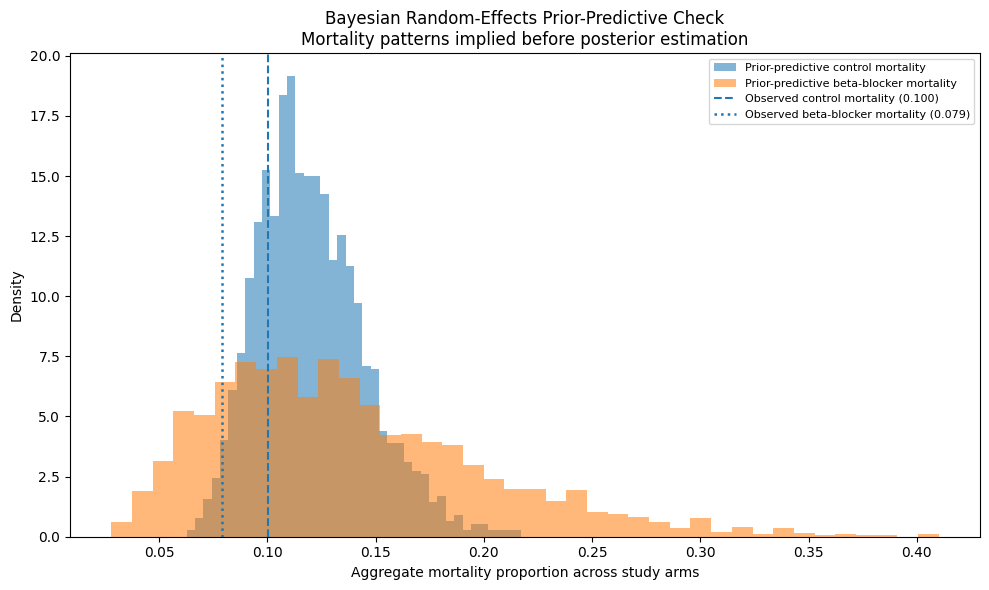

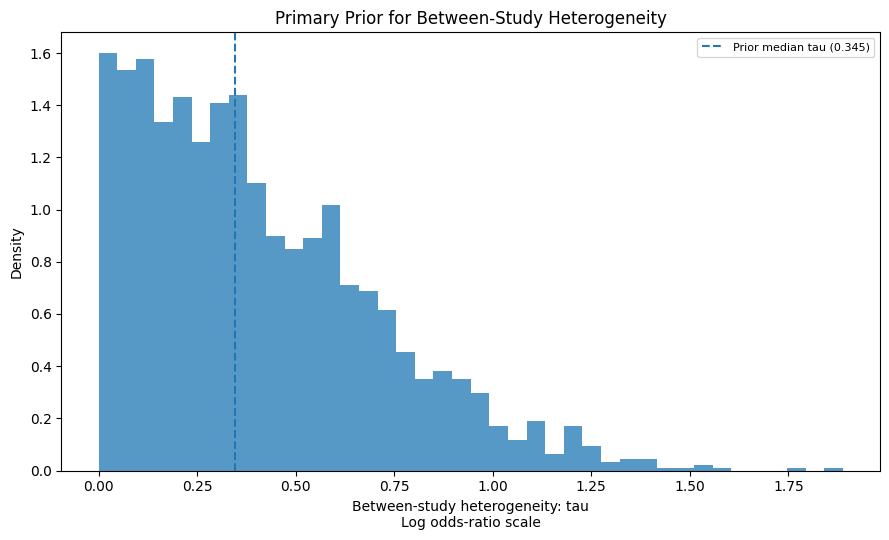

RANDOM-EFFECTS PRIMARY PRIOR-PREDICTIVE CHECK COMPLETED

Primary prior structure:
alpha_study ~ Normal(logit(0.10), 0.75)
mu ~ Normal(0, 0.5)
tau ~ HalfNormal(0.5)
delta_study = mu + tau * z_study
z_study ~ Normal(0, 1)

Observed descriptive aggregate mortality proportions:
Control: 0.1000
Beta blocker: 0.0791

Random-effects prior-predictive summary:
                                                    quantity   mean  median  lower_2_5_pct  upper_97_5_pct  minimum  maximum
        Prior pooled odds ratio: beta blocker versus control 1.1431  1.0153         0.3782          2.7321   0.2129   4.8338
                      Prior between-study heterogeneity: tau 0.4062  0.3453         0.0160          1.1300   0.0001   1.8880
                            Prior study-specific odds ratios 1.3171  0.9980         0.2417          4.0947   0.0064 105.2849
     Prior-predictive aggregate control mortality proportion 0.1202  0.1171         0.0803          0.1763   0.0626   0.2172
Prior-predictive aggr

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [TABLE_DIR, FIGURE_DIR, DIAGNOSTIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = study_level["study_id"].astype(int).to_numpy()

control_deaths = study_level["control_deaths"].astype(int).to_numpy()
control_n = study_level["control_participants"].astype(int).to_numpy()

beta_deaths = study_level["beta_blocker_deaths"].astype(int).to_numpy()
beta_n = study_level["beta_blocker_participants"].astype(int).to_numpy()

observed_control_mortality = control_deaths.sum() / control_n.sum()
observed_beta_mortality = beta_deaths.sum() / beta_n.sum()

# ---------------------------------------------------------
# Primary prior structure
# ---------------------------------------------------------
baseline_probability_center = 0.10

baseline_logit_mean = np.log(
    baseline_probability_center
    / (1 - baseline_probability_center)
)

baseline_logit_sigma = 0.75

coords = {
    "study": study_ids,
}

# ---------------------------------------------------------
# Build hierarchical random-effects model
# and draw from priors only
# ---------------------------------------------------------
with pm.Model(coords=coords) as random_effects_prior_model:

    alpha_study = pm.Normal(
        "alpha_study",
        mu=baseline_logit_mean,
        sigma=baseline_logit_sigma,
        dims="study",
    )

    mu = pm.Normal(
        "mu",
        mu=0.0,
        sigma=0.5,
    )

    tau = pm.HalfNormal(
        "tau",
        sigma=0.5,
    )

    z_study = pm.Normal(
        "z_study",
        mu=0.0,
        sigma=1.0,
        dims="study",
    )

    delta_study = pm.Deterministic(
        "delta_study",
        mu + tau * z_study,
        dims="study",
    )

    pooled_odds_ratio = pm.Deterministic(
        "pooled_odds_ratio",
        pm.math.exp(mu),
    )

    study_odds_ratio = pm.Deterministic(
        "study_odds_ratio",
        pm.math.exp(delta_study),
        dims="study",
    )

    p_control = pm.Deterministic(
        "p_control",
        pm.math.sigmoid(alpha_study),
        dims="study",
    )

    p_beta_blocker = pm.Deterministic(
        "p_beta_blocker",
        pm.math.sigmoid(alpha_study + delta_study),
        dims="study",
    )

    control_deaths_obs = pm.Binomial(
        "control_deaths_obs",
        n=control_n,
        p=p_control,
        observed=control_deaths,
        dims="study",
    )

    beta_deaths_obs = pm.Binomial(
        "beta_deaths_obs",
        n=beta_n,
        p=p_beta_blocker,
        observed=beta_deaths,
        dims="study",
    )

    random_effects_prior_predictive = pm.sample_prior_predictive(
        draws=2000,
        random_seed=20260727,
    )

# ---------------------------------------------------------
# Extract prior and prior-predictive draws
# ---------------------------------------------------------
prior_group = random_effects_prior_predictive.prior
prior_predictive_group = random_effects_prior_predictive.prior_predictive

tau_draws = prior_group["tau"].values.reshape(-1)

pooled_or_draws = (
    prior_group["pooled_odds_ratio"]
    .values
    .reshape(-1)
)

study_or_draws = (
    prior_group["study_odds_ratio"]
    .values
    .reshape(-1)
)

control_deaths_simulated = (
    prior_predictive_group["control_deaths_obs"]
    .values
    .reshape(-1, len(study_ids))
)

beta_deaths_simulated = (
    prior_predictive_group["beta_deaths_obs"]
    .values
    .reshape(-1, len(study_ids))
)

aggregate_control_mortality_simulated = (
    control_deaths_simulated.sum(axis=1)
    / control_n.sum()
)

aggregate_beta_mortality_simulated = (
    beta_deaths_simulated.sum(axis=1)
    / beta_n.sum()
)

# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------
def summarize_distribution(values, quantity):
    return {
        "quantity": quantity,
        "mean": np.mean(values),
        "median": np.median(values),
        "lower_2_5_pct": np.quantile(values, 0.025),
        "upper_97_5_pct": np.quantile(values, 0.975),
        "minimum": np.min(values),
        "maximum": np.max(values),
    }


random_effects_prior_summary = pd.DataFrame(
    [
        summarize_distribution(
            pooled_or_draws,
            "Prior pooled odds ratio: beta blocker versus control",
        ),
        summarize_distribution(
            tau_draws,
            "Prior between-study heterogeneity: tau",
        ),
        summarize_distribution(
            study_or_draws,
            "Prior study-specific odds ratios",
        ),
        summarize_distribution(
            aggregate_control_mortality_simulated,
            "Prior-predictive aggregate control mortality proportion",
        ),
        summarize_distribution(
            aggregate_beta_mortality_simulated,
            "Prior-predictive aggregate beta-blocker mortality proportion",
        ),
    ]
)

summary_file = (
    TABLE_DIR
    / "bayesian_random_effects_primary_prior_predictive_summary.csv"
)

random_effects_prior_summary.to_csv(
    summary_file,
    index=False,
)

# ---------------------------------------------------------
# Save diagnostic object
# ---------------------------------------------------------
diagnostic_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_primary_prior_predictive.nc"
)

az.to_netcdf(
    random_effects_prior_predictive,
    diagnostic_file,
)

# ---------------------------------------------------------
# Figure 1: prior-predictive mortality patterns
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    aggregate_control_mortality_simulated,
    bins=40,
    alpha=0.55,
    density=True,
    label="Prior-predictive control mortality",
)

ax.hist(
    aggregate_beta_mortality_simulated,
    bins=40,
    alpha=0.55,
    density=True,
    label="Prior-predictive beta-blocker mortality",
)

ax.axvline(
    observed_control_mortality,
    linestyle="--",
    linewidth=1.5,
    label=f"Observed control mortality ({observed_control_mortality:.3f})",
)

ax.axvline(
    observed_beta_mortality,
    linestyle=":",
    linewidth=1.8,
    label=f"Observed beta-blocker mortality ({observed_beta_mortality:.3f})",
)

ax.set_xlabel(
    "Aggregate mortality proportion across study arms"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Bayesian Random-Effects Prior-Predictive Check\n"
    "Mortality patterns implied before posterior estimation"
)

ax.legend(fontsize=8)

fig.tight_layout()

mortality_figure_file = (
    FIGURE_DIR
    / "08_bayesian_random_effects_prior_predictive_mortality.png"
)

fig.savefig(
    mortality_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Figure 2: heterogeneity prior
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    tau_draws,
    bins=40,
    density=True,
    alpha=0.75,
)

ax.axvline(
    np.median(tau_draws),
    linestyle="--",
    linewidth=1.5,
    label=f"Prior median tau ({np.median(tau_draws):.3f})",
)

ax.set_xlabel(
    "Between-study heterogeneity: tau\n"
    "Log odds-ratio scale"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Primary Prior for Between-Study Heterogeneity"
)

ax.legend(fontsize=8)

fig.tight_layout()

tau_figure_file = (
    FIGURE_DIR
    / "09_bayesian_random_effects_tau_prior.png"
)

fig.savefig(
    tau_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("RANDOM-EFFECTS PRIMARY PRIOR-PREDICTIVE CHECK COMPLETED")
print("=" * 96)

print("\nPrimary prior structure:")
print("alpha_study ~ Normal(logit(0.10), 0.75)")
print("mu ~ Normal(0, 0.5)")
print("tau ~ HalfNormal(0.5)")
print("delta_study = mu + tau * z_study")
print("z_study ~ Normal(0, 1)")

print("\nObserved descriptive aggregate mortality proportions:")
print(f"Control: {observed_control_mortality:.4f}")
print(f"Beta blocker: {observed_beta_mortality:.4f}")

print("\nRandom-effects prior-predictive summary:")
print(
    random_effects_prior_summary
    .round(4)
    .to_string(index=False)
)

print("\nSaved figures:")
print(mortality_figure_file)
print(tau_figure_file)

print("\nSaved summary table:")
print(summary_file)

print("\nSaved diagnostic object:")
print(diagnostic_file)

### 6.2 Hierarchical Random-Effects Posterior Estimation

The primary Bayesian hierarchical model is now fitted using the verified arm-level mortality counts.

The model estimates:

* the pooled comparative treatment effect;
* between-study heterogeneity;
* partially pooled study-specific treatment effects;
* and the predicted treatment effect for a future comparable trial.

The heterogeneity parameter `tau` is the standard deviation of trial-specific treatment effects on the log odds-ratio scale.

Posterior probability statements are reported for both the pooled effect and the predicted effect in a future comparable trial. This distinction is important: a pooled estimate summarizes the included evidence, while the predictive distribution reflects the additional uncertainty created by between-study variation.


In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = (
    study_level["study_id"]
    .astype(int)
    .to_numpy()
)

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

# ---------------------------------------------------------
# Primary prior structure
# ---------------------------------------------------------
baseline_probability_center = 0.10

baseline_logit_mean = np.log(
    baseline_probability_center
    / (1 - baseline_probability_center)
)

baseline_logit_sigma = 0.75

coords = {
    "study": study_ids,
}

# ---------------------------------------------------------
# Fit hierarchical random-effects posterior model
# ---------------------------------------------------------
with pm.Model(coords=coords) as random_effects_model:

    # Study-specific control-arm baseline mortality log odds
    alpha_study = pm.Normal(
        "alpha_study",
        mu=baseline_logit_mean,
        sigma=baseline_logit_sigma,
        dims="study",
    )

    # Pooled comparative treatment effect
    mu = pm.Normal(
        "mu",
        mu=0.0,
        sigma=0.5,
    )

    # Between-study heterogeneity
    tau = pm.HalfNormal(
        "tau",
        sigma=0.5,
    )

    # Non-centered parameterization
    z_study = pm.Normal(
        "z_study",
        mu=0.0,
        sigma=1.0,
        dims="study",
    )

    delta_study = pm.Deterministic(
        "delta_study",
        mu + tau * z_study,
        dims="study",
    )

    pooled_odds_ratio = pm.Deterministic(
        "pooled_odds_ratio",
        pm.math.exp(mu),
    )

    study_odds_ratio = pm.Deterministic(
        "study_odds_ratio",
        pm.math.exp(delta_study),
        dims="study",
    )

    # Mortality probabilities
    p_control = pm.Deterministic(
        "p_control",
        pm.math.sigmoid(alpha_study),
        dims="study",
    )

    p_beta_blocker = pm.Deterministic(
        "p_beta_blocker",
        pm.math.sigmoid(alpha_study + delta_study),
        dims="study",
    )

    # Arm-level binomial likelihoods
    control_deaths_obs = pm.Binomial(
        "control_deaths_obs",
        n=control_n,
        p=p_control,
        observed=control_deaths,
        dims="study",
    )

    beta_deaths_obs = pm.Binomial(
        "beta_deaths_obs",
        n=beta_n,
        p=p_beta_blocker,
        observed=beta_deaths,
        dims="study",
    )

    random_effects_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=2,
        target_accept=0.98,
        random_seed=20260727,
        return_inferencedata=True,
        idata_kwargs={
            "log_likelihood": True,
        },
    )

# ---------------------------------------------------------
# Save complete posterior object
# ---------------------------------------------------------
posterior_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_primary_posterior.nc"
)

az.to_netcdf(
    random_effects_idata,
    posterior_file,
)

# ---------------------------------------------------------
# Posterior draws
# ---------------------------------------------------------
mu_draws = (
    random_effects_idata.posterior["mu"]
    .values
    .reshape(-1)
)

tau_draws = (
    random_effects_idata.posterior["tau"]
    .values
    .reshape(-1)
)

pooled_or_draws = np.exp(mu_draws)

# Predicted treatment effect for a future comparable trial
rng = np.random.default_rng(
    20260727
)

future_log_or_draws = (
    mu_draws
    + tau_draws
    * rng.normal(
        size=len(mu_draws)
    )
)

future_or_draws = np.exp(
    future_log_or_draws
)

# ---------------------------------------------------------
# Core posterior summary
# ---------------------------------------------------------
core_summary = az.summary(
    random_effects_idata,
    var_names=[
        "mu",
        "tau",
        "pooled_odds_ratio",
    ],
    hdi_prob=0.95,
    round_to=6,
).reset_index().rename(
    columns={
        "index": "parameter",
    }
)

# ---------------------------------------------------------
# Clinically readable posterior probabilities
# ---------------------------------------------------------
posterior_probability_summary = pd.DataFrame(
    [
        {
            "probability_statement": (
                "Probability that the pooled effect favours beta blockers "
                "(pooled OR < 1)"
            ),
            "posterior_probability": np.mean(
                pooled_or_draws < 1.0
            ),
        },
        {
            "probability_statement": (
                "Probability of at least 10% lower pooled mortality odds "
                "(pooled OR < 0.90)"
            ),
            "posterior_probability": np.mean(
                pooled_or_draws < 0.90
            ),
        },
        {
            "probability_statement": (
                "Probability of at least 20% lower pooled mortality odds "
                "(pooled OR < 0.80)"
            ),
            "posterior_probability": np.mean(
                pooled_or_draws < 0.80
            ),
        },
        {
            "probability_statement": (
                "Probability that a future comparable trial favours "
                "beta blockers (future OR < 1)"
            ),
            "posterior_probability": np.mean(
                future_or_draws < 1.0
            ),
        },
        {
            "probability_statement": (
                "Probability that heterogeneity exceeds 0.10 "
                "on the log odds-ratio scale (tau > 0.10)"
            ),
            "posterior_probability": np.mean(
                tau_draws > 0.10
            ),
        },
        {
            "probability_statement": (
                "Probability that heterogeneity exceeds 0.20 "
                "on the log odds-ratio scale (tau > 0.20)"
            ),
            "posterior_probability": np.mean(
                tau_draws > 0.20
            ),
        },
    ]
)

# ---------------------------------------------------------
# Future comparable-trial prediction summary
# ---------------------------------------------------------
future_trial_summary = pd.DataFrame(
    [
        {
            "quantity": (
                "Predicted treatment odds ratio in a future comparable trial"
            ),
            "posterior_predictive_mean": np.mean(
                future_or_draws
            ),
            "posterior_predictive_median": np.median(
                future_or_draws
            ),
            "posterior_predictive_lower_95": np.quantile(
                future_or_draws,
                0.025,
            ),
            "posterior_predictive_upper_95": np.quantile(
                future_or_draws,
                0.975,
            ),
            "probability_future_or_below_1": np.mean(
                future_or_draws < 1.0
            ),
        }
    ]
)

# ---------------------------------------------------------
# Sampling diagnostics
# ---------------------------------------------------------
sampled_parameter_diagnostics = az.summary(
    random_effects_idata,
    var_names=[
        "alpha_study",
        "mu",
        "tau",
        "z_study",
    ],
    hdi_prob=0.95,
    round_to=6,
).reset_index().rename(
    columns={
        "index": "parameter",
    }
)

divergences = int(
    random_effects_idata.sample_stats["diverging"]
    .values
    .sum()
)

maximum_r_hat = float(
    sampled_parameter_diagnostics["r_hat"]
    .max()
)

minimum_ess_bulk = float(
    sampled_parameter_diagnostics["ess_bulk"]
    .min()
)

minimum_ess_tail = float(
    sampled_parameter_diagnostics["ess_tail"]
    .min()
)

convergence_summary = pd.DataFrame(
    [
        {
            "model": (
                "Bayesian hierarchical random-effects model"
            ),
            "chains": 4,
            "posterior_draws_per_chain": 3000,
            "tuning_draws_per_chain": 3000,
            "total_posterior_draws": 12000,
            "divergences": divergences,
            "maximum_r_hat": maximum_r_hat,
            "minimum_ess_bulk": minimum_ess_bulk,
            "minimum_ess_tail": minimum_ess_tail,
        }
    ]
)

# ---------------------------------------------------------
# Save repository-ready tables
# ---------------------------------------------------------
core_summary_file = (
    TABLE_DIR
    / "bayesian_random_effects_primary_summary.csv"
)

probability_file = (
    TABLE_DIR
    / "bayesian_random_effects_primary_posterior_probability_summary.csv"
)

future_trial_file = (
    TABLE_DIR
    / "bayesian_random_effects_future_trial_prediction_summary.csv"
)

convergence_file = (
    TABLE_DIR
    / "bayesian_random_effects_primary_convergence_summary.csv"
)

parameter_diagnostics_file = (
    TABLE_DIR
    / "bayesian_random_effects_primary_all_parameter_diagnostics.csv"
)

core_summary.to_csv(
    core_summary_file,
    index=False,
)

posterior_probability_summary.to_csv(
    probability_file,
    index=False,
)

future_trial_summary.to_csv(
    future_trial_file,
    index=False,
)

convergence_summary.to_csv(
    convergence_file,
    index=False,
)

sampled_parameter_diagnostics.to_csv(
    parameter_diagnostics_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("BAYESIAN RANDOM-EFFECTS POSTERIOR MODEL COMPLETED")
print("=" * 96)

print("\nCore posterior summary:")
print(
    core_summary
    .to_string(index=False)
)

print("\nClinically readable posterior probabilities:")
print(
    posterior_probability_summary
    .round(6)
    .to_string(index=False)
)

print("\nFuture comparable-trial prediction summary:")
print(
    future_trial_summary
    .round(6)
    .to_string(index=False)
)

print("\nConvergence summary:")
print(
    convergence_summary
    .round(6)
    .to_string(index=False)
)

print("\nSaved posterior object:")
print(posterior_file)

print("\nSaved repository tables:")
print(core_summary_file)
print(probability_file)
print(future_trial_file)
print(convergence_file)
print(parameter_diagnostics_file)

Output()

BAYESIAN RANDOM-EFFECTS POSTERIOR MODEL COMPLETED

Core posterior summary:
        parameter      mean       sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd    ess_bulk    ess_tail    r_hat
               mu -0.247782 0.062050 -0.369683  -0.122471   0.000763 0.000623 6682.273329 7280.092239 1.000309
              tau  0.125530 0.076882  0.000039   0.264429   0.001448 0.000718 2646.762885 4027.651643 1.002004
pooled_odds_ratio  0.782036 0.048660  0.690953   0.884732   0.000601 0.000509 6682.273329 7280.092239 1.000291

Clinically readable posterior probabilities:
                                                               probability_statement  posterior_probability
            Probability that the pooled effect favours beta blockers (pooled OR < 1)               0.999917
          Probability of at least 10% lower pooled mortality odds (pooled OR < 0.90)               0.986417
          Probability of at least 20% lower pooled mortality odds (pooled OR < 0.80)               0.666667
   

### 6.3 Random-Effects Posterior Visualization and Trace Diagnostics

The hierarchical-model posterior is visualized for:

* the pooled mortality odds ratio;
* between-study heterogeneity;
* and the predicted treatment effect in a future comparable trial.

The pooled posterior summarizes the average comparative evidence across the included trials.

The future-trial predictive distribution is wider because it incorporates both posterior uncertainty and between-study heterogeneity.

Trace plots are also inspected for the pooled treatment effect, heterogeneity parameter, and pooled odds ratio to assess chain mixing and sampling stability.


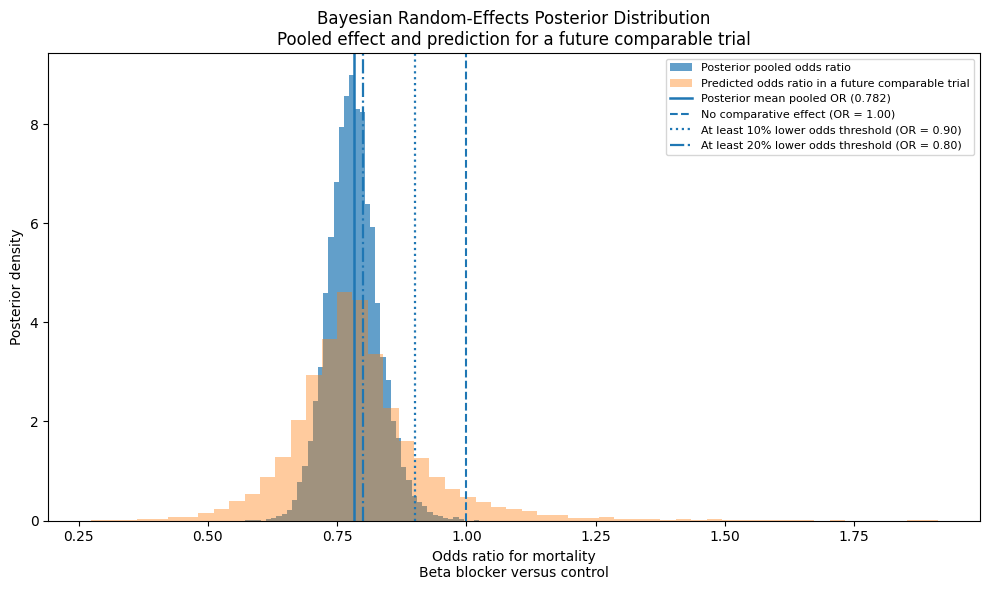

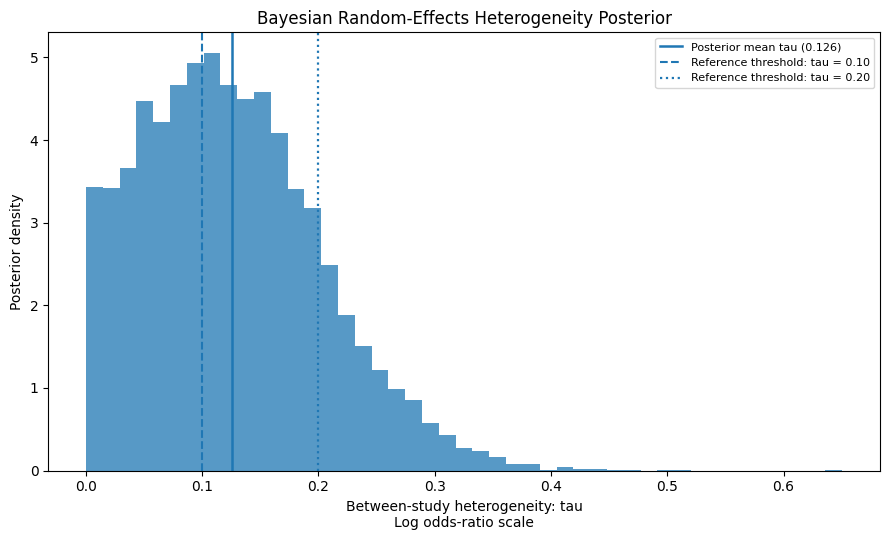

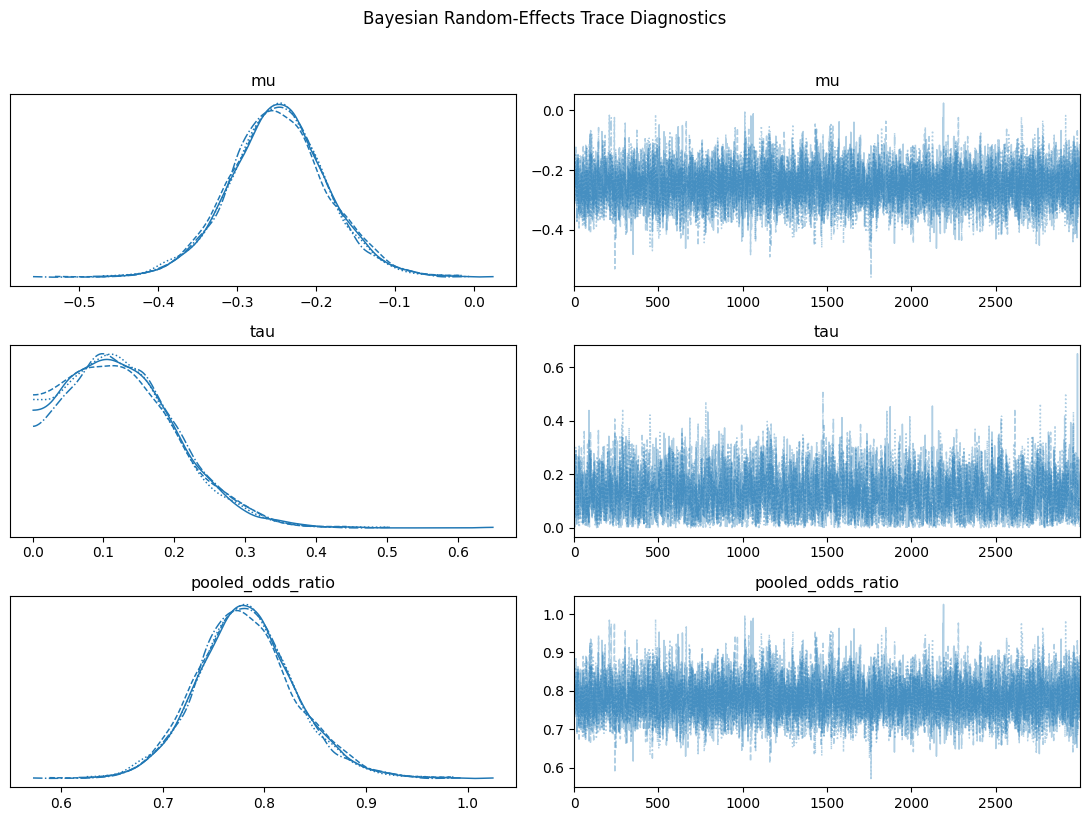

RANDOM-EFFECTS POSTERIOR AND TRACE FIGURES CREATED SUCCESSFULLY

Posterior plot summary:
                                         quantity     mean   median  lower_95  upper_95  probability_below_1
                      Posterior pooled odds ratio 0.782036 0.780254  0.690347  0.884438             0.999917
Predicted odds ratio in a future comparable trial 0.790773 0.778551  0.562109  1.102438             0.942583
                 Between-study heterogeneity: tau 0.125530 0.118175  0.008024  0.294903                  NaN

Saved figures:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/10_bayesian_random_effects_pooled_and_future_or_distribution.png
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/11_bayesian_random_effects_tau_posterior.png
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/12_bayesian_random_effects_trace_plot.png

Saved plot a

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Extract posterior draws
# ---------------------------------------------------------
mu_draws = (
    random_effects_idata.posterior["mu"]
    .values
    .reshape(-1)
)

tau_draws = (
    random_effects_idata.posterior["tau"]
    .values
    .reshape(-1)
)

pooled_or_draws = np.exp(mu_draws)

rng = np.random.default_rng(20260727)

future_log_or_draws = (
    mu_draws
    + tau_draws * rng.normal(size=len(mu_draws))
)

future_or_draws = np.exp(
    future_log_or_draws
)

# ---------------------------------------------------------
# Central posterior intervals for plotting
# ---------------------------------------------------------
pooled_or_lower = np.quantile(
    pooled_or_draws,
    0.025,
)

pooled_or_upper = np.quantile(
    pooled_or_draws,
    0.975,
)

tau_lower = np.quantile(
    tau_draws,
    0.025,
)

tau_upper = np.quantile(
    tau_draws,
    0.975,
)

future_or_lower = np.quantile(
    future_or_draws,
    0.025,
)

future_or_upper = np.quantile(
    future_or_draws,
    0.975,
)

# ---------------------------------------------------------
# Figure 1: pooled and future-trial OR distributions
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    pooled_or_draws,
    bins=45,
    density=True,
    alpha=0.70,
    label="Posterior pooled odds ratio",
)

ax.hist(
    future_or_draws,
    bins=55,
    density=True,
    alpha=0.40,
    label="Predicted odds ratio in a future comparable trial",
)

ax.axvline(
    np.mean(pooled_or_draws),
    linestyle="-",
    linewidth=1.8,
    label=(
        "Posterior mean pooled OR "
        f"({np.mean(pooled_or_draws):.3f})"
    ),
)

ax.axvline(
    1.00,
    linestyle="--",
    linewidth=1.5,
    label="No comparative effect (OR = 1.00)",
)

ax.axvline(
    0.90,
    linestyle=":",
    linewidth=1.6,
    label="At least 10% lower odds threshold (OR = 0.90)",
)

ax.axvline(
    0.80,
    linestyle="-.",
    linewidth=1.6,
    label="At least 20% lower odds threshold (OR = 0.80)",
)

ax.set_xlabel(
    "Odds ratio for mortality\n"
    "Beta blocker versus control"
)

ax.set_ylabel(
    "Posterior density"
)

ax.set_title(
    "Bayesian Random-Effects Posterior Distribution\n"
    "Pooled effect and prediction for a future comparable trial"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

or_figure_file = (
    FIGURE_DIR
    / "10_bayesian_random_effects_pooled_and_future_or_distribution.png"
)

fig.savefig(
    or_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Figure 2: heterogeneity posterior
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.hist(
    tau_draws,
    bins=45,
    density=True,
    alpha=0.75,
)

ax.axvline(
    np.mean(tau_draws),
    linestyle="-",
    linewidth=1.8,
    label=(
        "Posterior mean tau "
        f"({np.mean(tau_draws):.3f})"
    ),
)

ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1.5,
    label="Reference threshold: tau = 0.10",
)

ax.axvline(
    0.20,
    linestyle=":",
    linewidth=1.6,
    label="Reference threshold: tau = 0.20",
)

ax.set_xlabel(
    "Between-study heterogeneity: tau\n"
    "Log odds-ratio scale"
)

ax.set_ylabel(
    "Posterior density"
)

ax.set_title(
    "Bayesian Random-Effects Heterogeneity Posterior"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

tau_figure_file = (
    FIGURE_DIR
    / "11_bayesian_random_effects_tau_posterior.png"
)

fig.savefig(
    tau_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Figure 3: trace diagnostics
# ---------------------------------------------------------
trace_axes = az.plot_trace(
    random_effects_idata,
    var_names=[
        "mu",
        "tau",
        "pooled_odds_ratio",
    ],
    compact=True,
    figsize=(11, 8),
)

trace_figure = np.asarray(
    trace_axes
).reshape(-1)[0].figure

trace_figure.suptitle(
    "Bayesian Random-Effects Trace Diagnostics",
    y=1.02,
)

trace_figure.tight_layout()

trace_figure_file = (
    FIGURE_DIR
    / "12_bayesian_random_effects_trace_plot.png"
)

trace_figure.savefig(
    trace_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Save plot-ready audit table
# ---------------------------------------------------------
posterior_plot_summary = pd.DataFrame(
    [
        {
            "quantity": "Posterior pooled odds ratio",
            "mean": np.mean(pooled_or_draws),
            "median": np.median(pooled_or_draws),
            "lower_95": pooled_or_lower,
            "upper_95": pooled_or_upper,
            "probability_below_1": np.mean(
                pooled_or_draws < 1.0
            ),
        },
        {
            "quantity": (
                "Predicted odds ratio in a future comparable trial"
            ),
            "mean": np.mean(future_or_draws),
            "median": np.median(future_or_draws),
            "lower_95": future_or_lower,
            "upper_95": future_or_upper,
            "probability_below_1": np.mean(
                future_or_draws < 1.0
            ),
        },
        {
            "quantity": "Between-study heterogeneity: tau",
            "mean": np.mean(tau_draws),
            "median": np.median(tau_draws),
            "lower_95": tau_lower,
            "upper_95": tau_upper,
            "probability_below_1": np.nan,
        },
    ]
)

posterior_plot_summary_file = (
    TABLE_DIR
    / "bayesian_random_effects_posterior_plot_summary.csv"
)

posterior_plot_summary.to_csv(
    posterior_plot_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("RANDOM-EFFECTS POSTERIOR AND TRACE FIGURES CREATED SUCCESSFULLY")
print("=" * 96)

print("\nPosterior plot summary:")
print(
    posterior_plot_summary
    .round(6)
    .to_string(index=False)
)

print("\nSaved figures:")
print(or_figure_file)
print(tau_figure_file)
print(trace_figure_file)

print("\nSaved plot audit table:")
print(posterior_plot_summary_file)

### 6.4 Bayesian Forest Plot with Partially Pooled Study-Specific Effects

The hierarchical model produces a posterior treatment-effect distribution for each trial.

These study-specific estimates are partially pooled toward the overall treatment effect:

* larger, more informative trials retain stronger influence from their observed evidence;
* smaller, less precise trials are stabilized more strongly by the hierarchical structure;
* and the pooled estimate summarizes the average comparative evidence across the included trials.

The forest plot compares the raw study-specific odds ratios with the Bayesian partially pooled estimates. It also displays the pooled posterior estimate and the predictive interval for a future comparable trial.


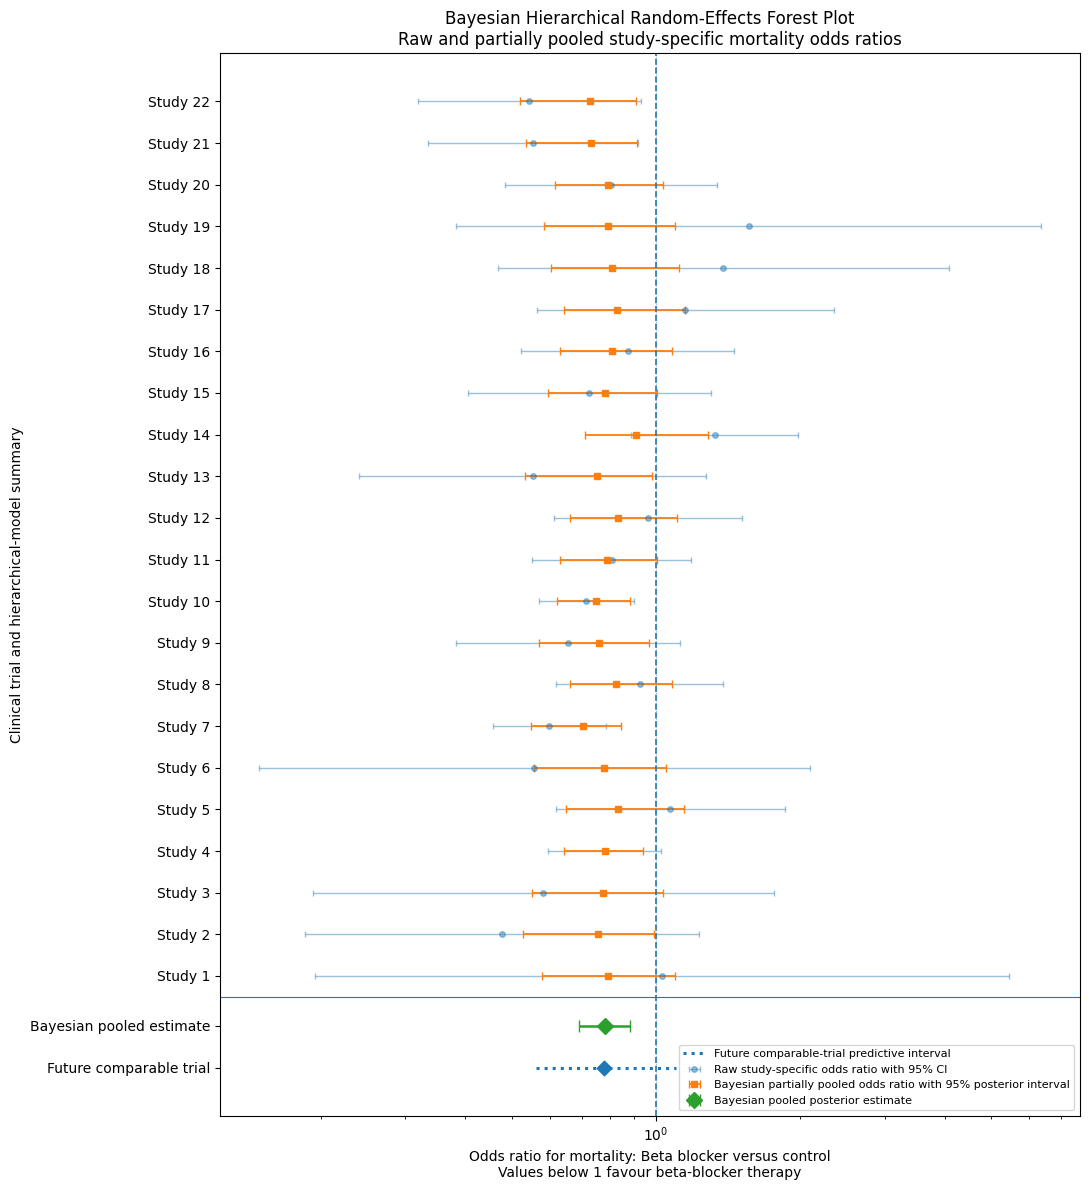

BAYESIAN PARTIAL-POOLING FOREST PLOT CREATED SUCCESSFULLY

Pooled posterior odds ratio:
0.7820 (0.6903 to 0.8844)

Future comparable-trial predictive interval:
0.5621 to 1.1024

Study-specific partially pooled posterior summary:
 study_id  odds_ratio  bayesian_partial_pooling_or_mean  bayesian_partial_pooling_or_lower_95  bayesian_partial_pooling_or_upper_95  posterior_probability_or_below_1
        1      1.0286                            0.7941                                0.5769                                1.0974                            0.9407
        2      0.4766                            0.7569                                0.5287                                0.9890                            0.9789
        3      0.5824                            0.7746                                0.5516                                1.0338                            0.9638
        4      0.7818                            0.7822                                0.6429              

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Reload verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = (
    study_level["study_id"]
    .astype(int)
    .to_numpy()
)

# ---------------------------------------------------------
# Extract hierarchical posterior draws
# ---------------------------------------------------------
study_or_draws = (
    random_effects_idata.posterior["study_odds_ratio"]
    .values
    .reshape(-1, len(study_ids))
)

mu_draws = (
    random_effects_idata.posterior["mu"]
    .values
    .reshape(-1)
)

tau_draws = (
    random_effects_idata.posterior["tau"]
    .values
    .reshape(-1)
)

pooled_or_draws = np.exp(mu_draws)

# Predicted treatment effect for a future comparable trial
rng = np.random.default_rng(20260727)

future_log_or_draws = (
    mu_draws
    + tau_draws
    * rng.normal(size=len(mu_draws))
)

future_or_draws = np.exp(
    future_log_or_draws
)

# ---------------------------------------------------------
# Summarize partially pooled study-specific effects
# ---------------------------------------------------------
study_posterior_summary = pd.DataFrame(
    {
        "study_id": study_ids,
        "bayesian_partial_pooling_or_mean": (
            study_or_draws.mean(axis=0)
        ),
        "bayesian_partial_pooling_or_median": (
            np.median(
                study_or_draws,
                axis=0,
            )
        ),
        "bayesian_partial_pooling_or_lower_95": (
            np.quantile(
                study_or_draws,
                0.025,
                axis=0,
            )
        ),
        "bayesian_partial_pooling_or_upper_95": (
            np.quantile(
                study_or_draws,
                0.975,
                axis=0,
            )
        ),
        "posterior_probability_or_below_1": (
            np.mean(
                study_or_draws < 1.0,
                axis=0,
            )
        ),
    }
)

# ---------------------------------------------------------
# Merge raw and Bayesian study-level evidence
# ---------------------------------------------------------
plot_data = study_level[
    [
        "study_id",
        "odds_ratio",
        "or_ci_lower_95",
        "or_ci_upper_95",
        "total_participants",
    ]
].merge(
    study_posterior_summary,
    on="study_id",
    how="left",
    validate="one_to_one",
)

plot_data = plot_data.sort_values(
    "study_id",
    ascending=False,
).reset_index(drop=True)

# ---------------------------------------------------------
# Quantify partial pooling movement
# ---------------------------------------------------------
plot_data["absolute_log_or_shift_toward_hierarchical_estimate"] = np.abs(
    np.log(
        plot_data["bayesian_partial_pooling_or_mean"]
    )
    - np.log(
        plot_data["odds_ratio"]
    )
)

# ---------------------------------------------------------
# Prepare plotting values
# ---------------------------------------------------------
study_y = np.arange(
    len(plot_data),
    0,
    -1,
)

raw_or = plot_data["odds_ratio"].to_numpy()

raw_lower = plot_data[
    "or_ci_lower_95"
].to_numpy()

raw_upper = plot_data[
    "or_ci_upper_95"
].to_numpy()

bayes_or = plot_data[
    "bayesian_partial_pooling_or_mean"
].to_numpy()

bayes_lower = plot_data[
    "bayesian_partial_pooling_or_lower_95"
].to_numpy()

bayes_upper = plot_data[
    "bayesian_partial_pooling_or_upper_95"
].to_numpy()

raw_errors = np.vstack(
    [
        raw_or - raw_lower,
        raw_upper - raw_or,
    ]
)

bayes_errors = np.vstack(
    [
        bayes_or - bayes_lower,
        bayes_upper - bayes_or,
    ]
)

pooled_or_mean = np.mean(
    pooled_or_draws
)

pooled_or_lower = np.quantile(
    pooled_or_draws,
    0.025,
)

pooled_or_upper = np.quantile(
    pooled_or_draws,
    0.975,
)

future_or_median = np.median(
    future_or_draws
)

future_or_lower = np.quantile(
    future_or_draws,
    0.025,
)

future_or_upper = np.quantile(
    future_or_draws,
    0.975,
)

pooled_y = -0.2
future_y = -1.2

# ---------------------------------------------------------
# Create Bayesian forest plot
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(11, 12)
)

# Raw study-specific estimates
ax.errorbar(
    raw_or,
    study_y,
    xerr=raw_errors,
    fmt="o",
    markersize=4,
    capsize=2,
    linewidth=1.0,
    alpha=0.45,
    label="Raw study-specific odds ratio with 95% CI",
)

# Bayesian partially pooled study-specific estimates
ax.errorbar(
    bayes_or,
    study_y,
    xerr=bayes_errors,
    fmt="s",
    markersize=5,
    capsize=3,
    linewidth=1.3,
    label="Bayesian partially pooled odds ratio with 95% posterior interval",
)

# Pooled posterior estimate
ax.errorbar(
    pooled_or_mean,
    pooled_y,
    xerr=np.array(
        [
            [pooled_or_mean - pooled_or_lower],
            [pooled_or_upper - pooled_or_mean],
        ]
    ),
    fmt="D",
    markersize=8,
    capsize=4,
    linewidth=1.8,
    label="Bayesian pooled posterior estimate",
)

# Future comparable-trial predictive interval
ax.hlines(
    y=future_y,
    xmin=future_or_lower,
    xmax=future_or_upper,
    linewidth=2.2,
    linestyle=":",
    label="Future comparable-trial predictive interval",
)

ax.scatter(
    future_or_median,
    future_y,
    marker="D",
    s=55,
    zorder=3,
)

# Reference line and separator
ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.2,
)

ax.axhline(
    0.5,
    linestyle="-",
    linewidth=0.8,
)

# Axis labels
ax.set_xscale(
    "log"
)

ax.set_yticks(
    list(study_y)
    + [
        pooled_y,
        future_y,
    ]
)

ax.set_yticklabels(
    [
        f"Study {study_id}"
        for study_id in plot_data["study_id"]
    ]
    + [
        "Bayesian pooled estimate",
        "Future comparable trial",
    ]
)

ax.set_xlabel(
    "Odds ratio for mortality: Beta blocker versus control\n"
    "Values below 1 favour beta-blocker therapy"
)

ax.set_ylabel(
    "Clinical trial and hierarchical-model summary"
)

ax.set_title(
    "Bayesian Hierarchical Random-Effects Forest Plot\n"
    "Raw and partially pooled study-specific mortality odds ratios"
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
)

ax.legend(
    loc="lower right",
    fontsize=8,
)

fig.tight_layout()

# ---------------------------------------------------------
# Save publication-style figure
# ---------------------------------------------------------
figure_file = (
    FIGURE_DIR
    / "13_bayesian_random_effects_partial_pooling_forest_plot.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Save repository-ready table
# ---------------------------------------------------------
study_summary_file = (
    TABLE_DIR
    / "bayesian_random_effects_study_level_posterior_summary.csv"
)

plot_data.to_csv(
    study_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("BAYESIAN PARTIAL-POOLING FOREST PLOT CREATED SUCCESSFULLY")
print("=" * 96)

print("\nPooled posterior odds ratio:")
print(
    f"{pooled_or_mean:.4f} "
    f"({pooled_or_lower:.4f} "
    f"to {pooled_or_upper:.4f})"
)

print("\nFuture comparable-trial predictive interval:")
print(
    f"{future_or_lower:.4f} "
    f"to {future_or_upper:.4f}"
)

print("\nStudy-specific partially pooled posterior summary:")
print(
    plot_data[
        [
            "study_id",
            "odds_ratio",
            "bayesian_partial_pooling_or_mean",
            "bayesian_partial_pooling_or_lower_95",
            "bayesian_partial_pooling_or_upper_95",
            "posterior_probability_or_below_1",
        ]
    ]
    .sort_values("study_id")
    .round(4)
    .to_string(index=False)
)

print("\nSaved figure:")
print(figure_file)

print("\nSaved repository table:")
print(study_summary_file)

### 6.5 Random-Effects Posterior-Predictive Check

Posterior-predictive simulation is used to assess whether the fitted hierarchical random-effects model can reproduce mortality patterns similar to those observed in the included trials.

The assessment examines:

* aggregate mortality patterns across the control arms;
* aggregate mortality patterns across the beta-blocker arms;
* observed versus posterior-predictive study-level death counts;
* and predictive-interval coverage across trials.

This diagnostic complements the convergence checks. A model should not be judged solely by successful sampling or a pooled estimate.


Output()

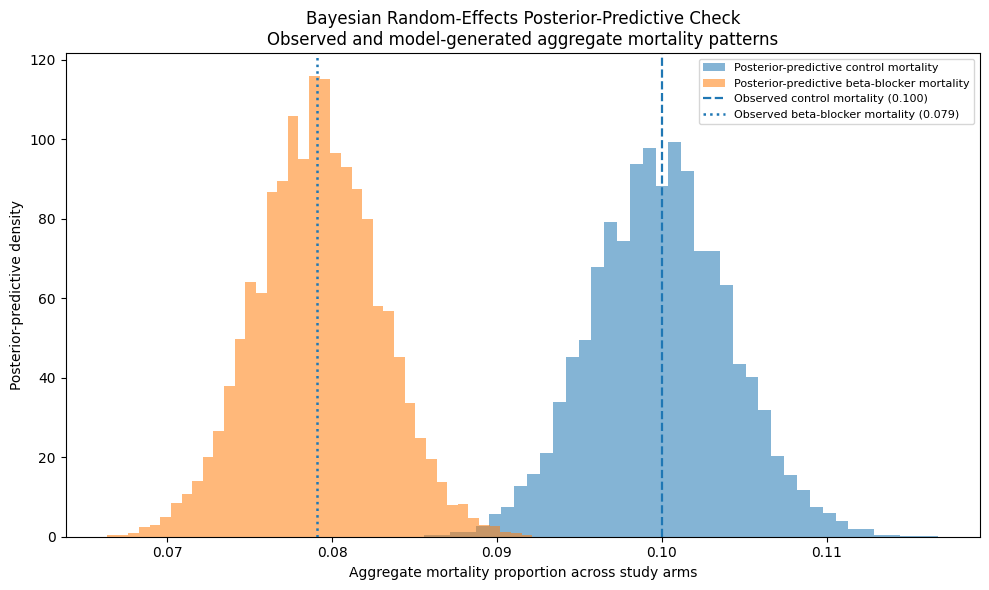

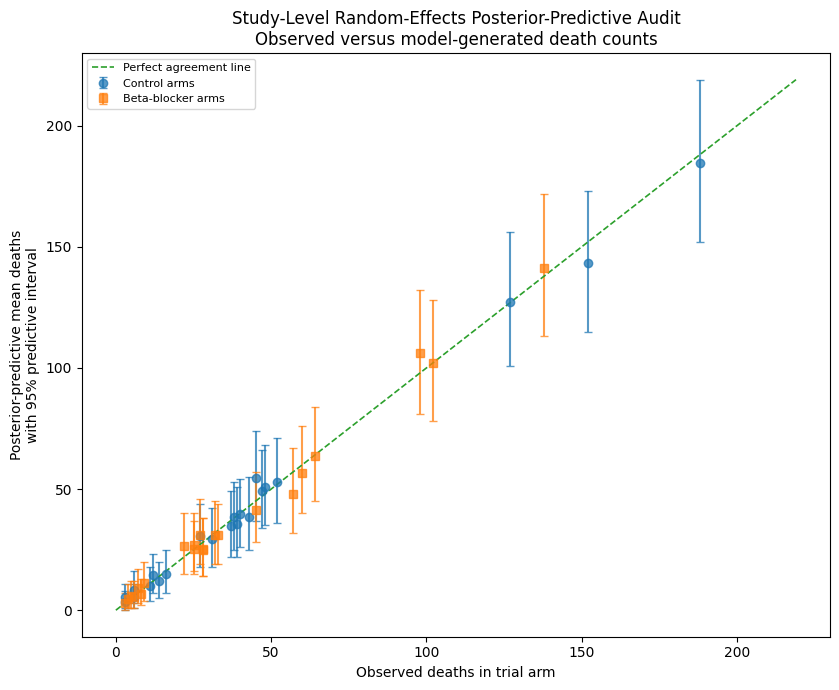

RANDOM-EFFECTS POSTERIOR-PREDICTIVE CHECK COMPLETED

Aggregate posterior-predictive summary:
         arm  observed_mortality_proportion  posterior_predictive_mean  posterior_predictive_median  posterior_predictive_lower_95  posterior_predictive_upper_95  observed_within_predictive_interval
     Control                       0.100010                   0.099937                     0.099909                       0.091786                       0.108336                                 True
Beta blocker                       0.079111                   0.079150                     0.079111                       0.071832                       0.086582                                 True

Study-level predictive interval coverage:
Control arms: 22 of 22 studies
Beta-blocker arms: 22 of 22 studies

Mean absolute prediction error in death counts:
Control arms: 2.5651
Beta-blocker arms: 2.4829

Saved figures:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/output

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [TABLE_DIR, FIGURE_DIR, DIAGNOSTIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = study_level["study_id"].astype(int).to_numpy()

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

observed_control_mortality = (
    control_deaths.sum() / control_n.sum()
)

observed_beta_mortality = (
    beta_deaths.sum() / beta_n.sum()
)

# ---------------------------------------------------------
# Reload saved posterior object if the runtime was refreshed
# ---------------------------------------------------------
posterior_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_primary_posterior.nc"
)

if "random_effects_idata" not in globals():
    random_effects_idata = az.from_netcdf(
        posterior_file
    )

# ---------------------------------------------------------
# Reconstruct the fitted model structure
# ---------------------------------------------------------
baseline_probability_center = 0.10

baseline_logit_mean = np.log(
    baseline_probability_center
    / (1 - baseline_probability_center)
)

baseline_logit_sigma = 0.75

coords = {
    "study": study_ids,
}

with pm.Model(coords=coords) as random_effects_ppc_model:

    alpha_study = pm.Normal(
        "alpha_study",
        mu=baseline_logit_mean,
        sigma=baseline_logit_sigma,
        dims="study",
    )

    mu = pm.Normal(
        "mu",
        mu=0.0,
        sigma=0.5,
    )

    tau = pm.HalfNormal(
        "tau",
        sigma=0.5,
    )

    z_study = pm.Normal(
        "z_study",
        mu=0.0,
        sigma=1.0,
        dims="study",
    )

    delta_study = pm.Deterministic(
        "delta_study",
        mu + tau * z_study,
        dims="study",
    )

    p_control = pm.Deterministic(
        "p_control",
        pm.math.sigmoid(alpha_study),
        dims="study",
    )

    p_beta_blocker = pm.Deterministic(
        "p_beta_blocker",
        pm.math.sigmoid(alpha_study + delta_study),
        dims="study",
    )

    control_deaths_obs = pm.Binomial(
        "control_deaths_obs",
        n=control_n,
        p=p_control,
        observed=control_deaths,
        dims="study",
    )

    beta_deaths_obs = pm.Binomial(
        "beta_deaths_obs",
        n=beta_n,
        p=p_beta_blocker,
        observed=beta_deaths,
        dims="study",
    )

    random_effects_ppc = pm.sample_posterior_predictive(
        random_effects_idata,
        var_names=[
            "control_deaths_obs",
            "beta_deaths_obs",
        ],
        random_seed=20260727,
        return_inferencedata=True,
    )

# ---------------------------------------------------------
# Extract simulated death counts
# ---------------------------------------------------------
control_deaths_simulated = (
    random_effects_ppc.posterior_predictive[
        "control_deaths_obs"
    ]
    .values
    .reshape(-1, len(study_ids))
)

beta_deaths_simulated = (
    random_effects_ppc.posterior_predictive[
        "beta_deaths_obs"
    ]
    .values
    .reshape(-1, len(study_ids))
)

aggregate_control_mortality_simulated = (
    control_deaths_simulated.sum(axis=1)
    / control_n.sum()
)

aggregate_beta_mortality_simulated = (
    beta_deaths_simulated.sum(axis=1)
    / beta_n.sum()
)

# ---------------------------------------------------------
# Aggregate posterior-predictive summary
# ---------------------------------------------------------
aggregate_ppc_summary = pd.DataFrame(
    [
        {
            "arm": "Control",
            "observed_mortality_proportion": observed_control_mortality,
            "posterior_predictive_mean": np.mean(
                aggregate_control_mortality_simulated
            ),
            "posterior_predictive_median": np.median(
                aggregate_control_mortality_simulated
            ),
            "posterior_predictive_lower_95": np.quantile(
                aggregate_control_mortality_simulated,
                0.025,
            ),
            "posterior_predictive_upper_95": np.quantile(
                aggregate_control_mortality_simulated,
                0.975,
            ),
        },
        {
            "arm": "Beta blocker",
            "observed_mortality_proportion": observed_beta_mortality,
            "posterior_predictive_mean": np.mean(
                aggregate_beta_mortality_simulated
            ),
            "posterior_predictive_median": np.median(
                aggregate_beta_mortality_simulated
            ),
            "posterior_predictive_lower_95": np.quantile(
                aggregate_beta_mortality_simulated,
                0.025,
            ),
            "posterior_predictive_upper_95": np.quantile(
                aggregate_beta_mortality_simulated,
                0.975,
            ),
        },
    ]
)

aggregate_ppc_summary[
    "observed_within_predictive_interval"
] = (
    aggregate_ppc_summary[
        "observed_mortality_proportion"
    ]
    >= aggregate_ppc_summary[
        "posterior_predictive_lower_95"
    ]
) & (
    aggregate_ppc_summary[
        "observed_mortality_proportion"
    ]
    <= aggregate_ppc_summary[
        "posterior_predictive_upper_95"
    ]
)

# ---------------------------------------------------------
# Study-level posterior-predictive summary
# ---------------------------------------------------------
study_level_ppc = pd.DataFrame(
    {
        "study_id": study_ids,
        "observed_control_deaths": control_deaths,
        "predicted_control_deaths_mean": (
            control_deaths_simulated.mean(axis=0)
        ),
        "predicted_control_deaths_lower_95": np.quantile(
            control_deaths_simulated,
            0.025,
            axis=0,
        ),
        "predicted_control_deaths_upper_95": np.quantile(
            control_deaths_simulated,
            0.975,
            axis=0,
        ),
        "observed_beta_blocker_deaths": beta_deaths,
        "predicted_beta_blocker_deaths_mean": (
            beta_deaths_simulated.mean(axis=0)
        ),
        "predicted_beta_blocker_deaths_lower_95": np.quantile(
            beta_deaths_simulated,
            0.025,
            axis=0,
        ),
        "predicted_beta_blocker_deaths_upper_95": np.quantile(
            beta_deaths_simulated,
            0.975,
            axis=0,
        ),
    }
)

study_level_ppc[
    "control_observed_within_predictive_interval"
] = (
    study_level_ppc["observed_control_deaths"]
    >= study_level_ppc[
        "predicted_control_deaths_lower_95"
    ]
) & (
    study_level_ppc["observed_control_deaths"]
    <= study_level_ppc[
        "predicted_control_deaths_upper_95"
    ]
)

study_level_ppc[
    "beta_blocker_observed_within_predictive_interval"
] = (
    study_level_ppc[
        "observed_beta_blocker_deaths"
    ]
    >= study_level_ppc[
        "predicted_beta_blocker_deaths_lower_95"
    ]
) & (
    study_level_ppc[
        "observed_beta_blocker_deaths"
    ]
    <= study_level_ppc[
        "predicted_beta_blocker_deaths_upper_95"
    ]
)

study_level_ppc[
    "absolute_error_control_deaths"
] = np.abs(
    study_level_ppc[
        "observed_control_deaths"
    ]
    - study_level_ppc[
        "predicted_control_deaths_mean"
    ]
)

study_level_ppc[
    "absolute_error_beta_blocker_deaths"
] = np.abs(
    study_level_ppc[
        "observed_beta_blocker_deaths"
    ]
    - study_level_ppc[
        "predicted_beta_blocker_deaths_mean"
    ]
)

# ---------------------------------------------------------
# Save repository-ready tables
# ---------------------------------------------------------
aggregate_summary_file = (
    TABLE_DIR
    / "bayesian_random_effects_posterior_predictive_summary.csv"
)

study_level_ppc_file = (
    TABLE_DIR
    / "bayesian_random_effects_study_level_posterior_predictive_audit.csv"
)

aggregate_ppc_summary.to_csv(
    aggregate_summary_file,
    index=False,
)

study_level_ppc.to_csv(
    study_level_ppc_file,
    index=False,
)

# ---------------------------------------------------------
# Save diagnostic object
# ---------------------------------------------------------
ppc_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_posterior_predictive.nc"
)

az.to_netcdf(
    random_effects_ppc,
    ppc_file,
)

# ---------------------------------------------------------
# Figure 1: aggregate mortality posterior-predictive check
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    aggregate_control_mortality_simulated,
    bins=40,
    density=True,
    alpha=0.55,
    label="Posterior-predictive control mortality",
)

ax.hist(
    aggregate_beta_mortality_simulated,
    bins=40,
    density=True,
    alpha=0.55,
    label="Posterior-predictive beta-blocker mortality",
)

ax.axvline(
    observed_control_mortality,
    linestyle="--",
    linewidth=1.6,
    label=(
        "Observed control mortality "
        f"({observed_control_mortality:.3f})"
    ),
)

ax.axvline(
    observed_beta_mortality,
    linestyle=":",
    linewidth=1.8,
    label=(
        "Observed beta-blocker mortality "
        f"({observed_beta_mortality:.3f})"
    ),
)

ax.set_xlabel(
    "Aggregate mortality proportion across study arms"
)

ax.set_ylabel(
    "Posterior-predictive density"
)

ax.set_title(
    "Bayesian Random-Effects Posterior-Predictive Check\n"
    "Observed and model-generated aggregate mortality patterns"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

aggregate_figure_file = (
    FIGURE_DIR
    / "14_bayesian_random_effects_posterior_predictive_check.png"
)

fig.savefig(
    aggregate_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Figure 2: observed versus predicted study-level deaths
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(8.5, 7)
)

control_mean = (
    study_level_ppc[
        "predicted_control_deaths_mean"
    ]
    .to_numpy()
)

control_lower = (
    study_level_ppc[
        "predicted_control_deaths_lower_95"
    ]
    .to_numpy()
)

control_upper = (
    study_level_ppc[
        "predicted_control_deaths_upper_95"
    ]
    .to_numpy()
)

beta_mean = (
    study_level_ppc[
        "predicted_beta_blocker_deaths_mean"
    ]
    .to_numpy()
)

beta_lower = (
    study_level_ppc[
        "predicted_beta_blocker_deaths_lower_95"
    ]
    .to_numpy()
)

beta_upper = (
    study_level_ppc[
        "predicted_beta_blocker_deaths_upper_95"
    ]
    .to_numpy()
)

ax.errorbar(
    control_deaths,
    control_mean,
    yerr=np.vstack(
        [
            control_mean - control_lower,
            control_upper - control_mean,
        ]
    ),
    fmt="o",
    capsize=3,
    alpha=0.75,
    label="Control arms",
)

ax.errorbar(
    beta_deaths,
    beta_mean,
    yerr=np.vstack(
        [
            beta_mean - beta_lower,
            beta_upper - beta_mean,
        ]
    ),
    fmt="s",
    capsize=3,
    alpha=0.75,
    label="Beta-blocker arms",
)

maximum_count = max(
    control_deaths.max(),
    beta_deaths.max(),
    control_upper.max(),
    beta_upper.max(),
)

ax.plot(
    [0, maximum_count],
    [0, maximum_count],
    linestyle="--",
    linewidth=1.2,
    label="Perfect agreement line",
)

ax.set_xlabel(
    "Observed deaths in trial arm"
)

ax.set_ylabel(
    "Posterior-predictive mean deaths\nwith 95% predictive interval"
)

ax.set_title(
    "Study-Level Random-Effects Posterior-Predictive Audit\n"
    "Observed versus model-generated death counts"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

study_level_figure_file = (
    FIGURE_DIR
    / "15_bayesian_random_effects_study_level_ppc_audit.png"
)

fig.savefig(
    study_level_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("RANDOM-EFFECTS POSTERIOR-PREDICTIVE CHECK COMPLETED")
print("=" * 96)

print("\nAggregate posterior-predictive summary:")
print(
    aggregate_ppc_summary
    .round(6)
    .to_string(index=False)
)

print("\nStudy-level predictive interval coverage:")
print(
    "Control arms: "
    f"{study_level_ppc['control_observed_within_predictive_interval'].sum()} "
    f"of {len(study_level_ppc)} studies"
)

print(
    "Beta-blocker arms: "
    f"{study_level_ppc['beta_blocker_observed_within_predictive_interval'].sum()} "
    f"of {len(study_level_ppc)} studies"
)

print("\nMean absolute prediction error in death counts:")
print(
    "Control arms: "
    f"{study_level_ppc['absolute_error_control_deaths'].mean():.4f}"
)

print(
    "Beta-blocker arms: "
    f"{study_level_ppc['absolute_error_beta_blocker_deaths'].mean():.4f}"
)

print("\nSaved figures:")
print(aggregate_figure_file)
print(study_level_figure_file)

print("\nSaved repository tables:")
print(aggregate_summary_file)
print(study_level_ppc_file)

print("\nSaved posterior-predictive diagnostic object:")
print(ppc_file)

## 7. Prior-Sensitivity Analysis

The primary hierarchical model uses:

* `mu ~ Normal(0, 0.5)` for the pooled treatment log odds ratio;
* `tau ~ HalfNormal(0.5)` for between-study heterogeneity.

A prior-sensitivity analysis is now conducted to assess whether the substantive interpretation remains broadly stable under reasonable alternatives.

Three scenarios are compared:

1. **Primary weakly informative prior**
   `mu ~ Normal(0, 0.5)`
   `tau ~ HalfNormal(0.5)`

2. **Skeptical treatment-effect prior**
   `mu ~ Normal(0, 0.25)`
   `tau ~ HalfNormal(0.5)`

3. **Broader treatment-effect and heterogeneity priors**
   `mu ~ Normal(0, 1.0)`
   `tau ~ HalfNormal(1.0)`

The objective is not to select the most favorable model. The objective is to determine whether the pooled comparative-effect conclusion, heterogeneity interpretation, and future-trial prediction remain broadly defensible under reasonable alternative assumptions.


FITTING SKEPTICAL SENSITIVITY MODEL


Output()


FITTING BROAD SENSITIVITY MODEL


Output()

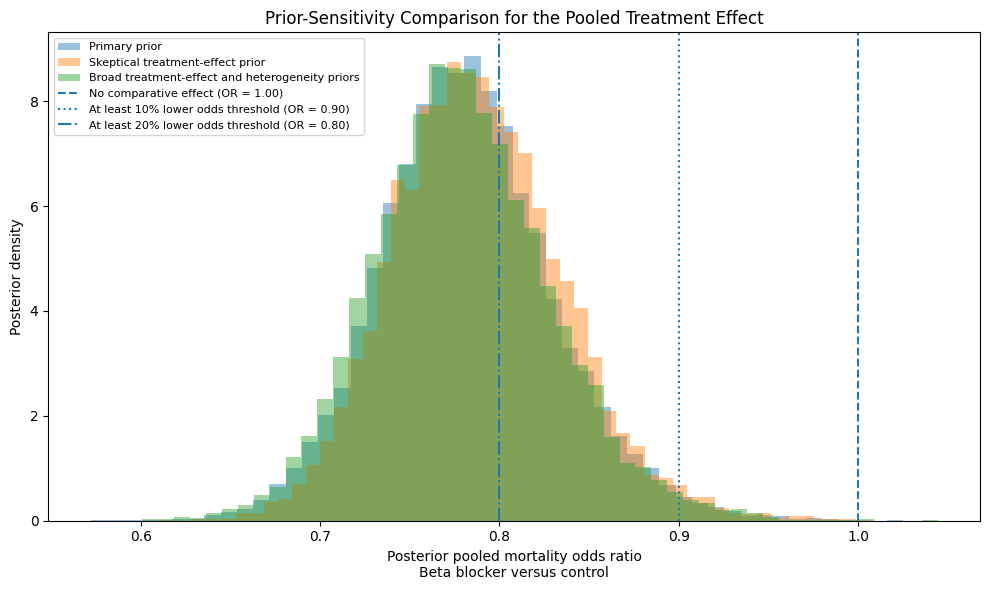

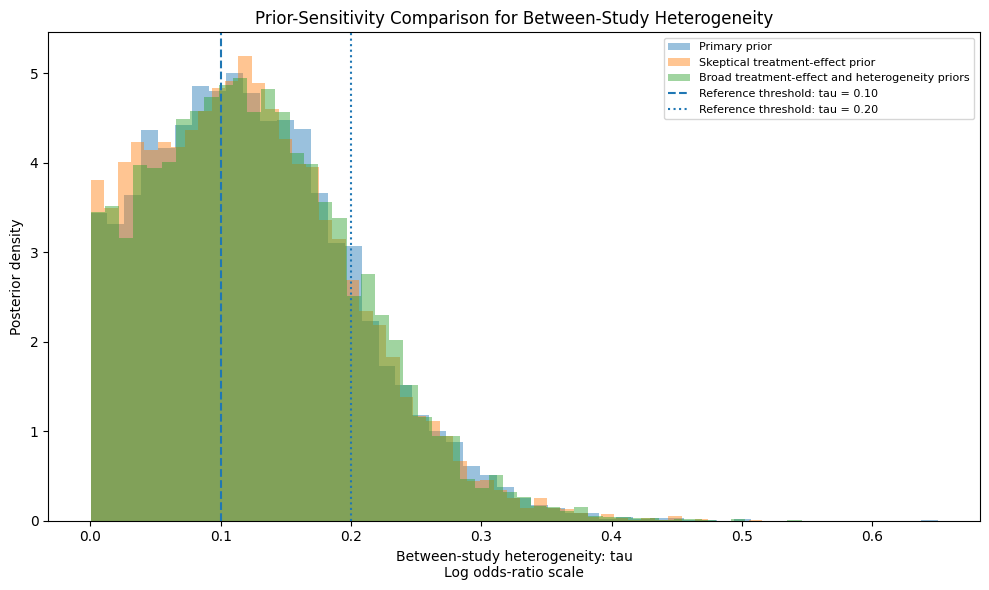


PRIOR-SENSITIVITY ANALYSIS COMPLETED

Prior-sensitivity comparison:
                                       scenario  posterior_pooled_or_mean  posterior_pooled_or_lower_95  posterior_pooled_or_upper_95  probability_pooled_or_below_1  probability_pooled_or_below_0_90  posterior_tau_mean  posterior_tau_lower_95  posterior_tau_upper_95  future_trial_or_lower_95  future_trial_or_upper_95  probability_future_trial_or_below_1  divergences  maximum_r_hat
               Primary weakly informative prior                  0.782036                      0.690347                      0.884438                       0.999917                          0.986417            0.125530                0.008024                0.294903                  0.562109                  1.102438                             0.942583            0       1.002004
               Skeptical treatment-effect prior                  0.788538                      0.701832                      0.890836                       0.99990

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified study-level evidence
# ---------------------------------------------------------
study_level = pd.read_csv(
    DATA_DIR / "blocker_study_level_evidence.csv"
).sort_values("study_id").reset_index(drop=True)

study_ids = (
    study_level["study_id"]
    .astype(int)
    .to_numpy()
)

control_deaths = (
    study_level["control_deaths"]
    .astype(int)
    .to_numpy()
)

control_n = (
    study_level["control_participants"]
    .astype(int)
    .to_numpy()
)

beta_deaths = (
    study_level["beta_blocker_deaths"]
    .astype(int)
    .to_numpy()
)

beta_n = (
    study_level["beta_blocker_participants"]
    .astype(int)
    .to_numpy()
)

# ---------------------------------------------------------
# Reload primary posterior object if needed
# ---------------------------------------------------------
primary_posterior_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_primary_posterior.nc"
)

if "random_effects_idata" not in globals():
    random_effects_idata = az.from_netcdf(
        primary_posterior_file
    )

# ---------------------------------------------------------
# Shared scale-aware baseline-risk prior
# ---------------------------------------------------------
baseline_probability_center = 0.10

baseline_logit_mean = np.log(
    baseline_probability_center
    / (1 - baseline_probability_center)
)

baseline_logit_sigma = 0.75

coords = {
    "study": study_ids,
}

# ---------------------------------------------------------
# Reusable model-fitting function
# ---------------------------------------------------------
def fit_random_effects_sensitivity_model(
    scenario_name,
    mu_sigma,
    tau_sigma,
    random_seed,
    output_filename,
):
    """
    Fit a Bayesian hierarchical random-effects meta-analysis
    using alternative treatment-effect and heterogeneity priors.
    """

    with pm.Model(coords=coords) as model:

        alpha_study = pm.Normal(
            "alpha_study",
            mu=baseline_logit_mean,
            sigma=baseline_logit_sigma,
            dims="study",
        )

        mu = pm.Normal(
            "mu",
            mu=0.0,
            sigma=mu_sigma,
        )

        tau = pm.HalfNormal(
            "tau",
            sigma=tau_sigma,
        )

        z_study = pm.Normal(
            "z_study",
            mu=0.0,
            sigma=1.0,
            dims="study",
        )

        delta_study = pm.Deterministic(
            "delta_study",
            mu + tau * z_study,
            dims="study",
        )

        pooled_odds_ratio = pm.Deterministic(
            "pooled_odds_ratio",
            pm.math.exp(mu),
        )

        study_odds_ratio = pm.Deterministic(
            "study_odds_ratio",
            pm.math.exp(delta_study),
            dims="study",
        )

        p_control = pm.Deterministic(
            "p_control",
            pm.math.sigmoid(alpha_study),
            dims="study",
        )

        p_beta_blocker = pm.Deterministic(
            "p_beta_blocker",
            pm.math.sigmoid(alpha_study + delta_study),
            dims="study",
        )

        control_deaths_obs = pm.Binomial(
            "control_deaths_obs",
            n=control_n,
            p=p_control,
            observed=control_deaths,
            dims="study",
        )

        beta_deaths_obs = pm.Binomial(
            "beta_deaths_obs",
            n=beta_n,
            p=p_beta_blocker,
            observed=beta_deaths,
            dims="study",
        )

        idata = pm.sample(
            draws=2500,
            tune=2500,
            chains=4,
            cores=2,
            target_accept=0.98,
            random_seed=random_seed,
            return_inferencedata=True,
            idata_kwargs={
                "log_likelihood": True,
            },
        )

    posterior_file = (
        DIAGNOSTIC_DIR / output_filename
    )

    az.to_netcdf(
        idata,
        posterior_file,
    )

    return idata, posterior_file

# ---------------------------------------------------------
# Fit skeptical sensitivity model
# ---------------------------------------------------------
print("FITTING SKEPTICAL SENSITIVITY MODEL")
print("=" * 96)

skeptical_idata, skeptical_posterior_file = (
    fit_random_effects_sensitivity_model(
        scenario_name="Skeptical sensitivity prior",
        mu_sigma=0.25,
        tau_sigma=0.5,
        random_seed=20260731,
        output_filename=(
            "bayesian_random_effects_skeptical_sensitivity_posterior.nc"
        ),
    )
)

# ---------------------------------------------------------
# Fit broad sensitivity model
# ---------------------------------------------------------
print("\nFITTING BROAD SENSITIVITY MODEL")
print("=" * 96)

broad_idata, broad_posterior_file = (
    fit_random_effects_sensitivity_model(
        scenario_name="Broad sensitivity prior",
        mu_sigma=1.0,
        tau_sigma=1.0,
        random_seed=20260801,
        output_filename=(
            "bayesian_random_effects_broad_sensitivity_posterior.nc"
        ),
    )
)

# ---------------------------------------------------------
# Summarize each sensitivity scenario
# ---------------------------------------------------------
def summarize_sensitivity_scenario(
    scenario,
    idata,
    mu_prior,
    tau_prior,
    rng_seed,
):
    mu_draws = (
        idata.posterior["mu"]
        .values
        .reshape(-1)
    )

    tau_draws = (
        idata.posterior["tau"]
        .values
        .reshape(-1)
    )

    pooled_or_draws = np.exp(
        mu_draws
    )

    rng = np.random.default_rng(
        rng_seed
    )

    future_log_or_draws = (
        mu_draws
        + tau_draws
        * rng.normal(
            size=len(mu_draws)
        )
    )

    future_or_draws = np.exp(
        future_log_or_draws
    )

    parameter_diagnostics = az.summary(
        idata,
        var_names=[
            "alpha_study",
            "mu",
            "tau",
            "z_study",
        ],
        hdi_prob=0.95,
        round_to=6,
    ).reset_index().rename(
        columns={
            "index": "parameter",
        }
    )

    divergences = int(
        idata.sample_stats["diverging"]
        .values
        .sum()
    )

    summary_row = {
        "scenario": scenario,
        "mu_prior": mu_prior,
        "tau_prior": tau_prior,
        "posterior_pooled_or_mean": np.mean(
            pooled_or_draws
        ),
        "posterior_pooled_or_median": np.median(
            pooled_or_draws
        ),
        "posterior_pooled_or_lower_95": np.quantile(
            pooled_or_draws,
            0.025,
        ),
        "posterior_pooled_or_upper_95": np.quantile(
            pooled_or_draws,
            0.975,
        ),
        "probability_pooled_or_below_1": np.mean(
            pooled_or_draws < 1.0
        ),
        "probability_pooled_or_below_0_90": np.mean(
            pooled_or_draws < 0.90
        ),
        "probability_pooled_or_below_0_80": np.mean(
            pooled_or_draws < 0.80
        ),
        "posterior_tau_mean": np.mean(
            tau_draws
        ),
        "posterior_tau_median": np.median(
            tau_draws
        ),
        "posterior_tau_lower_95": np.quantile(
            tau_draws,
            0.025,
        ),
        "posterior_tau_upper_95": np.quantile(
            tau_draws,
            0.975,
        ),
        "probability_tau_above_0_10": np.mean(
            tau_draws > 0.10
        ),
        "probability_tau_above_0_20": np.mean(
            tau_draws > 0.20
        ),
        "future_trial_or_mean": np.mean(
            future_or_draws
        ),
        "future_trial_or_median": np.median(
            future_or_draws
        ),
        "future_trial_or_lower_95": np.quantile(
            future_or_draws,
            0.025,
        ),
        "future_trial_or_upper_95": np.quantile(
            future_or_draws,
            0.975,
        ),
        "probability_future_trial_or_below_1": np.mean(
            future_or_draws < 1.0
        ),
        "divergences": divergences,
        "maximum_r_hat": float(
            parameter_diagnostics["r_hat"]
            .max()
        ),
        "minimum_ess_bulk": float(
            parameter_diagnostics["ess_bulk"]
            .min()
        ),
        "minimum_ess_tail": float(
            parameter_diagnostics["ess_tail"]
            .min()
        ),
    }

    return {
        "summary_row": summary_row,
        "mu_draws": mu_draws,
        "tau_draws": tau_draws,
        "pooled_or_draws": pooled_or_draws,
        "future_or_draws": future_or_draws,
        "parameter_diagnostics": parameter_diagnostics,
    }

primary_results = summarize_sensitivity_scenario(
    scenario="Primary weakly informative prior",
    idata=random_effects_idata,
    mu_prior="Normal(0, 0.5)",
    tau_prior="HalfNormal(0.5)",
    rng_seed=20260727,
)

skeptical_results = summarize_sensitivity_scenario(
    scenario="Skeptical treatment-effect prior",
    idata=skeptical_idata,
    mu_prior="Normal(0, 0.25)",
    tau_prior="HalfNormal(0.5)",
    rng_seed=20260731,
)

broad_results = summarize_sensitivity_scenario(
    scenario="Broad treatment-effect and heterogeneity priors",
    idata=broad_idata,
    mu_prior="Normal(0, 1.0)",
    tau_prior="HalfNormal(1.0)",
    rng_seed=20260801,
)

# ---------------------------------------------------------
# Create comparison table
# ---------------------------------------------------------
sensitivity_comparison = pd.DataFrame(
    [
        primary_results["summary_row"],
        skeptical_results["summary_row"],
        broad_results["summary_row"],
    ]
)

comparison_file = (
    TABLE_DIR
    / "bayesian_random_effects_prior_sensitivity_comparison.csv"
)

sensitivity_comparison.to_csv(
    comparison_file,
    index=False,
)

# ---------------------------------------------------------
# Save detailed diagnostics for alternative scenarios
# ---------------------------------------------------------
skeptical_diagnostics_file = (
    TABLE_DIR
    / "bayesian_random_effects_skeptical_all_parameter_diagnostics.csv"
)

broad_diagnostics_file = (
    TABLE_DIR
    / "bayesian_random_effects_broad_all_parameter_diagnostics.csv"
)

skeptical_results[
    "parameter_diagnostics"
].to_csv(
    skeptical_diagnostics_file,
    index=False,
)

broad_results[
    "parameter_diagnostics"
].to_csv(
    broad_diagnostics_file,
    index=False,
)

# ---------------------------------------------------------
# Create compact diagnostic audit table
# ---------------------------------------------------------
sensitivity_diagnostic_audit = (
    sensitivity_comparison[
        [
            "scenario",
            "divergences",
            "maximum_r_hat",
            "minimum_ess_bulk",
            "minimum_ess_tail",
        ]
    ]
    .copy()
)

diagnostic_audit_file = (
    TABLE_DIR
    / "bayesian_random_effects_prior_sensitivity_diagnostic_audit.csv"
)

sensitivity_diagnostic_audit.to_csv(
    diagnostic_audit_file,
    index=False,
)

# ---------------------------------------------------------
# Figure 1: pooled OR posterior sensitivity comparison
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    primary_results["pooled_or_draws"],
    bins=50,
    density=True,
    alpha=0.45,
    label="Primary prior",
)

ax.hist(
    skeptical_results["pooled_or_draws"],
    bins=50,
    density=True,
    alpha=0.45,
    label="Skeptical treatment-effect prior",
)

ax.hist(
    broad_results["pooled_or_draws"],
    bins=50,
    density=True,
    alpha=0.45,
    label="Broad treatment-effect and heterogeneity priors",
)

ax.axvline(
    1.00,
    linestyle="--",
    linewidth=1.5,
    label="No comparative effect (OR = 1.00)",
)

ax.axvline(
    0.90,
    linestyle=":",
    linewidth=1.5,
    label="At least 10% lower odds threshold (OR = 0.90)",
)

ax.axvline(
    0.80,
    linestyle="-.",
    linewidth=1.5,
    label="At least 20% lower odds threshold (OR = 0.80)",
)

ax.set_xlabel(
    "Posterior pooled mortality odds ratio\n"
    "Beta blocker versus control"
)

ax.set_ylabel(
    "Posterior density"
)

ax.set_title(
    "Prior-Sensitivity Comparison for the Pooled Treatment Effect"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

pooled_or_figure_file = (
    FIGURE_DIR
    / "16_bayesian_random_effects_prior_sensitivity_pooled_or.png"
)

fig.savefig(
    pooled_or_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Figure 2: tau posterior sensitivity comparison
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    primary_results["tau_draws"],
    bins=50,
    density=True,
    alpha=0.45,
    label="Primary prior",
)

ax.hist(
    skeptical_results["tau_draws"],
    bins=50,
    density=True,
    alpha=0.45,
    label="Skeptical treatment-effect prior",
)

ax.hist(
    broad_results["tau_draws"],
    bins=50,
    density=True,
    alpha=0.45,
    label="Broad treatment-effect and heterogeneity priors",
)

ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1.5,
    label="Reference threshold: tau = 0.10",
)

ax.axvline(
    0.20,
    linestyle=":",
    linewidth=1.5,
    label="Reference threshold: tau = 0.20",
)

ax.set_xlabel(
    "Between-study heterogeneity: tau\n"
    "Log odds-ratio scale"
)

ax.set_ylabel(
    "Posterior density"
)

ax.set_title(
    "Prior-Sensitivity Comparison for Between-Study Heterogeneity"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

tau_figure_file = (
    FIGURE_DIR
    / "17_bayesian_random_effects_prior_sensitivity_tau.png"
)

fig.savefig(
    tau_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("\nPRIOR-SENSITIVITY ANALYSIS COMPLETED")
print("=" * 110)

display_columns = [
    "scenario",
    "posterior_pooled_or_mean",
    "posterior_pooled_or_lower_95",
    "posterior_pooled_or_upper_95",
    "probability_pooled_or_below_1",
    "probability_pooled_or_below_0_90",
    "posterior_tau_mean",
    "posterior_tau_lower_95",
    "posterior_tau_upper_95",
    "future_trial_or_lower_95",
    "future_trial_or_upper_95",
    "probability_future_trial_or_below_1",
    "divergences",
    "maximum_r_hat",
]

print("\nPrior-sensitivity comparison:")
print(
    sensitivity_comparison[
        display_columns
    ]
    .round(6)
    .to_string(index=False)
)

print("\nCompact convergence audit:")
print(
    sensitivity_diagnostic_audit
    .round(6)
    .to_string(index=False)
)

print("\nSaved sensitivity-model posterior objects:")
print(primary_posterior_file)
print(skeptical_posterior_file)
print(broad_posterior_file)

print("\nSaved figures:")
print(pooled_or_figure_file)
print(tau_figure_file)

print("\nSaved repository tables:")
print(comparison_file)
print(diagnostic_audit_file)
print(skeptical_diagnostics_file)
print(broad_diagnostics_file)

## 8. Prior-versus-Posterior Updating

The primary prior and posterior distributions are compared to show how the included trial evidence updates uncertainty.

Two quantities are examined:

1. **Pooled mortality odds ratio**
   The prior is centered close to no comparative effect and allows benefit or harm. The posterior shows how the observed trial evidence shifts and narrows the pooled comparative-effect distribution.

2. **Between-study heterogeneity**
   The heterogeneity prior allows a broad range of values before observing the data. The posterior indicates which heterogeneity values remain most plausible after synthesizing the included trials.

This comparison makes the role of the observed evidence visible and supports transparent interpretation of Bayesian updating.


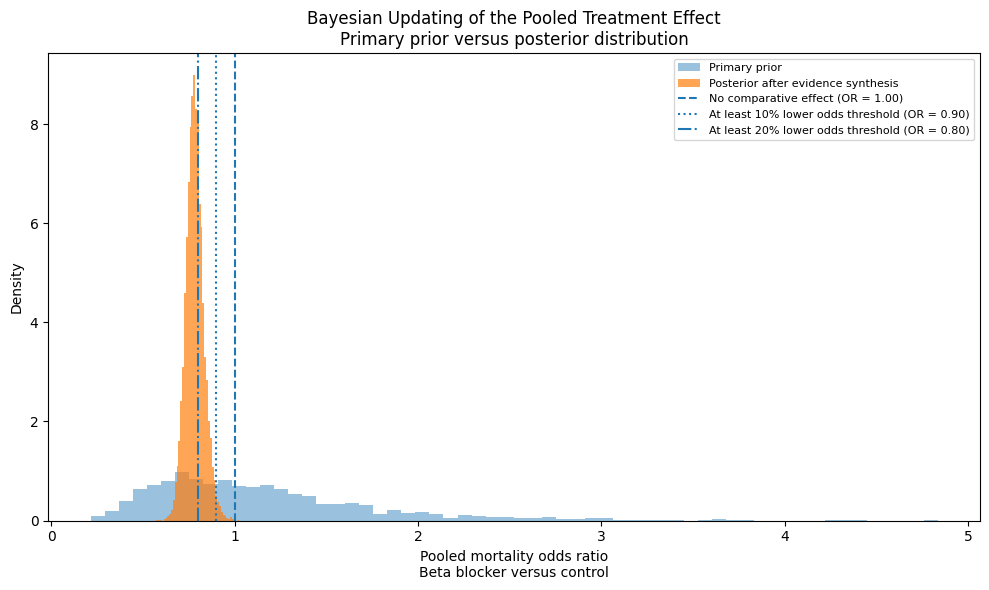

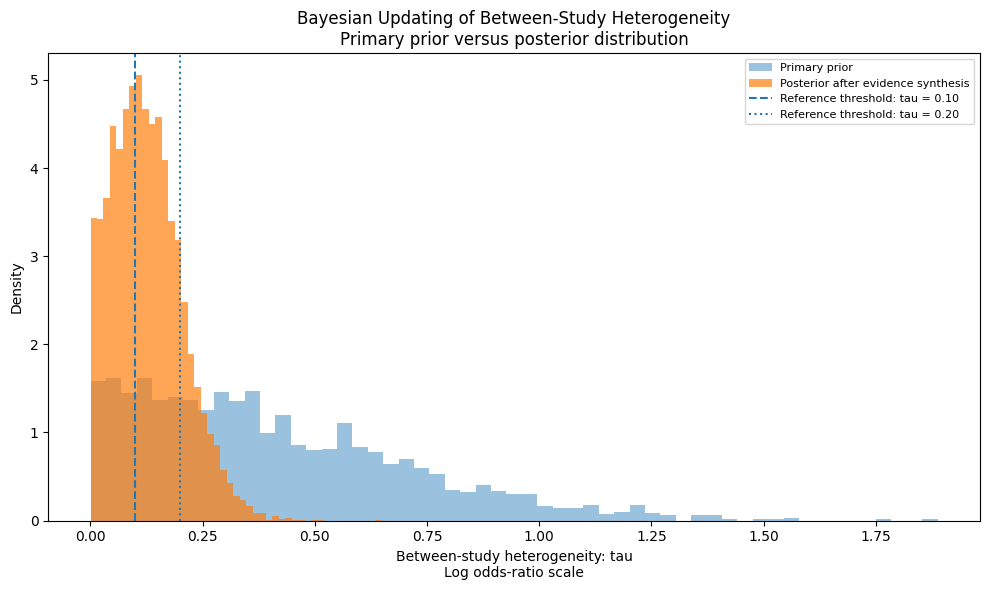

PRIOR-VERSUS-POSTERIOR COMPARISON COMPLETED

Prior-versus-posterior summary:
distribution_type                         quantity     mean   median  lower_2_5_pct  upper_97_5_pct  minimum  maximum
            Prior                Pooled odds ratio 1.143076 1.015273       0.378160        2.732148 0.212928 4.833788
        Posterior                Pooled odds ratio 0.782036 0.780254       0.690347        0.884438 0.572011 1.025037
            Prior Between-study heterogeneity: tau 0.406218 0.345269       0.016004        1.129956 0.000120 1.888005
        Posterior Between-study heterogeneity: tau 0.125530 0.118175       0.008024        0.294903 0.000039 0.650389

Saved figures:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/18_bayesian_random_effects_prior_vs_posterior_pooled_or.png
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/outputs/figures/19_bayesian_random_effects_prior_vs_posterior_tau.png

Saved 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Reload saved primary prior and posterior objects if needed
# ---------------------------------------------------------
prior_predictive_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_primary_prior_predictive.nc"
)

posterior_file = (
    DIAGNOSTIC_DIR
    / "bayesian_random_effects_primary_posterior.nc"
)

if "random_effects_prior_predictive" not in globals():
    random_effects_prior_predictive = az.from_netcdf(
        prior_predictive_file
    )

if "random_effects_idata" not in globals():
    random_effects_idata = az.from_netcdf(
        posterior_file
    )

# ---------------------------------------------------------
# Extract prior and posterior draws
# ---------------------------------------------------------
prior_mu_draws = (
    random_effects_prior_predictive.prior["mu"]
    .values
    .reshape(-1)
)

prior_tau_draws = (
    random_effects_prior_predictive.prior["tau"]
    .values
    .reshape(-1)
)

posterior_mu_draws = (
    random_effects_idata.posterior["mu"]
    .values
    .reshape(-1)
)

posterior_tau_draws = (
    random_effects_idata.posterior["tau"]
    .values
    .reshape(-1)
)

prior_or_draws = np.exp(
    prior_mu_draws
)

posterior_or_draws = np.exp(
    posterior_mu_draws
)

# ---------------------------------------------------------
# Helper function for transparent summary tables
# ---------------------------------------------------------
def summarize_distribution(
    distribution_type,
    quantity,
    values,
):
    return {
        "distribution_type": distribution_type,
        "quantity": quantity,
        "mean": np.mean(values),
        "median": np.median(values),
        "lower_2_5_pct": np.quantile(
            values,
            0.025,
        ),
        "upper_97_5_pct": np.quantile(
            values,
            0.975,
        ),
        "minimum": np.min(values),
        "maximum": np.max(values),
    }

# ---------------------------------------------------------
# Save repository-ready comparison table
# ---------------------------------------------------------
prior_posterior_summary = pd.DataFrame(
    [
        summarize_distribution(
            "Prior",
            "Pooled odds ratio",
            prior_or_draws,
        ),
        summarize_distribution(
            "Posterior",
            "Pooled odds ratio",
            posterior_or_draws,
        ),
        summarize_distribution(
            "Prior",
            "Between-study heterogeneity: tau",
            prior_tau_draws,
        ),
        summarize_distribution(
            "Posterior",
            "Between-study heterogeneity: tau",
            posterior_tau_draws,
        ),
    ]
)

summary_file = (
    TABLE_DIR
    / "bayesian_random_effects_prior_vs_posterior_summary.csv"
)

prior_posterior_summary.to_csv(
    summary_file,
    index=False,
)

# ---------------------------------------------------------
# Figure 1: pooled odds-ratio prior versus posterior
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    prior_or_draws,
    bins=60,
    density=True,
    alpha=0.45,
    label="Primary prior",
)

ax.hist(
    posterior_or_draws,
    bins=45,
    density=True,
    alpha=0.70,
    label="Posterior after evidence synthesis",
)

ax.axvline(
    1.00,
    linestyle="--",
    linewidth=1.5,
    label="No comparative effect (OR = 1.00)",
)

ax.axvline(
    0.90,
    linestyle=":",
    linewidth=1.5,
    label="At least 10% lower odds threshold (OR = 0.90)",
)

ax.axvline(
    0.80,
    linestyle="-.",
    linewidth=1.5,
    label="At least 20% lower odds threshold (OR = 0.80)",
)

ax.set_xlabel(
    "Pooled mortality odds ratio\n"
    "Beta blocker versus control"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Bayesian Updating of the Pooled Treatment Effect\n"
    "Primary prior versus posterior distribution"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

or_figure_file = (
    FIGURE_DIR
    / "18_bayesian_random_effects_prior_vs_posterior_pooled_or.png"
)

fig.savefig(
    or_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Figure 2: heterogeneity prior versus posterior
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    prior_tau_draws,
    bins=55,
    density=True,
    alpha=0.45,
    label="Primary prior",
)

ax.hist(
    posterior_tau_draws,
    bins=45,
    density=True,
    alpha=0.70,
    label="Posterior after evidence synthesis",
)

ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1.5,
    label="Reference threshold: tau = 0.10",
)

ax.axvline(
    0.20,
    linestyle=":",
    linewidth=1.5,
    label="Reference threshold: tau = 0.20",
)

ax.set_xlabel(
    "Between-study heterogeneity: tau\n"
    "Log odds-ratio scale"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Bayesian Updating of Between-Study Heterogeneity\n"
    "Primary prior versus posterior distribution"
)

ax.legend(
    fontsize=8,
)

fig.tight_layout()

tau_figure_file = (
    FIGURE_DIR
    / "19_bayesian_random_effects_prior_vs_posterior_tau.png"
)

fig.savefig(
    tau_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("PRIOR-VERSUS-POSTERIOR COMPARISON COMPLETED")
print("=" * 96)

print("\nPrior-versus-posterior summary:")
print(
    prior_posterior_summary
    .round(6)
    .to_string(index=False)
)

print("\nSaved figures:")
print(or_figure_file)
print(tau_figure_file)

print("\nSaved repository table:")
print(summary_file)

## 9. Transparent Model Comparison and Primary-Model Selection

The conventional and Bayesian models are compared to assess whether the substantive treatment-effect conclusion changes materially under different assumptions.

The models are not treated as competitors with a single automatic winner.

The fixed-effect models assume one common underlying treatment effect across the included trials.

The hierarchical random-effects models allow trial-specific effects to vary around an overall pooled effect. This structure also supports partial pooling, explicit heterogeneity estimation, and prediction for a future comparable trial.

The hierarchical Bayesian random-effects model is retained as the primary interpretation model because it makes between-study variation, posterior uncertainty, future-trial uncertainty, and prior sensitivity visible while remaining consistent with the simpler benchmark analyses.


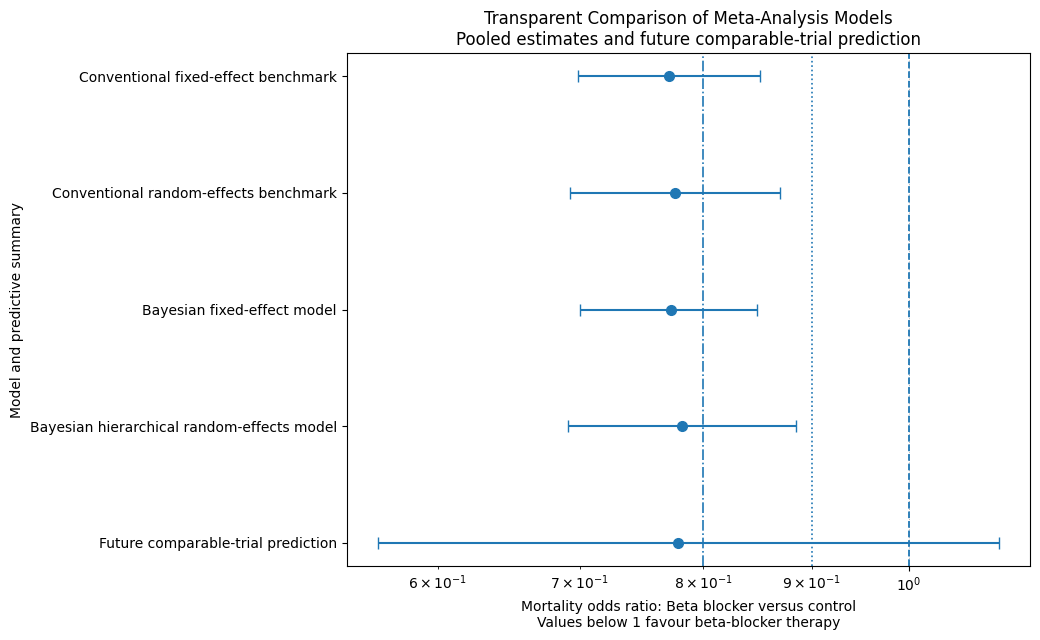

TRANSPARENT MODEL COMPARISON COMPLETED

Model-comparison summary:
                                     model  odds_ratio_estimate  interval_lower_95  interval_upper_95  heterogeneity_tau                       role_in_project
       Conventional fixed-effect benchmark             0.771110           0.698700           0.851024            0.00000                  Contextual benchmark
     Conventional random-effects benchmark             0.775977           0.692659           0.869318            0.07234                  Contextual benchmark
               Bayesian fixed-effect model             0.772498           0.699814           0.847703            0.00000              Bayesian reference model
Bayesian hierarchical random-effects model             0.782036           0.690953           0.884732            0.12553          Primary interpretation model
        Future comparable-trial prediction             0.778551           0.562109           1.102438            0.12553 Decision-oriented 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load saved model summaries
# ---------------------------------------------------------
conventional_summary = pd.read_csv(
    TABLE_DIR / "conventional_benchmark_summary.csv"
)

bayesian_fixed_summary = pd.read_csv(
    TABLE_DIR / "bayesian_fixed_effect_summary.csv"
)

bayesian_random_summary = pd.read_csv(
    TABLE_DIR / "bayesian_random_effects_primary_summary.csv"
)

future_trial_summary = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_future_trial_prediction_summary.csv"
)

fixed_convergence = pd.read_csv(
    TABLE_DIR
    / "bayesian_fixed_effect_convergence_summary.csv"
)

random_convergence = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_primary_convergence_summary.csv"
)

sensitivity_comparison = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_prior_sensitivity_comparison.csv"
)

# ---------------------------------------------------------
# Extract conventional benchmarks
# ---------------------------------------------------------
conventional_fixed = conventional_summary.loc[
    conventional_summary["model"]
    == "Fixed-effect inverse-variance benchmark"
].iloc[0]

conventional_random = conventional_summary.loc[
    conventional_summary["model"]
    == "Random-effects benchmark"
].iloc[0]

# ---------------------------------------------------------
# Extract Bayesian summaries
# ---------------------------------------------------------
bayesian_fixed_or = bayesian_fixed_summary.loc[
    bayesian_fixed_summary["parameter"]
    == "pooled_odds_ratio"
].iloc[0]

bayesian_random_or = bayesian_random_summary.loc[
    bayesian_random_summary["parameter"]
    == "pooled_odds_ratio"
].iloc[0]

bayesian_random_tau = bayesian_random_summary.loc[
    bayesian_random_summary["parameter"]
    == "tau"
].iloc[0]

future_trial = future_trial_summary.iloc[0]

# ---------------------------------------------------------
# Create transparent model-comparison table
# ---------------------------------------------------------
model_comparison = pd.DataFrame(
    [
        {
            "model": "Conventional fixed-effect benchmark",
            "model_family": "Frequentist",
            "core_assumption": (
                "One common underlying treatment effect "
                "across included trials"
            ),
            "odds_ratio_estimate": (
                conventional_fixed["pooled_odds_ratio"]
            ),
            "interval_lower_95": (
                conventional_fixed["or_ci_lower_95"]
            ),
            "interval_upper_95": (
                conventional_fixed["or_ci_upper_95"]
            ),
            "interval_type": "95% confidence interval",
            "heterogeneity_tau": 0.0,
            "future_trial_prediction_available": False,
            "role_in_project": "Contextual benchmark",
        },
        {
            "model": "Conventional random-effects benchmark",
            "model_family": "Frequentist",
            "core_assumption": (
                "Treatment effects may vary across trials"
            ),
            "odds_ratio_estimate": (
                conventional_random["pooled_odds_ratio"]
            ),
            "interval_lower_95": (
                conventional_random["or_ci_lower_95"]
            ),
            "interval_upper_95": (
                conventional_random["or_ci_upper_95"]
            ),
            "interval_type": (
                "95% modified Hartung-Knapp confidence interval"
            ),
            "heterogeneity_tau": np.sqrt(
                conventional_random["tau_squared"]
            ),
            "future_trial_prediction_available": True,
            "role_in_project": "Contextual benchmark",
        },
        {
            "model": "Bayesian fixed-effect model",
            "model_family": "Bayesian",
            "core_assumption": (
                "One common underlying treatment effect "
                "across included trials"
            ),
            "odds_ratio_estimate": (
                bayesian_fixed_or["mean"]
            ),
            "interval_lower_95": (
                bayesian_fixed_or["hdi_2.5%"]
            ),
            "interval_upper_95": (
                bayesian_fixed_or["hdi_97.5%"]
            ),
            "interval_type": "95% posterior HDI",
            "heterogeneity_tau": 0.0,
            "future_trial_prediction_available": False,
            "role_in_project": "Bayesian reference model",
        },
        {
            "model": "Bayesian hierarchical random-effects model",
            "model_family": "Bayesian",
            "core_assumption": (
                "Trial-specific treatment effects vary around "
                "an overall pooled effect"
            ),
            "odds_ratio_estimate": (
                bayesian_random_or["mean"]
            ),
            "interval_lower_95": (
                bayesian_random_or["hdi_2.5%"]
            ),
            "interval_upper_95": (
                bayesian_random_or["hdi_97.5%"]
            ),
            "interval_type": "95% posterior HDI",
            "heterogeneity_tau": (
                bayesian_random_tau["mean"]
            ),
            "future_trial_prediction_available": True,
            "role_in_project": "Primary interpretation model",
        },
        {
            "model": "Future comparable-trial prediction",
            "model_family": "Bayesian predictive distribution",
            "core_assumption": (
                "Prediction incorporates pooled-effect uncertainty "
                "and between-study heterogeneity"
            ),
            "odds_ratio_estimate": (
                future_trial["posterior_predictive_median"]
            ),
            "interval_lower_95": (
                future_trial["posterior_predictive_lower_95"]
            ),
            "interval_upper_95": (
                future_trial["posterior_predictive_upper_95"]
            ),
            "interval_type": "95% posterior predictive interval",
            "heterogeneity_tau": (
                bayesian_random_tau["mean"]
            ),
            "future_trial_prediction_available": True,
            "role_in_project": (
                "Decision-oriented uncertainty summary"
            ),
        },
    ]
)

comparison_file = (
    TABLE_DIR / "transparent_model_comparison_summary.csv"
)

model_comparison.to_csv(
    comparison_file,
    index=False,
)

# ---------------------------------------------------------
# Create explicit reasoning table
# ---------------------------------------------------------
model_selection_reasoning = pd.DataFrame(
    [
        {
            "criterion": "Pooled treatment-effect stability",
            "finding": (
                "Pooled odds-ratio estimates remain close to 0.78 "
                "across conventional and Bayesian models"
            ),
            "implication": (
                "The direction of the pooled conclusion is not "
                "driven by one modeling framework"
            ),
        },
        {
            "criterion": "Between-study variation",
            "finding": (
                "The hierarchical model estimates tau explicitly "
                "and supports trial-specific partial pooling"
            ),
            "implication": (
                "Random-effects modeling is preferred for cautious "
                "interpretation even when heterogeneity is modest"
            ),
        },
        {
            "criterion": "Future-trial uncertainty",
            "finding": (
                "The future comparable-trial predictive interval "
                "crosses an odds ratio of 1"
            ),
            "implication": (
                "Average pooled benefit should not be interpreted "
                "as a guarantee for every future comparable study"
            ),
        },
        {
            "criterion": "Prior sensitivity",
            "finding": (
                "Primary, skeptical, and broader prior scenarios "
                "produce closely aligned pooled estimates"
            ),
            "implication": (
                "The substantive pooled conclusion is stable under "
                "reasonable alternative prior assumptions"
            ),
        },
        {
            "criterion": "Sampling diagnostics",
            "finding": (
                "The primary hierarchical model has zero divergences, "
                "R-hat values close to 1, and strong effective sample sizes"
            ),
            "implication": (
                "No immediate sampling correction is required"
            ),
        },
    ]
)

reasoning_file = (
    TABLE_DIR / "primary_model_selection_reasoning.csv"
)

model_selection_reasoning.to_csv(
    reasoning_file,
    index=False,
)

# ---------------------------------------------------------
# Create compact model-comparison figure
# ---------------------------------------------------------
plot_data = model_comparison.copy()

plot_data = plot_data.iloc[
    [0, 1, 2, 3, 4]
].reset_index(drop=True)

y_positions = np.arange(
    len(plot_data),
    0,
    -1,
)

estimates = plot_data[
    "odds_ratio_estimate"
].to_numpy(dtype=float)

lower = plot_data[
    "interval_lower_95"
].to_numpy(dtype=float)

upper = plot_data[
    "interval_upper_95"
].to_numpy(dtype=float)

x_errors = np.vstack(
    [
        estimates - lower,
        upper - estimates,
    ]
)

fig, ax = plt.subplots(
    figsize=(10.5, 6.5)
)

ax.errorbar(
    estimates,
    y_positions,
    xerr=x_errors,
    fmt="o",
    capsize=4,
    linewidth=1.5,
    markersize=7,
)

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.3,
)

ax.axvline(
    0.90,
    linestyle=":",
    linewidth=1.2,
)

ax.axvline(
    0.80,
    linestyle="-.",
    linewidth=1.2,
)

ax.set_xscale(
    "log"
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    plot_data["model"]
)

ax.set_xlabel(
    "Mortality odds ratio: Beta blocker versus control\n"
    "Values below 1 favour beta-blocker therapy"
)

ax.set_ylabel(
    "Model and predictive summary"
)

ax.set_title(
    "Transparent Comparison of Meta-Analysis Models\n"
    "Pooled estimates and future comparable-trial prediction"
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
)

fig.tight_layout()

figure_file = (
    FIGURE_DIR
    / "20_transparent_model_comparison.png"
)

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("TRANSPARENT MODEL COMPARISON COMPLETED")
print("=" * 104)

print("\nModel-comparison summary:")
print(
    model_comparison[
        [
            "model",
            "odds_ratio_estimate",
            "interval_lower_95",
            "interval_upper_95",
            "heterogeneity_tau",
            "role_in_project",
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print("\nPrimary model-selection reasoning:")
print(
    model_selection_reasoning
    .to_string(index=False)
)

print("\nPrimary hierarchical-model convergence check:")
print(
    random_convergence
    .round(6)
    .to_string(index=False)
)

print("\nSensitivity scenarios reviewed:")
print(
    sensitivity_comparison[
        [
            "scenario",
            "posterior_pooled_or_mean",
            "posterior_tau_mean",
            "probability_future_trial_or_below_1",
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print("\nSaved figure:")
print(figure_file)

print("\nSaved repository tables:")
print(comparison_file)
print(reasoning_file)

## 10. Final Analytical Summary and Repository Audit

The verified analytical outputs are consolidated into repository-ready summary tables.

The final summaries distinguish carefully between:

* descriptive arm-level mortality patterns;
* conventional benchmark estimates;
* Bayesian fixed-effect results;
* hierarchical random-effects results;
* heterogeneity;
* future-trial prediction;
* convergence diagnostics;
* prior sensitivity;
* and interpretation boundaries.

A repository audit is also generated to verify that the required analytical figures, tables, and diagnostic objects have been created successfully before the GitHub packaging stage.


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DIAGNOSTIC_DIR = PROJECT_ROOT / "outputs" / "diagnostics"

for folder in [
    DATA_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Load verified outputs
# ---------------------------------------------------------
arm_summary = pd.read_csv(
    TABLE_DIR / "raw_treatment_arm_summary.csv"
)

conventional_summary = pd.read_csv(
    TABLE_DIR / "conventional_benchmark_summary.csv"
)

conventional_heterogeneity = pd.read_csv(
    TABLE_DIR / "conventional_heterogeneity_summary.csv"
)

bayesian_fixed_summary = pd.read_csv(
    TABLE_DIR / "bayesian_fixed_effect_summary.csv"
)

bayesian_fixed_probabilities = pd.read_csv(
    TABLE_DIR
    / "bayesian_fixed_effect_posterior_probability_summary.csv"
)

bayesian_fixed_convergence = pd.read_csv(
    TABLE_DIR
    / "bayesian_fixed_effect_convergence_summary.csv"
)

bayesian_random_summary = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_primary_summary.csv"
)

bayesian_random_probabilities = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_primary_posterior_probability_summary.csv"
)

bayesian_random_convergence = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_primary_convergence_summary.csv"
)

future_trial_summary = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_future_trial_prediction_summary.csv"
)

sensitivity_comparison = pd.read_csv(
    TABLE_DIR
    / "bayesian_random_effects_prior_sensitivity_comparison.csv"
)

model_comparison = pd.read_csv(
    TABLE_DIR
    / "transparent_model_comparison_summary.csv"
)

# ---------------------------------------------------------
# Extract key verified values
# ---------------------------------------------------------
control_row = arm_summary.loc[
    arm_summary["trtc"] == "Control"
].iloc[0]

beta_row = arm_summary.loc[
    arm_summary["trtc"] == "Beta Blocker"
].iloc[0]

conventional_fixed = conventional_summary.loc[
    conventional_summary["model"]
    == "Fixed-effect inverse-variance benchmark"
].iloc[0]

conventional_random = conventional_summary.loc[
    conventional_summary["model"]
    == "Random-effects benchmark"
].iloc[0]

bayesian_fixed_or = bayesian_fixed_summary.loc[
    bayesian_fixed_summary["parameter"]
    == "pooled_odds_ratio"
].iloc[0]

bayesian_random_or = bayesian_random_summary.loc[
    bayesian_random_summary["parameter"]
    == "pooled_odds_ratio"
].iloc[0]

bayesian_random_tau = bayesian_random_summary.loc[
    bayesian_random_summary["parameter"]
    == "tau"
].iloc[0]

future_trial = future_trial_summary.iloc[0]

# ---------------------------------------------------------
# Dataset summary table
# ---------------------------------------------------------
dataset_summary = pd.DataFrame(
    [
        {
            "dataset_name": "blocker",
            "clinical_context": (
                "Mortality outcomes after myocardial infarction"
            ),
            "comparison": "Beta blocker versus control",
            "trials_n": 22,
            "arm_level_records_n": 44,
            "control_participants": int(
                control_row["total_participants"]
            ),
            "control_deaths": int(
                control_row["total_deaths"]
            ),
            "control_descriptive_mortality_pct": float(
                control_row["overall_mortality_pct"]
            ),
            "beta_blocker_participants": int(
                beta_row["total_participants"]
            ),
            "beta_blocker_deaths": int(
                beta_row["total_deaths"]
            ),
            "beta_blocker_descriptive_mortality_pct": float(
                beta_row["overall_mortality_pct"]
            ),
            "zero_cell_trials_n": 0,
            "continuity_correction_required": False,
        }
    ]
)

dataset_summary_file = (
    TABLE_DIR / "dataset_summary.csv"
)

dataset_summary.to_csv(
    dataset_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Combined heterogeneity summary
# ---------------------------------------------------------
heterogeneity_summary = pd.DataFrame(
    [
        {
            "framework": "Conventional random-effects benchmark",
            "heterogeneity_parameter": "tau",
            "estimate": float(
                conventional_heterogeneity[
                    "tau_paule_mandel"
                ].iloc[0]
            ),
            "interval_lower_95": np.nan,
            "interval_upper_95": np.nan,
            "interpretation": (
                "Paule-Mandel heterogeneity estimate on the "
                "log odds-ratio scale"
            ),
        },
        {
            "framework": (
                "Bayesian hierarchical random-effects model"
            ),
            "heterogeneity_parameter": "tau",
            "estimate": float(
                bayesian_random_tau["mean"]
            ),
            "interval_lower_95": float(
                bayesian_random_tau["hdi_2.5%"]
            ),
            "interval_upper_95": float(
                bayesian_random_tau["hdi_97.5%"]
            ),
            "interpretation": (
                "Posterior heterogeneity distribution on the "
                "log odds-ratio scale"
            ),
        },
    ]
)

heterogeneity_summary_file = (
    TABLE_DIR / "heterogeneity_summary.csv"
)

heterogeneity_summary.to_csv(
    heterogeneity_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Combined posterior-probability summary
# ---------------------------------------------------------
fixed_probability_table = (
    bayesian_fixed_probabilities
    .copy()
)

fixed_probability_table.insert(
    0,
    "model",
    "Bayesian fixed-effect model",
)

random_probability_table = (
    bayesian_random_probabilities
    .copy()
)

random_probability_table.insert(
    0,
    "model",
    "Bayesian hierarchical random-effects model",
)

posterior_probability_summary = pd.concat(
    [
        fixed_probability_table,
        random_probability_table,
    ],
    ignore_index=True,
)

posterior_probability_summary_file = (
    TABLE_DIR / "posterior_probability_summary.csv"
)

posterior_probability_summary.to_csv(
    posterior_probability_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Combined convergence-diagnostic summary
# ---------------------------------------------------------
convergence_diagnostic_summary = pd.concat(
    [
        bayesian_fixed_convergence,
        bayesian_random_convergence,
        sensitivity_comparison[
            [
                "scenario",
                "divergences",
                "maximum_r_hat",
                "minimum_ess_bulk",
                "minimum_ess_tail",
            ]
        ]
        .rename(
            columns={
                "scenario": "model",
            }
        ),
    ],
    ignore_index=True,
    sort=False,
)

convergence_diagnostic_summary_file = (
    TABLE_DIR / "convergence_diagnostic_summary.csv"
)

convergence_diagnostic_summary.to_csv(
    convergence_diagnostic_summary_file,
    index=False,
)

# ---------------------------------------------------------
# Machine-readable project summary
# ---------------------------------------------------------
project_summary = pd.DataFrame(
    [
        {
            "project_title": (
                "Bayesian Evidence Synthesis for Comparative "
                "Treatment Effectiveness Using Python"
            ),
            "dataset": "blocker",
            "comparison": "Beta blocker versus control",
            "outcome": "Mortality after myocardial infarction",
            "primary_model": (
                "Bayesian hierarchical random-effects meta-analysis"
            ),
            "trials_n": 22,
            "control_descriptive_mortality_pct": float(
                control_row["overall_mortality_pct"]
            ),
            "beta_blocker_descriptive_mortality_pct": float(
                beta_row["overall_mortality_pct"]
            ),
            "conventional_fixed_effect_or": float(
                conventional_fixed["pooled_odds_ratio"]
            ),
            "conventional_random_effects_or": float(
                conventional_random["pooled_odds_ratio"]
            ),
            "bayesian_fixed_effect_or_mean": float(
                bayesian_fixed_or["mean"]
            ),
            "bayesian_random_effects_or_mean": float(
                bayesian_random_or["mean"]
            ),
            "bayesian_random_effects_or_hdi_lower_95": float(
                bayesian_random_or["hdi_2.5%"]
            ),
            "bayesian_random_effects_or_hdi_upper_95": float(
                bayesian_random_or["hdi_97.5%"]
            ),
            "bayesian_tau_mean": float(
                bayesian_random_tau["mean"]
            ),
            "bayesian_tau_hdi_lower_95": float(
                bayesian_random_tau["hdi_2.5%"]
            ),
            "bayesian_tau_hdi_upper_95": float(
                bayesian_random_tau["hdi_97.5%"]
            ),
            "future_comparable_trial_or_median": float(
                future_trial["posterior_predictive_median"]
            ),
            "future_comparable_trial_or_lower_95": float(
                future_trial["posterior_predictive_lower_95"]
            ),
            "future_comparable_trial_or_upper_95": float(
                future_trial["posterior_predictive_upper_95"]
            ),
            "primary_model_divergences": int(
                bayesian_random_convergence[
                    "divergences"
                ].iloc[0]
            ),
            "primary_model_maximum_r_hat": float(
                bayesian_random_convergence[
                    "maximum_r_hat"
                ].iloc[0]
            ),
            "prior_sensitivity_conclusion": (
                "Pooled comparative-effect interpretation remained "
                "broadly stable across primary, skeptical, and broader "
                "prior scenarios"
            ),
            "interpretation_boundary": (
                "Historical public clinical-trial evidence synthesis; "
                "not a current clinical-practice recommendation"
            ),
        }
    ]
)

project_summary_file = (
    PROJECT_ROOT / "outputs" / "project_summary.csv"
)

project_summary.to_csv(
    project_summary_file,
    index=False,
)

# Also save a JSON machine-readable summary
project_summary_json_file = (
    PROJECT_ROOT / "outputs" / "project_summary.json"
)

project_summary_json_file.write_text(
    json.dumps(
        project_summary.iloc[0].to_dict(),
        indent=2,
    ),
    encoding="utf-8",
)

# ---------------------------------------------------------
# Repository-output audit
# ---------------------------------------------------------
required_outputs = [
    # Data files
    ("data", "Original public R dataset", DATA_DIR / "blocker_multinma_original.rda"),
    ("data", "Untouched raw CSV copy", DATA_DIR / "blocker_raw.csv"),
    ("data", "Clean arm-level dataset", DATA_DIR / "blocker_clean_arm_level.csv"),
    ("data", "Study-level evidence dataset", DATA_DIR / "blocker_study_level_evidence.csv"),
    ("documentation", "Data README", DATA_DIR / "README.md"),

    # Figures
    ("figure", "Descriptive forest plot", FIGURE_DIR / "01_descriptive_study_level_forest_plot.png"),
    ("figure", "Conventional benchmark forest plot", FIGURE_DIR / "02_conventional_benchmark_forest_plot.png"),
    ("figure", "Initial fixed-effect prior-predictive check", FIGURE_DIR / "03_initial_fixed_effect_prior_predictive_check.png"),
    ("figure", "Refined fixed-effect prior-predictive check", FIGURE_DIR / "04_refined_fixed_effect_prior_predictive_check.png"),
    ("figure", "Bayesian fixed-effect posterior distribution", FIGURE_DIR / "05_bayesian_fixed_effect_posterior_distribution.png"),
    ("figure", "Bayesian fixed-effect trace plot", FIGURE_DIR / "06_bayesian_fixed_effect_trace_plot.png"),
    ("figure", "Bayesian fixed-effect posterior-predictive check", FIGURE_DIR / "07_bayesian_fixed_effect_posterior_predictive_check.png"),
    ("figure", "Random-effects prior-predictive mortality check", FIGURE_DIR / "08_bayesian_random_effects_prior_predictive_mortality.png"),
    ("figure", "Random-effects heterogeneity prior", FIGURE_DIR / "09_bayesian_random_effects_tau_prior.png"),
    ("figure", "Random-effects pooled and future-trial posterior", FIGURE_DIR / "10_bayesian_random_effects_pooled_and_future_or_distribution.png"),
    ("figure", "Random-effects heterogeneity posterior", FIGURE_DIR / "11_bayesian_random_effects_tau_posterior.png"),
    ("figure", "Random-effects trace plot", FIGURE_DIR / "12_bayesian_random_effects_trace_plot.png"),
    ("figure", "Bayesian partial-pooling forest plot", FIGURE_DIR / "13_bayesian_random_effects_partial_pooling_forest_plot.png"),
    ("figure", "Random-effects aggregate posterior-predictive check", FIGURE_DIR / "14_bayesian_random_effects_posterior_predictive_check.png"),
    ("figure", "Random-effects study-level posterior-predictive audit", FIGURE_DIR / "15_bayesian_random_effects_study_level_ppc_audit.png"),
    ("figure", "Pooled-effect prior-sensitivity comparison", FIGURE_DIR / "16_bayesian_random_effects_prior_sensitivity_pooled_or.png"),
    ("figure", "Heterogeneity prior-sensitivity comparison", FIGURE_DIR / "17_bayesian_random_effects_prior_sensitivity_tau.png"),
    ("figure", "Pooled-effect prior-versus-posterior comparison", FIGURE_DIR / "18_bayesian_random_effects_prior_vs_posterior_pooled_or.png"),
    ("figure", "Heterogeneity prior-versus-posterior comparison", FIGURE_DIR / "19_bayesian_random_effects_prior_vs_posterior_tau.png"),
    ("figure", "Transparent model-comparison figure", FIGURE_DIR / "20_transparent_model_comparison.png"),

    # Core tables
    ("table", "Dataset summary", dataset_summary_file),
    ("table", "Study-level evidence table", TABLE_DIR / "study_level_evidence_table.csv"),
    ("table", "Effect-size verification table", TABLE_DIR / "effect_size_verification_table.csv"),
    ("table", "Conventional benchmark summary", TABLE_DIR / "conventional_benchmark_summary.csv"),
    ("table", "Bayesian fixed-effect summary", TABLE_DIR / "bayesian_fixed_effect_summary.csv"),
    ("table", "Bayesian random-effects summary", TABLE_DIR / "bayesian_random_effects_primary_summary.csv"),
    ("table", "Heterogeneity summary", heterogeneity_summary_file),
    ("table", "Posterior-probability summary", posterior_probability_summary_file),
    ("table", "Prior specification table", TABLE_DIR / "prior_specification_table.csv"),
    ("table", "Convergence-diagnostic summary", convergence_diagnostic_summary_file),
    ("table", "Prior-sensitivity comparison", TABLE_DIR / "bayesian_random_effects_prior_sensitivity_comparison.csv"),
    ("table", "Study-level posterior summary", TABLE_DIR / "bayesian_random_effects_study_level_posterior_summary.csv"),
    ("table", "Transparent model comparison", TABLE_DIR / "transparent_model_comparison_summary.csv"),
    ("table", "Primary-model selection reasoning", TABLE_DIR / "primary_model_selection_reasoning.csv"),

    # Machine-readable summaries
    ("summary", "Machine-readable project summary CSV", project_summary_file),
    ("summary", "Machine-readable project summary JSON", project_summary_json_file),

    # Diagnostic objects
    ("diagnostic", "Fixed-effect posterior object", DIAGNOSTIC_DIR / "bayesian_fixed_effect_posterior.nc"),
    ("diagnostic", "Primary random-effects posterior object", DIAGNOSTIC_DIR / "bayesian_random_effects_primary_posterior.nc"),
    ("diagnostic", "Skeptical sensitivity posterior object", DIAGNOSTIC_DIR / "bayesian_random_effects_skeptical_sensitivity_posterior.nc"),
    ("diagnostic", "Broad sensitivity posterior object", DIAGNOSTIC_DIR / "bayesian_random_effects_broad_sensitivity_posterior.nc"),
]

repository_output_audit = pd.DataFrame(
    [
        {
            "output_category": category,
            "output_description": description,
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ),
            "exists": path.exists(),
            "size_bytes": (
                path.stat().st_size
                if path.exists()
                else 0
            ),
        }
        for category, description, path
        in required_outputs
    ]
)

repository_output_audit_file = (
    PROJECT_ROOT
    / "outputs"
    / "repository_output_audit.csv"
)

repository_output_audit.to_csv(
    repository_output_audit_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("FINAL ANALYTICAL SUMMARY TABLES AND REPOSITORY AUDIT CREATED")
print("=" * 104)

print("\nDataset summary:")
print(
    dataset_summary
    .to_string(index=False)
)

print("\nPrimary model summary:")
print(
    project_summary[
        [
            "primary_model",
            "bayesian_random_effects_or_mean",
            "bayesian_random_effects_or_hdi_lower_95",
            "bayesian_random_effects_or_hdi_upper_95",
            "bayesian_tau_mean",
            "future_comparable_trial_or_lower_95",
            "future_comparable_trial_or_upper_95",
            "primary_model_divergences",
            "primary_model_maximum_r_hat",
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print("\nRepository audit summary:")
print(
    repository_output_audit[
        "exists"
    ]
    .value_counts()
    .rename_axis("exists")
    .reset_index(name="outputs_n")
    .to_string(index=False)
)

missing_outputs = repository_output_audit.loc[
    ~repository_output_audit["exists"]
]

print("\nMissing required outputs:")
if len(missing_outputs) == 0:
    print("None")
else:
    print(
        missing_outputs[
            [
                "output_category",
                "output_description",
                "relative_path",
            ]
        ]
        .to_string(index=False)
    )

print("\nSaved final analytical summaries:")
print(dataset_summary_file)
print(heterogeneity_summary_file)
print(posterior_probability_summary_file)
print(convergence_diagnostic_summary_file)
print(project_summary_file)
print(project_summary_json_file)
print(repository_output_audit_file)

FINAL ANALYTICAL SUMMARY TABLES AND REPOSITORY AUDIT CREATED

Dataset summary:
dataset_name                               clinical_context                  comparison  trials_n  arm_level_records_n  control_participants  control_deaths  control_descriptive_mortality_pct  beta_blocker_participants  beta_blocker_deaths  beta_blocker_descriptive_mortality_pct  zero_cell_trials_n  continuity_correction_required
     blocker Mortality outcomes after myocardial infarction Beta blocker versus control        22                   44                  9849             985                               10.0                      10441                  826                                    7.91                   0                           False

Primary model summary:
                                     primary_model  bayesian_random_effects_or_mean  bayesian_random_effects_or_hdi_lower_95  bayesian_random_effects_or_hdi_upper_95  bayesian_tau_mean  future_comparable_trial_or_lower_95  future_com

## 11. Repository Documentation and Packaging

The verified analytical workflow is now prepared for GitHub presentation.

The repository documentation is designed to communicate:

* the clinical question;
* the public dataset;
* the evidence-synthesis rationale;
* the conventional and Bayesian model structures;
* prior assumptions;
* posterior findings;
* heterogeneity;
* future-trial uncertainty;
* sensitivity analyses;
* interpretation boundaries;
* reproducibility;
* and the technical environment.

The repository is presented as a PhD-level statistical-consulting portfolio project rather than a coding demonstration.


In [ ]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
from textwrap import dedent

import pandas as pd

# ---------------------------------------------------------
# Persistent project workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SCRIPT_DIR = PROJECT_ROOT / "scripts"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"

for folder in [
    DATA_DIR,
    NOTEBOOK_DIR,
    SCRIPT_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DIAGNOSTIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Helper for installed package versions
# ---------------------------------------------------------
def get_package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not-installed"

# ---------------------------------------------------------
# Create requirements.txt from the verified environment
# ---------------------------------------------------------
required_packages = [
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "pymc",
    "arviz",
    "pyreadr",
]

requirements_lines = [
    f"{package}=={get_package_version(package)}"
    for package in required_packages
]

requirements_file = (
    PROJECT_ROOT / "requirements.txt"
)

requirements_file.write_text(
    "\n".join(requirements_lines) + "\n",
    encoding="utf-8",
)

# ---------------------------------------------------------
# Create .gitignore
# ---------------------------------------------------------
gitignore_content = dedent(
    """
    # Python cache files
    __pycache__/
    *.py[cod]

    # Jupyter temporary files
    .ipynb_checkpoints/

    # Operating-system files
    .DS_Store
    Thumbs.db

    # Local editor files
    .vscode/
    .idea/

    # Temporary packaging files
    *.zip
    """
).strip() + "\n"

gitignore_file = (
    PROJECT_ROOT / ".gitignore"
)

gitignore_file.write_text(
    gitignore_content,
    encoding="utf-8",
)

# ---------------------------------------------------------
# Create main GitHub README.md
# ---------------------------------------------------------
main_readme_content = dedent(
    """
    # Bayesian Evidence Synthesis for Comparative Treatment Effectiveness Using Python

    ## Beta-Blocker Therapy and Mortality After Myocardial Infarction

    This repository presents a reproducible Bayesian evidence-synthesis workflow using mortality outcomes from 22 randomized clinical trials comparing beta-blocker therapy with control after myocardial infarction.

    The project is designed as a PhD-level statistical-consulting portfolio example focused on clinical evidence synthesis, biostatistics, comparative treatment effectiveness, uncertainty assessment, and reproducible statistical computing.

    ## Clinical Question

    What does the available comparative evidence suggest about mortality outcomes with beta-blocker therapy, how much between-study heterogeneity remains, and how sensitive are the conclusions to reasonable prior assumptions?

    The objective is not simply to calculate one pooled estimate. The workflow evaluates whether the comparative-effect conclusion remains defensible after examining study-level variation, model structure, heterogeneity, posterior uncertainty, prior-predictive checks, posterior-predictive checks, convergence diagnostics, and prior sensitivity.

    ## Dataset

    The project uses the publicly available `blocker` dataset from the `multinma` R package.

    The original dataset contains 44 arm-level records from 22 randomized clinical trials.

    | Group | Participants | Deaths | Descriptive mortality |
    |---|---:|---:|---:|
    | Control | 9,849 | 985 | 10.00% |
    | Beta blocker | 10,441 | 826 | 7.91% |

    Original public source:

    `https://raw.githubusercontent.com/cran/multinma/master/data/blocker.rda`

    ## Analytical Workflow

    The analysis includes:

    1. public-data acquisition and documentation;
    2. raw-data integrity checks;
    3. effect-size verification;
    4. descriptive study-level visualization;
    5. a conventional fixed-effect benchmark;
    6. a conventional random-effects benchmark using the Paule–Mandel heterogeneity estimator and a modified Hartung–Knapp confidence interval;
    7. a Bayesian fixed-effect model;
    8. a Bayesian hierarchical random-effects model;
    9. prior-predictive checks;
    10. posterior-predictive checks;
    11. convergence diagnostics;
    12. trial-specific partial pooling;
    13. predicted treatment-effect uncertainty for a future comparable trial;
    14. prior-sensitivity analysis;
    15. prior-versus-posterior comparisons;
    16. and transparent model-comparison reasoning.

    ## Effect-Size Convention

    Odds ratios compare beta-blocker therapy with control.

    - An odds ratio below 1 indicates lower mortality odds with beta-blocker therapy.
    - An odds ratio above 1 indicates higher mortality odds with beta-blocker therapy.

    No trial contained a zero cell. Continuity corrections were therefore not required.

    ## Conventional Benchmark Results

    | Model | Pooled odds ratio | 95% interval |
    |---|---:|---:|
    | Fixed-effect inverse-variance benchmark | 0.7711 | 0.6987 to 0.8510 |
    | Random-effects benchmark | 0.7760 | 0.6927 to 0.8693 |

    The conventional random-effects benchmark produced:

    - Paule–Mandel `tau = 0.0723`;
    - `I² = 9.73%`;
    - and an approximate prediction interval of `0.6427 to 0.9369`.

    ## Bayesian Fixed-Effect Results

    The Bayesian fixed-effect reference model estimated:

    | Quantity | Estimate |
    |---|---:|
    | Posterior mean pooled odds ratio | 0.7725 |
    | 95% posterior HDI | 0.6998 to 0.8477 |
    | Probability that OR < 1 | 100.00% |
    | Probability that OR < 0.90 | 99.89% |
    | Divergences | 0 |

    ## Primary Bayesian Hierarchical Random-Effects Results

    The hierarchical random-effects model is retained as the primary interpretation model because it allows trial-specific treatment effects to vary around an overall pooled effect.

    | Quantity | Estimate |
    |---|---:|
    | Posterior mean pooled odds ratio | 0.7820 |
    | 95% posterior HDI | 0.6910 to 0.8847 |
    | Posterior mean heterogeneity `tau` | 0.1255 |
    | 95% posterior HDI for `tau` | approximately 0.0000 to 0.2644 |
    | Probability that pooled OR < 1 | 99.99% |
    | Probability that pooled OR < 0.90 | 98.64% |
    | Probability that pooled OR < 0.80 | 66.67% |
    | Probability that a future comparable trial has OR < 1 | 94.26% |

    The predicted odds ratio for a future comparable trial had a median of `0.7786` and a 95% posterior predictive interval of:

    `0.5621 to 1.1024`

    This interval crosses 1. The pooled evidence suggests benefit across the included historical trials, but the result should not be interpreted as a guarantee that every future comparable trial will produce a favorable estimate.

    ## Primary Prior Structure

    The primary hierarchical model uses:

    ```text
    alpha_study ~ Normal(logit(0.10), 0.75)
    mu          ~ Normal(0, 0.5)
    tau         ~ HalfNormal(0.5)
    delta_study = mu + tau * z_study
    z_study     ~ Normal(0, 1)
    ```

    The treatment-effect prior is centered on no comparative effect. The scale-aware baseline-risk prior was selected after an explicit prior-predictive refinement step.

    ## Prior-Sensitivity Analysis

    The hierarchical model was refitted using three scenarios:

    | Scenario | Posterior mean pooled OR | 95% interval | Posterior mean `tau` | Future-trial interval |
    |---|---:|---:|---:|---:|
    | Primary weakly informative prior | 0.7820 | 0.6903 to 0.8844 | 0.1255 | 0.5621 to 1.1024 |
    | Skeptical treatment-effect prior | 0.7885 | 0.7018 to 0.8908 | 0.1235 | 0.5708 to 1.1131 |
    | Broader treatment-effect and heterogeneity priors | 0.7793 | 0.6869 to 0.8841 | 0.1272 | 0.5541 to 1.1041 |

    The pooled comparative-effect interpretation remained broadly stable across reasonable alternative priors.

    ## Diagnostics

    The primary hierarchical model produced:

    | Diagnostic | Result |
    |---|---:|
    | Chains | 4 |
    | Posterior draws | 12,000 |
    | Divergences | 0 |
    | Maximum R-hat | 1.0020 |
    | Minimum bulk ESS | 2,646.76 |
    | Minimum tail ESS | 4,027.65 |

    Posterior-predictive checks reproduced the observed aggregate mortality patterns closely. The observed study-level death counts were covered by the corresponding predictive intervals across all trial arms.

    ## Selected Figures

    ### Bayesian Partial-Pooling Forest Plot

    ![Bayesian partial-pooling forest plot](outputs/figures/13_bayesian_random_effects_partial_pooling_forest_plot.png)

    ### Pooled Effect and Future Comparable-Trial Prediction

    ![Pooled and future comparable-trial posterior distributions](outputs/figures/10_bayesian_random_effects_pooled_and_future_or_distribution.png)

    ### Prior-Sensitivity Analysis

    ![Prior-sensitivity comparison](outputs/figures/16_bayesian_random_effects_prior_sensitivity_pooled_or.png)

    ### Transparent Model Comparison

    ![Transparent model comparison](outputs/figures/20_transparent_model_comparison.png)

    ## Repository Structure

    ```text
    bayesian-evidence-synthesis-treatment-effectiveness-python/
    ├── README.md
    ├── requirements.txt
    ├── .gitignore
    ├── runtime_environment.txt
    ├── data/
    │   ├── README.md
    │   ├── blocker_multinma_original.rda
    │   ├── blocker_raw.csv
    │   ├── blocker_clean_arm_level.csv
    │   └── blocker_study_level_evidence.csv
    ├── notebooks/
    │   ├── Bayesian_Evidence_Synthesis_Treatment_Effectiveness.ipynb
    │   └── README.md
    ├── scripts/
    │   └── README.md
    └── outputs/
        ├── README.md
        ├── figures/
        ├── tables/
        ├── diagnostics/
        ├── project_summary.csv
        ├── project_summary.json
        ├── repository_output_audit.csv
        └── final_outputs_folder_inventory.csv
    ```

    ## Reproducibility

    The workflow was developed in Google Colab and saved in a persistent Google Drive workspace.

    To reproduce the analysis:

    1. open the notebook in Google Colab;
    2. mount Google Drive when prompted;
    3. run the notebook cells in order;
    4. review the generated figures, tables, and diagnostic objects in the `outputs/` folder.

    Package versions are recorded in:

    - `requirements.txt`;
    - and `runtime_environment.txt`.

    ## Interpretation Boundary

    This repository presents a reproducible evidence-synthesis analysis using a historical public clinical-trial dataset.

    It is not a current clinical-practice recommendation.

    The pooled estimate should not be interpreted as universally applicable to every population, setting, or future comparable trial.

    ## Technical Stack

    - Python
    - PyMC
    - ArviZ
    - NumPy
    - pandas
    - SciPy
    - matplotlib
    - pyreadr

    ## Author

    **Dr. Imran Sarmad**
    PhD Statistical Consultant | Advanced Quantitative Modeling (R, Mplus, Python)
    Lecturer, Virtual University of Pakistan

    Website: `https://drimransarmad.com`
    LinkedIn: `https://www.linkedin.com/in/dr-imran-sarmad/`
    """
).strip() + "\n"

main_readme_file = (
    PROJECT_ROOT / "README.md"
)

main_readme_file.write_text(
    main_readme_content,
    encoding="utf-8",
)

# ---------------------------------------------------------
# Create notebooks/README.md
# ---------------------------------------------------------
notebook_readme_content = dedent(
    """
    # Notebook Documentation

    The main notebook for this repository is:

    `Bayesian_Evidence_Synthesis_Treatment_Effectiveness.ipynb`

    The notebook is designed to be run in Google Colab.

    It contains:

    - persistent Google Drive workspace creation;
    - public-data acquisition;
    - raw-data integrity checks;
    - study-level evidence preparation;
    - conventional meta-analysis benchmarks;
    - Bayesian fixed-effect modeling;
    - Bayesian hierarchical random-effects modeling;
    - prior-predictive checks;
    - posterior-predictive checks;
    - convergence diagnostics;
    - partial-pooling visualization;
    - prior-sensitivity analysis;
    - prior-versus-posterior comparisons;
    - model-comparison reasoning;
    - final analytical summaries;
    - and repository-output audits.

    Run the notebook cells sequentially from top to bottom.
    """
).strip() + "\n"

notebook_readme_file = (
    NOTEBOOK_DIR / "README.md"
)

notebook_readme_file.write_text(
    notebook_readme_content,
    encoding="utf-8",
)

# ---------------------------------------------------------
# Create scripts/README.md
# ---------------------------------------------------------
scripts_readme_content = dedent(
    """
    # Scripts Documentation

    This repository is intentionally notebook-first.

    The complete reproducible workflow is contained in the Colab notebook in the `notebooks/` folder.

    No standalone production scripts are required for the portfolio analysis at this stage.

    This folder is retained to preserve a clear repository structure and to support future extraction of reusable analysis functions if needed.
    """
).strip() + "\n"

scripts_readme_file = (
    SCRIPT_DIR / "README.md"
)

scripts_readme_file.write_text(
    scripts_readme_content,
    encoding="utf-8",
)

# ---------------------------------------------------------
# Create outputs/README.md
# ---------------------------------------------------------
outputs_readme_content = dedent(
    """
    # Outputs Documentation

    The `outputs/` folder contains repository-ready analytical results.

    ## Figures

    The `figures/` folder contains publication-style PNG visualizations, including:

    - descriptive forest plots;
    - conventional benchmark figures;
    - prior-predictive checks;
    - posterior distributions;
    - trace diagnostics;
    - heterogeneity visualizations;
    - partial-pooling forest plots;
    - posterior-predictive checks;
    - sensitivity-analysis comparisons;
    - prior-versus-posterior comparisons;
    - and the transparent model-comparison figure.

    ## Tables

    The `tables/` folder contains CSV summaries and audit tables, including:

    - dataset summaries;
    - study-level evidence;
    - effect-size verification;
    - conventional benchmark summaries;
    - Bayesian posterior summaries;
    - heterogeneity summaries;
    - posterior-probability statements;
    - convergence diagnostics;
    - prior specifications;
    - prior-sensitivity comparisons;
    - study-level posterior summaries;
    - and model-selection reasoning.

    ## Diagnostic Objects

    The `diagnostics/` folder contains NetCDF files created by ArviZ for reproducibility and review.

    ## Machine-Readable Summaries

    The root of the `outputs/` folder contains:

    - `project_summary.csv`;
    - `project_summary.json`;
    - `repository_output_audit.csv`;
    - and the final folder inventory created during packaging.
    """
).strip() + "\n"

outputs_readme_file = (
    OUTPUT_DIR / "README.md"
)

outputs_readme_file.write_text(
    outputs_readme_content,
    encoding="utf-8",
)

# ---------------------------------------------------------
# Create documentation audit
# ---------------------------------------------------------
documentation_files = [
    ("Main repository README", main_readme_file),
    ("Requirements file", requirements_file),
    ("Git ignore file", gitignore_file),
    ("Data README", DATA_DIR / "README.md"),
    ("Notebook README", notebook_readme_file),
    ("Scripts README", scripts_readme_file),
    ("Outputs README", outputs_readme_file),
    ("Runtime environment file", PROJECT_ROOT / "runtime_environment.txt"),
]

documentation_audit = pd.DataFrame(
    [
        {
            "documentation_file": description,
            "relative_path": str(
                file_path.relative_to(PROJECT_ROOT)
            ),
            "exists": file_path.exists(),
            "size_bytes": (
                file_path.stat().st_size
                if file_path.exists()
                else 0
            ),
        }
        for description, file_path
        in documentation_files
    ]
)

documentation_audit_file = (
    TABLE_DIR
    / "repository_documentation_audit.csv"
)

documentation_audit.to_csv(
    documentation_audit_file,
    index=False,
)

# ---------------------------------------------------------
# Print verification output
# ---------------------------------------------------------
print("REPOSITORY DOCUMENTATION FILES CREATED SUCCESSFULLY")
print("=" * 104)

print("\nDocumentation audit:")
print(
    documentation_audit
    .to_string(index=False)
)

print("\nRequirements:")
print(
    requirements_file.read_text(
        encoding="utf-8"
    )
)

print("\nMain README preview:")
preview_lines = (
    main_readme_file
    .read_text(
        encoding="utf-8"
    )
    .splitlines()[:35]
)

print(
    "\n".join(
        preview_lines
    )
)

print("\nCreated documentation files:")
for _, file_path in documentation_files:
    print(file_path)

REPOSITORY DOCUMENTATION FILES CREATED SUCCESSFULLY

Documentation audit:
      documentation_file           relative_path  exists  size_bytes
  Main repository README               README.md    True        8603
       Requirements file        requirements.txt    True         102
         Git ignore file              .gitignore    True         210
             Data README          data/README.md    True        1799
         Notebook README     notebooks/README.md    True         794
          Scripts README       scripts/README.md    True         403
          Outputs README       outputs/README.md    True        1323
Runtime environment file runtime_environment.txt    True         158

Requirements:
numpy==2.0.2
pandas==2.2.2
scipy==1.16.3
matplotlib==3.10.0
pymc==5.28.5
arviz==0.22.0
pyreadr==0.5.6


Main README preview:
# Bayesian Evidence Synthesis for Comparative Treatment Effectiveness Using Python

## Beta-Blocker Therapy and Mortality After Myocardial Infarction

This repositor

In [1]:
from pathlib import Path

# ---------------------------------------------------------
# Persistent repository workspace
# ---------------------------------------------------------
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "bayesian-evidence-synthesis-treatment-effectiveness-python"
)

NOTEBOOK_FILE = (
    PROJECT_ROOT
    / "notebooks"
    / "Bayesian_Evidence_Synthesis_Treatment_Effectiveness.ipynb"
)

print("NOTEBOOK COPY VERIFICATION")
print("=" * 88)

print("\nExpected notebook path:")
print(NOTEBOOK_FILE)

print("\nNotebook exists:")
print(NOTEBOOK_FILE.exists())

if NOTEBOOK_FILE.exists():
    print("\nNotebook file size:")
    print(f"{NOTEBOOK_FILE.stat().st_size:,} bytes")
else:
    print("\nNotebook file was not found in the repository folder.")

NOTEBOOK COPY VERIFICATION

Expected notebook path:
/content/drive/MyDrive/bayesian-evidence-synthesis-treatment-effectiveness-python/notebooks/Bayesian_Evidence_Synthesis_Treatment_Effectiveness.ipynb

Notebook exists:
False

Notebook file was not found in the repository folder.
